# Movie Recommendation System

**Problem.** Build a movie recommendation system combining two complementary approaches:
content-based filtering (similarity between movies by genre, director and cast) and
collaborative filtering (behavior of similar users, via SVD). Both are formally evaluated and
compared against each other, not just assessed qualitatively. The system must also handle the
cold start case: a new user with no rating history, or a movie with no interactions. A
recommender that only works for well-established users and titles has limited real-world
value.

**Value.** Covers the full cycle of a recommendation project, end to end: data cleaning and
EDA grounded in hypothesis testing rather than visual impression, two distinct recommendation
approaches, formal evaluation with standard retrieval metrics (Precision@K, Recall@K), a
direct comparison between approaches, and deployment as a usable application. This mirrors
what a production recommender project actually requires, beyond a single model trained and
left in a notebook.

**Dataset.** [The Movies Dataset](https://www.kaggle.com/datasets/rounakbanik/the-movies-dataset)
(Kaggle, compiled from TMDB and MovieLens), downloaded via `kagglehub`. It ships as several
related files:

- `movies_metadata.csv`: one row per movie (~45,000), with title, genres, budget, revenue,
  runtime, original language, release date, production companies/countries, vote average and
  vote count, popularity, overview, and status. This is the main content source.
- `credits.csv`: cast and crew per movie (JSON-encoded), used in the content-based stage to
  extract director and lead actors.
- `keywords.csv`: plot keywords per movie (JSON-encoded), an optional content feature.
- `links.csv` / `links_small.csv`: mapping between MovieLens `movieId`, IMDb `imdbId` and
  TMDB `tmdbId`, used to join ratings with metadata. `links_small.csv` covers a subset of
  ~9,000 movies.
- `ratings.csv` / `ratings_small.csv`: user ratings (`userId`, `movieId`, `rating`,
  `timestamp`) for collaborative filtering. The full file has on the order of 26 million
  ratings from ~270,000 users; the small version has 100,000 ratings from 700 users, scoped to
  the ~9,000 movies in `links_small.csv`.

The full `ratings.csv` does not fit in memory on this machine, so this project uses
`ratings_small.csv` and `links_small.csv` throughout. That decision also fixes the project's
scope: the ~9,000 movies referenced by `links_small.csv` are the universe for every later
step (EDA, content-based features, and collaborative filtering), even though
`movies_metadata.csv` itself covers ~45,000.

**Approach.** Data loading and cleaning, followed by EDA with business questions and
statistical tests (correlation, group comparison, categorical association) on the ~9,000-movie
subset. Content-based filtering with feature engineering (genre, director, cast) and cosine
similarity, with an explicit strategy for cold start. Collaborative filtering with SVD on
`ratings_small.csv`, evaluated with Precision@K / Recall@K and compared against the
content-based approach through A/B testing.

# Libraries

In [247]:
import pandas as pd
import matplotlib.pyplot as plt 
import seaborn as sns
import numpy as np 
import random
import re
from scipy.stats import shapiro, mannwhitneyu, chi2_contingency, contingency, kruskal
import kagglehub

from ast import literal_eval
from pprint import pprint
from datetime import datetime
import scikit_posthocs as sp


from sklearn.feature_extraction.text import CountVectorizer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

from surprise import SVD, Dataset, Reader, accuracy
from surprise.model_selection import train_test_split
from sklearn.model_selection import train_test_split as sk_train_test_split




# Reproducibility

In [2]:
SEED = 123
np.random.seed(SEED)
random.seed(SEED)

# Data 

In [3]:
path = kagglehub.dataset_download("rounakbanik/the-movies-dataset")

print("Path to dataset files:", path)

Path to dataset files: /home/alejandro/.cache/kagglehub/datasets/rounakbanik/the-movies-dataset/versions/7


In [4]:
credits = pd.read_csv(f"{path}/credits.csv")
keywords = pd.read_csv(f"{path}/keywords.csv")
links = pd.read_csv(f"{path}/links_small.csv")
ratings = pd.read_csv(f"{path}/ratings_small.csv")
metadata = pd.read_csv(f"{path}/movies_metadata.csv")

/tmp/ipykernel_47418/1848752738.py:5: DtypeWarning: Columns (0: popularity) have mixed types. Specify dtype option on import or set low_memory=False.
  metadata = pd.read_csv(f"{path}/movies_metadata.csv")


## Credits

In [5]:
credits.head()

,cast,crew,id
0,"[{'cast_id': 14, 'character': 'Woody (voice)',...","[{'credit_id': '52fe4284c3a36847f8024f49', 'de...",862
1,"[{'cast_id': 1, 'character': 'Alan Parrish', '...","[{'credit_id': '52fe44bfc3a36847f80a7cd1', 'de...",8844
2,"[{'cast_id': 2, 'character': 'Max Goldman', 'c...","[{'credit_id': '52fe466a9251416c75077a89', 'de...",15602
3,"[{'cast_id': 1, 'character': ""Savannah 'Vannah...","[{'credit_id': '52fe44779251416c91011acb', 'de...",31357
4,"[{'cast_id': 1, 'character': 'George Banks', '...","[{'credit_id': '52fe44959251416c75039ed7', 'de...",11862


In [6]:
credits.info()

<class 'pandas.DataFrame'>
RangeIndex: 45476 entries, 0 to 45475
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   cast    45476 non-null  str  
 1   crew    45476 non-null  str  
 2   id      45476 non-null  int64
dtypes: int64(1), str(2)
memory usage: 1.0 MB


## Keywords

In [7]:
keywords.head()

,id,keywords
0,862,"[{'id': 931, 'name': 'jealousy'}, {'id': 4290,..."
1,8844,"[{'id': 10090, 'name': 'board game'}, {'id': 1..."
2,15602,"[{'id': 1495, 'name': 'fishing'}, {'id': 12392..."
3,31357,"[{'id': 818, 'name': 'based on novel'}, {'id':..."
4,11862,"[{'id': 1009, 'name': 'baby'}, {'id': 1599, 'n..."


In [8]:
keywords.info()

<class 'pandas.DataFrame'>
RangeIndex: 46419 entries, 0 to 46418
Data columns (total 2 columns):
 #   Column    Non-Null Count  Dtype
---  ------    --------------  -----
 0   id        46419 non-null  int64
 1   keywords  46419 non-null  str  
dtypes: int64(1), str(1)
memory usage: 725.4 KB


## Links

In [9]:
links.head()

,movieId,imdbId,tmdbId
0,1,114709,862.0
1,2,113497,8844.0
2,3,113228,15602.0
3,4,114885,31357.0
4,5,113041,11862.0


In [10]:
links.info()

<class 'pandas.DataFrame'>
RangeIndex: 9125 entries, 0 to 9124
Data columns (total 3 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   movieId  9125 non-null   int64  
 1   imdbId   9125 non-null   int64  
 2   tmdbId   9112 non-null   float64
dtypes: float64(1), int64(2)
memory usage: 214.0 KB


## Ratings

In [11]:
ratings.head()

,userId,movieId,rating,timestamp
0,1,31,2.5,1260759144
1,1,1029,3.0,1260759179
2,1,1061,3.0,1260759182
3,1,1129,2.0,1260759185
4,1,1172,4.0,1260759205


In [12]:
ratings.info()

<class 'pandas.DataFrame'>
RangeIndex: 100004 entries, 0 to 100003
Data columns (total 4 columns):
 #   Column     Non-Null Count   Dtype  
---  ------     --------------   -----  
 0   userId     100004 non-null  int64  
 1   movieId    100004 non-null  int64  
 2   rating     100004 non-null  float64
 3   timestamp  100004 non-null  int64  
dtypes: float64(1), int64(3)
memory usage: 3.1 MB


## Metadata

In [13]:
metadata.head()

,adult,belongs_to_collection,budget,genres,homepage,id,imdb_id,original_language,original_title,overview,...,release_date,revenue,runtime,spoken_languages,status,tagline,title,video,vote_average,vote_count
0,False,"{'id': 10194, 'name': 'Toy Story Collection', ...",30000000,"[{'id': 16, 'name': 'Animation'}, {'id': 35, '...",http://toystory.disney.com/toy-story,862,tt0114709,en,Toy Story,"Led by Woody, Andy's toys live happily in his ...",...,1995-10-30,373554033.0,81.0,"[{'iso_639_1': 'en', 'name': 'English'}]",Released,NaN,Toy Story,False,7.7,5415.0
1,False,NaN,65000000,"[{'id': 12, 'name': 'Adventure'}, {'id': 14, '...",NaN,8844,tt0113497,en,Jumanji,When siblings Judy and Peter discover an encha...,...,1995-12-15,262797249.0,104.0,"[{'iso_639_1': 'en', 'name': 'English'}, {'iso...",Released,Roll the dice and unleash the excitement!,Jumanji,False,6.9,2413.0
2,False,"{'id': 119050, 'name': 'Grumpy Old Men Collect...",0,"[{'id': 10749, 'name': 'Romance'}, {'id': 35, ...",NaN,15602,tt0113228,en,Grumpier Old Men,A family wedding reignites the ancient feud be...,...,1995-12-22,0.0,101.0,"[{'iso_639_1': 'en', 'name': 'English'}]",Released,Still Yelling. Still Fighting. Still Ready for...,Grumpier Old Men,False,6.5,92.0
3,False,NaN,16000000,"[{'id': 35, 'name': 'Comedy'}, {'id': 18, 'nam...",NaN,31357,tt0114885,en,Waiting to Exhale,"Cheated on, mistreated and stepped on, the wom...",...,1995-12-22,81452156.0,127.0,"[{'iso_639_1': 'en', 'name': 'English'}]",Released,Friends are the people who let you be yourself...,Waiting to Exhale,False,6.1,34.0
4,False,"{'id': 96871, 'name': 'Father of the Bride Col...",0,"[{'id': 35, 'name': 'Comedy'}]",NaN,11862,tt0113041,en,Father of the Bride Part II,Just when George Banks has recovered from his ...,...,1995-02-10,76578911.0,106.0,"[{'iso_639_1': 'en', 'name': 'English'}]",Released,Just When His World Is Back To Normal... He's ...,Father of the Bride Part II,False,5.7,173.0


In [14]:
metadata.info()

<class 'pandas.DataFrame'>
RangeIndex: 45466 entries, 0 to 45465
Data columns (total 24 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   adult                  45466 non-null  str    
 1   belongs_to_collection  4494 non-null   str    
 2   budget                 45466 non-null  str    
 3   genres                 45466 non-null  str    
 4   homepage               7782 non-null   str    
 5   id                     45466 non-null  str    
 6   imdb_id                45449 non-null  str    
 7   original_language      45455 non-null  str    
 8   original_title         45466 non-null  str    
 9   overview               44512 non-null  str    
 10  popularity             45461 non-null  object 
 11  poster_path            45080 non-null  str    
 12  production_companies   45463 non-null  str    
 13  production_countries   45463 non-null  str    
 14  release_date           45379 non-null  str    
 15  revenue      

# Cleaning Data

## Duplicated

`metadata`, `credits`, `keywords` and `links` are dimension tables merged on assumed-unique
keys; an unnoticed duplicate silently multiplies rows on merge, so each is checked first.
`metadata` is checked on both `id` and `imdb_id`, since it's the hinge between the content-side
merge (by `id`) and the ratings-side merge (by `imdb_id`); the others only need the one key
they're joined on. `ratings` is a fact table: repeated `movieId`/`userId` are expected, so
only exact full-row duplicates are checked there. This check runs before any nulls, JSON
parsing or merging, since a duplicate found later would already have propagated through
every downstream step and be much harder to trace back to its source.

### Credits

In [15]:
credits.duplicated().sum()

np.int64(37)

In [16]:
credits[credits['id'].duplicated(keep=False)].sort_values('id').head(10)

,cast,crew,id
25950,"[{'cast_id': 12, 'character': 'The Creature', ...","[{'credit_id': '52fe4380c3a36847f80590dd', 'de...",3057
25885,"[{'cast_id': 12, 'character': 'The Creature', ...","[{'credit_id': '52fe4380c3a36847f80590dd', 'de...",3057
5865,"[{'cast_id': 15, 'character': 'Chuck Barris', ...","[{'credit_id': '52fe43e2c3a36847f80760b5', 'de...",4912
33838,"[{'cast_id': 15, 'character': 'Chuck Barris', ...","[{'credit_id': '52fe43e2c3a36847f80760a9', 'de...",4912
9165,"[{'cast_id': 11, 'character': 'Jef Costello', ...","[{'credit_id': '52fe440ac3a36847f807ee01', 'de...",5511
7345,"[{'cast_id': 11, 'character': 'Jef Costello', ...","[{'credit_id': '52fe440ac3a36847f807ee01', 'de...",5511
25969,"[{'cast_id': 11, 'character': 'Mike Gaucher / ...","[{'credit_id': '52fe44b8c3a36847f80a6389', 'de...",8767
25895,"[{'cast_id': 11, 'character': 'Mike Gaucher / ...","[{'credit_id': '52fe44b8c3a36847f80a6389', 'de...",8767
25893,"[{'cast_id': 1, 'character': 'Churchill', 'cre...","[{'credit_id': '52fe4527c3a36847f80bf5e5', 'de...",9755
25967,"[{'cast_id': 1, 'character': 'Churchill', 'cre...","[{'credit_id': '52fe4527c3a36847f80bf5e5', 'de...",9755


In [17]:
credits.drop_duplicates(inplace=True)


In [18]:
print("Number of unique IDs", credits['id'].nunique())
print("Number of rows", credits.shape[0])

Number of unique IDs 45432
Number of rows 45439


In [19]:
dup_id = credits['id'].duplicated(keep=False)
dup_full = credits.duplicated(keep=False)
credits[dup_id & ~dup_full].sort_values('id')

,cast,crew,id
5865,"[{'cast_id': 15, 'character': 'Chuck Barris', ...","[{'credit_id': '52fe43e2c3a36847f80760b5', 'de...",4912
33838,"[{'cast_id': 15, 'character': 'Chuck Barris', ...","[{'credit_id': '52fe43e2c3a36847f80760a9', 'de...",4912
26638,"[{'cast_id': 1, 'character': 'Gerard Carriere'...","[{'credit_id': '52fe47bfc3a368484e0d77bf', 'de...",69234
9576,"[{'cast_id': 1, 'character': 'Gerard Carriere'...","[{'credit_id': '5468acec22136e68c9000d53', 'de...",69234
38882,"[{'cast_id': 1004, 'character': 'Luke Oarum', ...","[{'credit_id': '52fe4a269251416c750df61d', 'de...",99080
16167,"[{'cast_id': 1004, 'character': 'Luke Oarum', ...","[{'credit_id': '52fe4a269251416c750df623', 'de...",99080
23533,"[{'cast_id': 3, 'character': 'Camille Claudel'...","[{'credit_id': '577ed5389251416976004432', 'de...",110428
4356,"[{'cast_id': 3, 'character': 'Camille Claudel'...","[{'credit_id': '52fe4ad6c3a36847f81e461b', 'de...",110428
30013,"[{'cast_id': 4, 'character': 'Mihoko Nakagawa'...","[{'credit_id': '56365ed9925141285701b06e', 'de...",132641
838,"[{'cast_id': 4, 'character': 'Mihoko Nakagawa'...","[{'credit_id': '52fe4b9ac3a368484e190d25', 'de...",132641


In [20]:
credits = credits.drop_duplicates(subset='id', keep='first')


In [21]:
print("Number of unique IDs", credits['id'].nunique())
print("Number of rows", credits.shape[0])

Number of unique IDs 45432
Number of rows 45432


In [22]:
credits.duplicated().sum()

np.int64(0)

37 exact duplicates dropped. Remaining `id` repeats had identical `cast` but a different
`crew.credit_id`, TMDB's internal record id, not content, consistent with the same movie
scraped twice. Resolved with `keep='first'`: 45,476 to 45,432 rows, `id` now unique.
Since the two copies only differ in an internal bookkeeping field and not in any actual
cast/crew content, keeping either one is equivalent; `first` was chosen arbitrarily, not
because it's more correct than `last`.

### Keywords

In [23]:
keywords.duplicated().sum()

np.int64(987)

In [24]:
keywords[keywords['id'].duplicated(keep=False)].sort_values('id').head(20)


,id,keywords
37095,1998,"[{'id': 417, 'name': 'corruption'}, {'id': 612..."
36138,1998,"[{'id': 417, 'name': 'corruption'}, {'id': 612..."
36822,3025,"[{'id': 212, 'name': 'london england'}, {'id':..."
35865,3025,"[{'id': 212, 'name': 'london england'}, {'id':..."
36956,3692,"[{'id': 470, 'name': 'spy'}, {'id': 591, 'name..."
35999,3692,"[{'id': 470, 'name': 'spy'}, {'id': 591, 'name..."
36631,4459,"[{'id': 1233, 'name': 'composer'}, {'id': 3423..."
35674,4459,"[{'id': 1233, 'name': 'composer'}, {'id': 3423..."
35937,4709,[]
36894,4709,[]


In [25]:
keywords.drop_duplicates(inplace=True)

In [26]:
print("Number of unique IDs", keywords['id'].nunique())
print("Number of rows", keywords.shape[0])

Number of unique IDs 45432
Number of rows 45432


In [27]:
keywords.duplicated().sum()

np.int64(0)

987 duplicates, all exact, no partial-duplicate case here. 46,419 to 45,432 rows, `id` now
unique. Unlike `credits`, there was no need to inspect a sample before dropping: since every
duplicate is a byte-for-byte repeat of another row, `drop_duplicates()` with default settings
is unambiguously correct here, with no judgment call involved.

### Links

In [28]:
links.duplicated().sum()

np.int64(0)

In [29]:
print("Number of unique IDs", links['movieId'].nunique())
print("Number of rows", links.shape[0])

Number of unique IDs 9125
Number of rows 9125


In [30]:
print("Number of unique IDs", links['imdbId'].nunique())
print("Number of rows", links.shape[0])

Number of unique IDs 9125
Number of rows 9125


0 duplicates; `movieId` and `imdbId` both already unique (9,125 rows). Negative finding, no
action needed. This is the cleanest of the five tables, expected since it's a small,
purpose-built lookup table (MovieLens id to IMDb id to TMDB id) rather than a scraped
catalog like the others.

### Ratings

In [31]:
ratings.duplicated().sum()

np.int64(0)

0 exact duplicates. Repeated `movieId`/`userId` are expected: this table's grain is
(user, movie), not one row per movie, so no column-level dedup applies. A single user rating
the same movie twice at different timestamps would also be legitimate, not a duplicate, so
only exact full-row repeats (same user, movie, rating and timestamp) would count as an error
here, and none were found.

### Metadata

In [32]:
metadata.duplicated().sum()


np.int64(13)

In [33]:
metadata['id'].duplicated().sum()


np.int64(30)

In [34]:
metadata[metadata['id'].duplicated(keep=False)].sort_values('id').head(13)

,adult,belongs_to_collection,budget,genres,homepage,id,imdb_id,original_language,original_title,overview,...,release_date,revenue,runtime,spoken_languages,status,tagline,title,video,vote_average,vote_count
676,False,NaN,0,"[{'id': 18, 'name': 'Drama'}, {'id': 10749, 'n...",NaN,105045,tt0111613,de,Das Versprechen,"East-Berlin, 1961, shortly after the erection ...",...,1995-02-16,0.0,115.0,"[{'iso_639_1': 'de', 'name': 'Deutsch'}]",Released,"A love, a hope, a wall.",The Promise,False,5.0,1.0
1465,False,NaN,0,"[{'id': 18, 'name': 'Drama'}, {'id': 10749, 'n...",NaN,105045,tt0111613,de,Das Versprechen,"East-Berlin, 1961, shortly after the erection ...",...,1995-02-16,0.0,115.0,"[{'iso_639_1': 'de', 'name': 'Deutsch'}]",Released,"A love, a hope, a wall.",The Promise,False,5.0,1.0
44821,False,"{'id': 34055, 'name': 'Pokémon Collection', 'p...",16000000,"[{'id': 12, 'name': 'Adventure'}, {'id': 14, '...",http://movies.warnerbros.com/pk3/,10991,tt0235679,ja,Pokémon 3: The Movie,When Molly Hale's sadness of her father's disa...,...,2000-07-08,68411275.0,93.0,"[{'iso_639_1': 'en', 'name': 'English'}]",Released,Pokémon: Spell of the Unknown,Pokémon: Spell of the Unknown,False,6.0,144.0
4114,False,"{'id': 34055, 'name': 'Pokémon Collection', 'p...",16000000,"[{'id': 12, 'name': 'Adventure'}, {'id': 14, '...",http://movies.warnerbros.com/pk3/,10991,tt0235679,ja,Pokémon 3: The Movie,When Molly Hale's sadness of her father's disa...,...,2000-07-08,68411275.0,93.0,"[{'iso_639_1': 'en', 'name': 'English'}]",Released,Pokémon: Spell of the Unknown,Pokémon: Spell of the Unknown,False,6.0,143.0
5710,False,NaN,0,"[{'id': 18, 'name': 'Drama'}]",NaN,109962,tt0082992,en,Rich and Famous,Two literary women compete for 20 years: one w...,...,1981-09-23,0.0,115.0,"[{'iso_639_1': 'en', 'name': 'English'}]",Released,"From the very beginning, they knew they'd be f...",Rich and Famous,False,4.9,7.0
20899,False,NaN,0,"[{'id': 18, 'name': 'Drama'}]",NaN,109962,tt0082992,en,Rich and Famous,Two literary women compete for 20 years: one w...,...,1981-09-23,0.0,115.0,"[{'iso_639_1': 'en', 'name': 'English'}]",Released,"From the very beginning, they knew they'd be f...",Rich and Famous,False,4.9,7.0
23534,False,NaN,3512454,"[{'id': 18, 'name': 'Drama'}]",NaN,110428,tt2018086,fr,Camille Claudel 1915,"Winter, 1915. Confined by her family to an asy...",...,2013-03-13,115860.0,95.0,"[{'iso_639_1': 'fr', 'name': 'Français'}]",Released,NaN,Camille Claudel 1915,False,7.0,20.0
4356,False,NaN,3512454,"[{'id': 18, 'name': 'Drama'}]",NaN,110428,tt2018086,fr,Camille Claudel 1915,"Winter, 1915. Confined by her family to an asy...",...,2013-03-13,115860.0,95.0,"[{'iso_639_1': 'fr', 'name': 'Français'}]",Released,NaN,Camille Claudel 1915,False,7.0,20.0
24844,False,NaN,0,"[{'id': 35, 'name': 'Comedy'}, {'id': 18, 'nam...",http://www.dealthemovie.com/,11115,tt0446676,en,Deal,As an ex-gambler teaches a hot-shot college ki...,...,2008-01-29,0.0,85.0,"[{'iso_639_1': 'en', 'name': 'English'}]",Released,NaN,Deal,False,5.2,22.0
14012,False,NaN,0,"[{'id': 35, 'name': 'Comedy'}, {'id': 18, 'nam...",http://www.dealthemovie.com/,11115,tt0446676,en,Deal,As an ex-gambler teaches a hot-shot college ki...,...,2008-01-29,0.0,85.0,"[{'iso_639_1': 'en', 'name': 'English'}]",Released,NaN,Deal,False,5.2,22.0


In [35]:
metadata.drop_duplicates(inplace=True)


In [36]:
print("Number of unique IDs", metadata['id'].nunique())
print("Number of rows", metadata.shape[0])

Number of unique IDs 45436
Number of rows 45453


In [37]:
print("Number of unique IDs", metadata['imdb_id'].nunique())
print("Number of rows", metadata.shape[0])

Number of unique IDs 45417
Number of rows 45453


In [38]:
dup_id = metadata['id'].duplicated(keep=False)
dup_full = metadata.duplicated(keep=False)
metadata[dup_id & ~dup_full].sort_values('id')


,adult,belongs_to_collection,budget,genres,homepage,id,imdb_id,original_language,original_title,overview,...,release_date,revenue,runtime,spoken_languages,status,tagline,title,video,vote_average,vote_count
44821,False,"{'id': 34055, 'name': 'Pokémon Collection', 'p...",16000000,"[{'id': 12, 'name': 'Adventure'}, {'id': 14, '...",http://movies.warnerbros.com/pk3/,10991,tt0235679,ja,Pokémon 3: The Movie,When Molly Hale's sadness of her father's disa...,...,2000-07-08,68411275.0,93.0,"[{'iso_639_1': 'en', 'name': 'English'}]",Released,Pokémon: Spell of the Unknown,Pokémon: Spell of the Unknown,False,6.0,144.0
4114,False,"{'id': 34055, 'name': 'Pokémon Collection', 'p...",16000000,"[{'id': 12, 'name': 'Adventure'}, {'id': 14, '...",http://movies.warnerbros.com/pk3/,10991,tt0235679,ja,Pokémon 3: The Movie,When Molly Hale's sadness of her father's disa...,...,2000-07-08,68411275.0,93.0,"[{'iso_639_1': 'en', 'name': 'English'}]",Released,Pokémon: Spell of the Unknown,Pokémon: Spell of the Unknown,False,6.0,143.0
20899,False,NaN,0,"[{'id': 18, 'name': 'Drama'}]",NaN,109962,tt0082992,en,Rich and Famous,Two literary women compete for 20 years: one w...,...,1981-09-23,0.0,115.0,"[{'iso_639_1': 'en', 'name': 'English'}]",Released,"From the very beginning, they knew they'd be f...",Rich and Famous,False,4.9,7.0
5710,False,NaN,0,"[{'id': 18, 'name': 'Drama'}]",NaN,109962,tt0082992,en,Rich and Famous,Two literary women compete for 20 years: one w...,...,1981-09-23,0.0,115.0,"[{'iso_639_1': 'en', 'name': 'English'}]",Released,"From the very beginning, they knew they'd be f...",Rich and Famous,False,4.9,7.0
4356,False,NaN,3512454,"[{'id': 18, 'name': 'Drama'}]",NaN,110428,tt2018086,fr,Camille Claudel 1915,"Winter, 1915. Confined by her family to an asy...",...,2013-03-13,115860.0,95.0,"[{'iso_639_1': 'fr', 'name': 'Français'}]",Released,NaN,Camille Claudel 1915,False,7.0,20.0
23534,False,NaN,3512454,"[{'id': 18, 'name': 'Drama'}]",NaN,110428,tt2018086,fr,Camille Claudel 1915,"Winter, 1915. Confined by her family to an asy...",...,2013-03-13,115860.0,95.0,"[{'iso_639_1': 'fr', 'name': 'Français'}]",Released,NaN,Camille Claudel 1915,False,7.0,20.0
5535,False,"{'id': 34055, 'name': 'Pokémon Collection', 'p...",0,"[{'id': 12, 'name': 'Adventure'}, {'id': 14, '...",http://www.pokemon.com/us/movies/movie-pokemon...,12600,tt0287635,ja,劇場版ポケットモンスター セレビィ 時を越えた遭遇（であい）,"All your favorite Pokémon characters are back,...",...,2001-07-06,28023563.0,75.0,"[{'iso_639_1': 'ja', 'name': '日本語'}]",Released,NaN,Pokémon 4Ever: Celebi - Voice of the Forest,False,5.7,82.0
44826,False,"{'id': 34055, 'name': 'Pokémon Collection', 'p...",0,"[{'id': 12, 'name': 'Adventure'}, {'id': 14, '...",http://www.pokemon.com/us/movies/movie-pokemon...,12600,tt0287635,ja,劇場版ポケットモンスター セレビィ 時を越えた遭遇（であい）,"All your favorite Pokémon characters are back,...",...,2001-07-06,28023563.0,75.0,"[{'iso_639_1': 'ja', 'name': '日本語'}]",Released,NaN,Pokémon 4Ever: Celebi - Voice of the Forest,False,5.7,82.0
15765,False,NaN,2500,"[{'id': 18, 'name': 'Drama'}, {'id': 35, 'name...",NaN,13209,tt0499537,fa,Offside,"Since women are banned from soccer matches, Ir...",...,2006-05-26,0.0,93.0,"[{'iso_639_1': 'fa', 'name': 'فارسی'}]",Released,NaN,Offside,False,6.7,27.0
11342,False,NaN,2500,"[{'id': 18, 'name': 'Drama'}, {'id': 35, 'name...",NaN,13209,tt0499537,fa,Offside,"Since women are banned from soccer matches, Ir...",...,2006-05-26,0.0,93.0,"[{'iso_639_1': 'fa', 'name': 'فارسی'}]",Released,NaN,Offside,False,6.7,27.0


In [39]:
metadata = metadata.drop_duplicates(subset='id', keep='last')
metadata = metadata.drop_duplicates(subset='imdb_id', keep='last')

In [40]:
metadata.duplicated().sum()

np.int64(0)

In [41]:
print("Number of unique IDs", metadata['id'].nunique())
print("Number of rows", metadata.shape[0])

Number of unique IDs 45418
Number of rows 45418


In [42]:
print("Number of unique IDs", metadata['imdb_id'].nunique())
print("Number of rows", metadata.shape[0])

Number of unique IDs 45417
Number of rows 45418


In [43]:
print(metadata['imdb_id'].isna().sum())

1


In [44]:
metadata.dropna(subset=['imdb_id'],inplace=True)
print("Number of unique IDs", metadata['imdb_id'].nunique())
print("Number of rows", metadata.shape[0])

Number of unique IDs 45417
Number of rows 45417


In [45]:
print("Number of unique IDs", metadata['id'].nunique())
print("Number of rows", metadata.shape[0])

Number of unique IDs 45417
Number of rows 45417


13 exact duplicates dropped, plus 17 rows sharing `id` or `imdb_id` with near-identical
content (`popularity`/`vote_count` drifted, a second scrape snapshot, not a different
movie). Resolved with `keep='last'` on `id` then `imdb_id`, since a duplicate on either key
inflates a different downstream merge. One remaining null `imdb_id` dropped.
45,466 to 45,417 rows. Two separate keys had to be checked here, unlike the other tables,
because `metadata` is the only one that gets merged on both of them at different points in
the pipeline.

## Null Values

Nulls matter here for two reasons: they break merges silently (a null join key just
drops the row from an inner join, no error), and they'd bias any statistic or
similarity measure computed later if left in a numeric or categorical feature.
Checked per table, before merging, so each check runs at the right grain (one row
per movie for the dimension tables, one row per rating for `ratings`). Doing this before
the merge also makes each finding easier to attribute to a specific source file, instead of
discovering a null in the final `df` and having to trace back which of the five original
tables it came from.

### Credits

In [46]:
credits.isna().sum()

cast    0
crew    0
id      0
dtype: int64

In [47]:
string_columns = credits.select_dtypes(exclude=['number']).columns.to_list()
for column in string_columns:
    print((credits[column] == '').sum())

0
0


0 nulls, 0 empty strings. Both `cast` and `crew` are non-null for every row, meaning no
movie in this table is missing a credits record entirely; the id column, used as the merge
key, is clean too.

### Keywords

In [48]:
keywords.isna().sum()

id          0
keywords    0
dtype: int64

In [49]:
string_columns = keywords.select_dtypes(exclude=['number']).columns.to_list()
for column in string_columns:
    print((keywords[column] == "").sum())

0


0 nulls, 0 empty strings. Same as `credits`: `keywords` has full coverage for every id in
this table, so no movie loses its keyword tags at merge time because of missing data here.

## Links

In [50]:
links.isna().sum()

movieId     0
imdbId      0
tmdbId     13
dtype: int64

In [51]:
links.isna().mean() * 100

movieId    0.000000
imdbId     0.000000
tmdbId     0.142466
dtype: float64

In [52]:
links.dropna(inplace=True, axis=1)

In [53]:
links.isna().sum()

movieId    0
imdbId     0
dtype: int64

`tmdbId` had 13 nulls (0.14%) and isn't used anywhere downstream, dropped the column
entirely rather than losing 13 rows for an unused field. `movieId` (used to join with
`ratings`) and `imdbId` (used to join with the content side) are both fully populated, so
this table won't cause any join failures once `tmdbId` is out of the way.

## Ratings

In [54]:
ratings.isna().sum()

userId       0
movieId      0
rating       0
timestamp    0
dtype: int64

0 nulls. Every rating row has a user, a movie, a score and a timestamp, so `ratings` needs
no cleaning on this front before it's used in the collaborative filtering side of the
project.

## Metadata

In [55]:
metadata.isna().sum()

adult                        0
belongs_to_collection    40930
budget                       0
genres                       0
homepage                 37643
id                           0
imdb_id                      0
original_language           11
original_title               0
overview                   952
popularity                   3
poster_path                381
production_companies         3
production_countries         3
release_date                84
revenue                      4
runtime                    259
spoken_languages             4
status                      85
tagline                  25020
title                        4
video                        4
vote_average                 4
vote_count                   4
dtype: int64

In [56]:
metadata.isna().mean() * 100

adult                     0.000000
belongs_to_collection    90.120439
budget                    0.000000
genres                    0.000000
homepage                 82.883061
id                        0.000000
imdb_id                   0.000000
original_language         0.024220
original_title            0.000000
overview                  2.096131
popularity                0.006605
poster_path               0.838893
production_companies      0.006605
production_countries      0.006605
release_date              0.184953
revenue                   0.008807
runtime                   0.570271
spoken_languages          0.008807
status                    0.187155
tagline                  55.089504
title                     0.008807
video                     0.008807
vote_average              0.008807
vote_count                0.008807
dtype: float64

In [57]:
string_columns = metadata.select_dtypes(exclude=['number']).columns.to_list()
for column in string_columns:
    print((metadata[column] == "").sum())

0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0


0 empty strings across all string columns. Rules out the case where a value technically
isn't `NaN` but is still functionally missing (an empty string instead of a null marker),
which `isna()` alone wouldn't catch.

In [58]:
metadata['belongs_to_collection'].unique()

<StringArray>
[          '{'id': 10194, 'name': 'Toy Story Collection', 'poster_path': '/7G9915LfUQ2lVfwMEEhDsn3kT4B.jpg', 'backdrop_path': '/9FBwqcd9IRruEDUrTdcaafOMKUq.jpg'}',
                                                                                                                                                               nan,
     '{'id': 119050, 'name': 'Grumpy Old Men Collection', 'poster_path': '/nLvUdqgPgm3F85NMCii9gVFUcet.jpg', 'backdrop_path': '/hypTnLot2z8wpFS7qwsQHW1uV8u.jpg'}',
 '{'id': 96871, 'name': 'Father of the Bride Collection', 'poster_path': '/nts4iOmNnq7GNicycMJ9pSAn204.jpg', 'backdrop_path': '/7qwE57OVZmMJChBpLEbJEmzUydk.jpg'}',
             '{'id': 645, 'name': 'James Bond Collection', 'poster_path': '/HORpg5CSkmeQlAolx3bKMrKgfi.jpg', 'backdrop_path': '/6VcVl48kNKvdXOZfJPdarlUGOsk.jpg'}',
              '{'id': 117693, 'name': 'Balto Collection', 'poster_path': '/w0ZgH6Lgxt2bQYnf1ss74UvYftm.jpg', 'backdrop_path': '/9VM5LiJV0bGb1st1KyHA3cVnO2G.jpg'}',
  

In [59]:
metadata[metadata['belongs_to_collection'].isna()].head(10)

,adult,belongs_to_collection,budget,genres,homepage,id,imdb_id,original_language,original_title,overview,...,release_date,revenue,runtime,spoken_languages,status,tagline,title,video,vote_average,vote_count
1,False,NaN,65000000,"[{'id': 12, 'name': 'Adventure'}, {'id': 14, '...",NaN,8844,tt0113497,en,Jumanji,When siblings Judy and Peter discover an encha...,...,1995-12-15,262797249.0,104.0,"[{'iso_639_1': 'en', 'name': 'English'}, {'iso...",Released,Roll the dice and unleash the excitement!,Jumanji,False,6.9,2413.0
3,False,NaN,16000000,"[{'id': 35, 'name': 'Comedy'}, {'id': 18, 'nam...",NaN,31357,tt0114885,en,Waiting to Exhale,"Cheated on, mistreated and stepped on, the wom...",...,1995-12-22,81452156.0,127.0,"[{'iso_639_1': 'en', 'name': 'English'}]",Released,Friends are the people who let you be yourself...,Waiting to Exhale,False,6.1,34.0
5,False,NaN,60000000,"[{'id': 28, 'name': 'Action'}, {'id': 80, 'nam...",NaN,949,tt0113277,en,Heat,"Obsessive master thief, Neil McCauley leads a ...",...,1995-12-15,187436818.0,170.0,"[{'iso_639_1': 'en', 'name': 'English'}, {'iso...",Released,A Los Angeles Crime Saga,Heat,False,7.7,1886.0
6,False,NaN,58000000,"[{'id': 35, 'name': 'Comedy'}, {'id': 10749, '...",NaN,11860,tt0114319,en,Sabrina,An ugly duckling having undergone a remarkable...,...,1995-12-15,0.0,127.0,"[{'iso_639_1': 'fr', 'name': 'Français'}, {'is...",Released,You are cordially invited to the most surprisi...,Sabrina,False,6.2,141.0
7,False,NaN,0,"[{'id': 28, 'name': 'Action'}, {'id': 12, 'nam...",NaN,45325,tt0112302,en,Tom and Huck,"A mischievous young boy, Tom Sawyer, witnesses...",...,1995-12-22,0.0,97.0,"[{'iso_639_1': 'en', 'name': 'English'}, {'iso...",Released,The Original Bad Boys.,Tom and Huck,False,5.4,45.0
8,False,NaN,35000000,"[{'id': 28, 'name': 'Action'}, {'id': 12, 'nam...",NaN,9091,tt0114576,en,Sudden Death,International action superstar Jean Claude Van...,...,1995-12-22,64350171.0,106.0,"[{'iso_639_1': 'en', 'name': 'English'}]",Released,Terror goes into overtime.,Sudden Death,False,5.5,174.0
10,False,NaN,62000000,"[{'id': 35, 'name': 'Comedy'}, {'id': 18, 'nam...",NaN,9087,tt0112346,en,The American President,"Widowed U.S. president Andrew Shepherd, one of...",...,1995-11-17,107879496.0,106.0,"[{'iso_639_1': 'en', 'name': 'English'}]",Released,Why can't the most powerful man in the world h...,The American President,False,6.5,199.0
11,False,NaN,0,"[{'id': 35, 'name': 'Comedy'}, {'id': 27, 'nam...",NaN,12110,tt0112896,en,Dracula: Dead and Loving It,When a lawyer shows up at the vampire's doorst...,...,1995-12-22,0.0,88.0,"[{'iso_639_1': 'en', 'name': 'English'}, {'iso...",Released,NaN,Dracula: Dead and Loving It,False,5.7,210.0
13,False,NaN,44000000,"[{'id': 36, 'name': 'History'}, {'id': 18, 'na...",NaN,10858,tt0113987,en,Nixon,An all-star cast powers this epic look at Amer...,...,1995-12-22,13681765.0,192.0,"[{'iso_639_1': 'en', 'name': 'English'}]",Released,"Triumphant in Victory, Bitter in Defeat. He Ch...",Nixon,False,7.1,72.0
14,False,NaN,98000000,"[{'id': 28, 'name': 'Action'}, {'id': 12, 'nam...",NaN,1408,tt0112760,en,Cutthroat Island,"Morgan Adams and her slave, William Shaw, are ...",...,1995-12-22,10017322.0,119.0,"[{'iso_639_1': 'en', 'name': 'English'}, {'iso...",Released,The Course Has Been Set. There Is No Turning B...,Cutthroat Island,False,5.7,137.0


In [60]:
metadata['belongs_to_collection']=metadata['belongs_to_collection'].fillna("No belongs to collection")


`belongs_to_collection` is 90.1% null, and that's legitimate: it means "not part of a
collection", not missing data. Filled with an explicit placeholder instead of dropping
90% of the rows over it. Treating this as if it were ordinary missingness, and dropping
those rows, would have destroyed almost the entire dataset for no reason; the placeholder
keeps the information ("no franchise") explicit and queryable instead of silently absent.

In [61]:
metadata['homepage'].unique()

<StringArray>
[                          'http://toystory.disney.com/toy-story',
                                                              nan,
                   'http://www.mgm.com/view/movie/757/Goldeneye/',
          'http://www.mgm.com/title_title.do?title_star=LEAVINGL',
                                     'http://www.sevenmovie.com/',
        'http://www.mgm.com/#/our-titles/2083/The-Usual-Suspects',
                  'http://www.newline.com/properties/friday.html',
              'http://www.miramax.com/movie/from-dusk-till-dawn/',
                 'http://www.nickbroomfield.com/heidifleiss.html',
      'http://www.sonypictures.com/classics/annefrank/index.html',
 ...
                                      'https://www.pixar.com/lou',
                         'http://www.kinoswiat.pl/film_hiway.asp',
                                      'http://sivgaatlogeren.nl/',
                                         'http://grandmalofi.is/',
                         'https://www.netfl

In [62]:
metadata[metadata['homepage'].isna()].head(10)

,adult,belongs_to_collection,budget,genres,homepage,id,imdb_id,original_language,original_title,overview,...,release_date,revenue,runtime,spoken_languages,status,tagline,title,video,vote_average,vote_count
1,False,No belongs to collection,65000000,"[{'id': 12, 'name': 'Adventure'}, {'id': 14, '...",NaN,8844,tt0113497,en,Jumanji,When siblings Judy and Peter discover an encha...,...,1995-12-15,262797249.0,104.0,"[{'iso_639_1': 'en', 'name': 'English'}, {'iso...",Released,Roll the dice and unleash the excitement!,Jumanji,False,6.9,2413.0
2,False,"{'id': 119050, 'name': 'Grumpy Old Men Collect...",0,"[{'id': 10749, 'name': 'Romance'}, {'id': 35, ...",NaN,15602,tt0113228,en,Grumpier Old Men,A family wedding reignites the ancient feud be...,...,1995-12-22,0.0,101.0,"[{'iso_639_1': 'en', 'name': 'English'}]",Released,Still Yelling. Still Fighting. Still Ready for...,Grumpier Old Men,False,6.5,92.0
3,False,No belongs to collection,16000000,"[{'id': 35, 'name': 'Comedy'}, {'id': 18, 'nam...",NaN,31357,tt0114885,en,Waiting to Exhale,"Cheated on, mistreated and stepped on, the wom...",...,1995-12-22,81452156.0,127.0,"[{'iso_639_1': 'en', 'name': 'English'}]",Released,Friends are the people who let you be yourself...,Waiting to Exhale,False,6.1,34.0
4,False,"{'id': 96871, 'name': 'Father of the Bride Col...",0,"[{'id': 35, 'name': 'Comedy'}]",NaN,11862,tt0113041,en,Father of the Bride Part II,Just when George Banks has recovered from his ...,...,1995-02-10,76578911.0,106.0,"[{'iso_639_1': 'en', 'name': 'English'}]",Released,Just When His World Is Back To Normal... He's ...,Father of the Bride Part II,False,5.7,173.0
5,False,No belongs to collection,60000000,"[{'id': 28, 'name': 'Action'}, {'id': 80, 'nam...",NaN,949,tt0113277,en,Heat,"Obsessive master thief, Neil McCauley leads a ...",...,1995-12-15,187436818.0,170.0,"[{'iso_639_1': 'en', 'name': 'English'}, {'iso...",Released,A Los Angeles Crime Saga,Heat,False,7.7,1886.0
6,False,No belongs to collection,58000000,"[{'id': 35, 'name': 'Comedy'}, {'id': 10749, '...",NaN,11860,tt0114319,en,Sabrina,An ugly duckling having undergone a remarkable...,...,1995-12-15,0.0,127.0,"[{'iso_639_1': 'fr', 'name': 'Français'}, {'is...",Released,You are cordially invited to the most surprisi...,Sabrina,False,6.2,141.0
7,False,No belongs to collection,0,"[{'id': 28, 'name': 'Action'}, {'id': 12, 'nam...",NaN,45325,tt0112302,en,Tom and Huck,"A mischievous young boy, Tom Sawyer, witnesses...",...,1995-12-22,0.0,97.0,"[{'iso_639_1': 'en', 'name': 'English'}, {'iso...",Released,The Original Bad Boys.,Tom and Huck,False,5.4,45.0
8,False,No belongs to collection,35000000,"[{'id': 28, 'name': 'Action'}, {'id': 12, 'nam...",NaN,9091,tt0114576,en,Sudden Death,International action superstar Jean Claude Van...,...,1995-12-22,64350171.0,106.0,"[{'iso_639_1': 'en', 'name': 'English'}]",Released,Terror goes into overtime.,Sudden Death,False,5.5,174.0
10,False,No belongs to collection,62000000,"[{'id': 35, 'name': 'Comedy'}, {'id': 18, 'nam...",NaN,9087,tt0112346,en,The American President,"Widowed U.S. president Andrew Shepherd, one of...",...,1995-11-17,107879496.0,106.0,"[{'iso_639_1': 'en', 'name': 'English'}]",Released,Why can't the most powerful man in the world h...,The American President,False,6.5,199.0
11,False,No belongs to collection,0,"[{'id': 35, 'name': 'Comedy'}, {'id': 27, 'nam...",NaN,12110,tt0112896,en,Dracula: Dead and Loving It,When a lawyer shows up at the vampire's doorst...,...,1995-12-22,0.0,88.0,"[{'iso_639_1': 'en', 'name': 'English'}, {'iso...",Released,NaN,Dracula: Dead and Loving It,False,5.7,210.0


In [63]:
metadata['homepage']=metadata['homepage'].fillna("No homepage")


In [64]:
metadata['tagline'].unique()

<StringArray>
[                                                                             nan,
                                      'Roll the dice and unleash the excitement!',
                           'Still Yelling. Still Fighting. Still Ready for Love.',
 'Friends are the people who let you be yourself... and never let you forget it.',
 'Just When His World Is Back To Normal... He's In For The Surprise Of His Life!',
                                                       'A Los Angeles Crime Saga',
           'You are cordially invited to the most surprising merger of the year.',
                                                         'The Original Bad Boys.',
                                                     'Terror goes into overtime.',
                                           'No limits. No fears. No substitutes.',
 ...
                                           'The Heart Wants What The Heart Wants',
                                                    'The movie about

In [65]:
metadata[metadata['tagline'].isna()].head(10)

,adult,belongs_to_collection,budget,genres,homepage,id,imdb_id,original_language,original_title,overview,...,release_date,revenue,runtime,spoken_languages,status,tagline,title,video,vote_average,vote_count
0,False,"{'id': 10194, 'name': 'Toy Story Collection', ...",30000000,"[{'id': 16, 'name': 'Animation'}, {'id': 35, '...",http://toystory.disney.com/toy-story,862,tt0114709,en,Toy Story,"Led by Woody, Andy's toys live happily in his ...",...,1995-10-30,373554033.0,81.0,"[{'iso_639_1': 'en', 'name': 'English'}]",Released,NaN,Toy Story,False,7.7,5415.0
11,False,No belongs to collection,0,"[{'id': 35, 'name': 'Comedy'}, {'id': 27, 'nam...",No homepage,12110,tt0112896,en,Dracula: Dead and Loving It,When a lawyer shows up at the vampire's doorst...,...,1995-12-22,0.0,88.0,"[{'iso_639_1': 'en', 'name': 'English'}, {'iso...",Released,NaN,Dracula: Dead and Loving It,False,5.7,210.0
27,False,No belongs to collection,0,"[{'id': 18, 'name': 'Drama'}, {'id': 10749, 'n...",No homepage,17015,tt0114117,en,Persuasion,This film adaptation of Jane Austen's last nov...,...,1995-09-27,0.0,104.0,"[{'iso_639_1': 'en', 'name': 'English'}]",Released,NaN,Persuasion,False,7.4,36.0
32,False,No belongs to collection,0,"[{'id': 10749, 'name': 'Romance'}, {'id': 12, ...",No homepage,78802,tt0114952,fr,"Guillaumet, les ailes du courage",NaN,...,1996-09-18,0.0,50.0,"[{'iso_639_1': 'en', 'name': 'English'}]",Released,NaN,Wings of Courage,False,6.8,4.0
35,False,No belongs to collection,11000000,"[{'id': 18, 'name': 'Drama'}]",No homepage,687,tt0112818,en,Dead Man Walking,A justice drama based on a true story about a ...,...,1995-12-29,39363635.0,122.0,"[{'iso_639_1': 'en', 'name': 'English'}]",Released,NaN,Dead Man Walking,False,7.3,350.0
36,False,No belongs to collection,0,"[{'id': 12, 'name': 'Adventure'}, {'id': 36, '...",No homepage,139405,tt0112286,en,Across the Sea of Time,"A young Russian boy, Thomas Minton, travels to...",...,1995-10-20,0.0,51.0,"[{'iso_639_1': 'ru', 'name': 'Pусский'}, {'iso...",Released,NaN,Across the Sea of Time,False,3.5,2.0
39,False,No belongs to collection,0,"[{'id': 18, 'name': 'Drama'}]",No homepage,34615,tt0112749,en,"Cry, the Beloved Country",A South-African preacher goes to search for hi...,...,1995-12-15,676525.0,106.0,"[{'iso_639_1': 'en', 'name': 'English'}]",Released,NaN,"Cry, the Beloved Country",False,6.7,13.0
42,False,No belongs to collection,19000000,"[{'id': 18, 'name': 'Drama'}, {'id': 10749, 'n...",No homepage,35196,tt0114272,en,Restoration,"An aspiring young physician, Robert Merivel fo...",...,1995-12-29,0.0,117.0,"[{'iso_639_1': 'en', 'name': 'English'}, {'iso...",Released,NaN,Restoration,False,6.3,30.0
48,False,No belongs to collection,0,"[{'id': 18, 'name': 'Drama'}, {'id': 10749, 'n...",No homepage,8391,tt0114916,en,When Night Is Falling,"A prudish woman, working on tenure as a litera...",...,1995-05-05,0.0,96.0,"[{'iso_639_1': 'en', 'name': 'English'}]",Released,NaN,When Night Is Falling,False,5.9,10.0
51,False,No belongs to collection,15000000,"[{'id': 35, 'name': 'Comedy'}, {'id': 10749, '...",No homepage,11448,tt0113819,en,Mighty Aphrodite,"When Lenny and his wife, Amanda, adopt a baby,...",...,1995-09-13,6700000.0,95.0,"[{'iso_639_1': 'en', 'name': 'English'}]",Released,NaN,Mighty Aphrodite,False,6.7,145.0


In [66]:
metadata['tagline']=metadata['tagline'].fillna("No tagline")


`homepage` and `tagline` nulls filled the same way, ahead of the column-drop decision below.
Both are far less concentrated than `belongs_to_collection` (most movies simply don't have
an official homepage listed, or never had a tagline written), but the same logic applies:
better an explicit placeholder than a silent gap while the column is still in play.

In [67]:
metadata.isna().sum()

adult                      0
belongs_to_collection      0
budget                     0
genres                     0
homepage                   0
id                         0
imdb_id                    0
original_language         11
original_title             0
overview                 952
popularity                 3
poster_path              381
production_companies       3
production_countries       3
release_date              84
revenue                    4
runtime                  259
spoken_languages           4
status                    85
tagline                    0
title                      4
video                      4
vote_average               4
vote_count                 4
dtype: int64

In [68]:
columns_to_drop = ['adult', 'homepage', 'video', 'overview', 'tagline', 'poster_path']
metadata = metadata.drop(columns=columns_to_drop)


Dropped `adult`, `homepage`, `video`, `overview`, `tagline`, `poster_path`, none has any
analytical or recommendation use in this project's scope (see intro). This makes the
placeholder fills just applied to `homepage`/`tagline` pure overhead in hindsight, but
that only became clear after inspecting their actual content, so nothing was wasted.

In [69]:
metadata.isna().sum()

belongs_to_collection      0
budget                     0
genres                     0
id                         0
imdb_id                    0
original_language         11
original_title             0
popularity                 3
production_companies       3
production_countries       3
release_date              84
revenue                    4
runtime                  259
spoken_languages           4
status                    85
title                      4
vote_average               4
vote_count                 4
dtype: int64

In [70]:
numeric_columns = metadata.select_dtypes(include=['number']).columns.to_list()
for numeric in numeric_columns:
    if numeric=='release_date':
        continue
    metadata[numeric] = metadata[numeric].fillna(metadata[numeric].median())

In [71]:
string_columns = ['status', 'original_language', 'spoken_languages']
for string in string_columns:
    metadata[string] = metadata[string].fillna(metadata[string].mode()[0])

Numeric nulls (`popularity`, `revenue`, `runtime`, `vote_average`, `vote_count`) filled
with the median. `status`, `original_language` and `spoken_languages` filled with the
mode: all three are heavily concentrated (`Released` 99%, English 71%), a safe default.
`production_companies`, `production_countries`, `release_date` and `title` were not
imputed, since no sensible default exists for them, and are handled by the row drop below.
The median was preferred over the mean for the numeric columns because several of them
(`revenue`, `popularity`) have heavy right skew, and a mean would be pulled toward the
handful of blockbuster outliers rather than reflecting a typical movie.

In [72]:
metadata.dropna(inplace=True)

In [73]:
metadata.isna().sum()

belongs_to_collection    0
budget                   0
genres                   0
id                       0
imdb_id                  0
original_language        0
original_title           0
popularity               0
production_companies     0
production_countries     0
release_date             0
revenue                  0
runtime                  0
spoken_languages         0
status                   0
title                    0
vote_average             0
vote_count               0
dtype: int64

In [74]:
metadata.shape

(45332, 18)

45,466 to 45,332 rows after all null handling. A loss of 134 rows (0.3%) out of the
original count, almost entirely from the row drop covering `production_companies`,
`production_countries`, `release_date` and `title`, the columns with no sensible
imputation.

## Convert json to normal format

TMDB stores structured attributes (genres, cast, crew, keywords, collection) as a single
string per movie, Python's repr of a list of dicts, not real JSON. Left as text, none of
it is usable: a recommender needs discrete values (a genre name, an actor, a director), not
a paragraph of characters. Parsing them back into real Python objects, then extracting the
one field that matters from each, turns unusable text into actual features. This step has
to happen after the null and duplicate cleanup above, not before, since parsing a null or a
duplicated row would just waste the effort or, worse, corrupt the deduplication logic that
relies on comparing raw values.

In [75]:
def safe_literal_eval(value):
    try:
        return literal_eval(value)
    except (ValueError, SyntaxError):
        return np.nan

json_columns = {
    'metadata': ['genres', 'production_companies', 'production_countries', 'spoken_languages', 'belongs_to_collection'],
    'credits': ['cast', 'crew'],
    'keywords': ['keywords'],
}

dfs = {'metadata': metadata, 'credits': credits, 'keywords': keywords}

for df_name, columns in json_columns.items():
    df = dfs[df_name]
    for column in columns:
        df[column] = df[column].apply(safe_literal_eval)
        failed = df[df[column].isna()]
        print(f"{df_name}.{column}: {len(failed)} rows not converted -> ids: {failed['id'].tolist()[:10]}")  

metadata.genres: 0 rows not converted -> ids: []
metadata.production_companies: 0 rows not converted -> ids: []
metadata.production_countries: 0 rows not converted -> ids: []
metadata.spoken_languages: 0 rows not converted -> ids: []
metadata.belongs_to_collection: 40849 rows not converted -> ids: ['8844', '31357', '949', '11860', '45325', '9091', '9087', '12110', '10858', '1408']


credits.cast: 0 rows not converted -> ids: []
credits.crew: 0 rows not converted -> ids: []
keywords.keywords: 0 rows not converted -> ids: []


In [76]:
def extract_names(value):
    return [item['name'] for item in value] if isinstance(value, list) else []

def extract_director(value):
    if isinstance(value, list):
        for person in value:
            if person.get('job') == 'Director':
                return person['name']
    return None

def extract_top_cast(value, n=5):
    return [person['name'] for person in value[:n]] if isinstance(value, list) else []

def extract_collection_name(value):
    return value['name'] if isinstance(value, dict) else None

Two choices here worth stating: only the **top 5 billed cast** are kept, not the full
list. TMDB's cast order is billing order, so the first few names carry almost all the
similarity signal a viewer would associate with the film; deep into the list, most
movies share bit-part or extra actors with dozens of unrelated films, which would add
noise rather than signal to any content-based similarity. Only the **director** is kept
from `crew`, not the full crew list, because the director is the strongest, most
recognizable author signal for content similarity (a viewer picks films by director far
more than by cinematographer or editor), and keeping one value per movie instead of a
list keeps it simple to use directly as a feature. Both choices trade some recall (a
movie's full cast and crew) for precision (only the signal that's actually likely to
drive a useful recommendation), which is the right tradeoff for a content-based similarity
feature, though it would be the wrong one for, say, a full filmography lookup.

In [77]:

for column in ['genres', 'production_companies', 'production_countries', 'spoken_languages']:
    metadata[column] = metadata[column].apply(extract_names)

credits['crew'] = credits['crew'].apply(extract_director)
credits['cast'] = credits['cast'].apply(extract_top_cast)

keywords['keywords'] = keywords['keywords'].apply(extract_names)

metadata['belongs_to_collection'] = metadata['belongs_to_collection'].apply(extract_collection_name)



In [78]:
metadata['genres'] = metadata['genres'].str.join(', ')
metadata['production_companies'] = metadata['production_companies'].str.join(', ')
metadata['production_countries'] = metadata['production_countries'].str.join(', ')
metadata['spoken_languages'] = metadata['spoken_languages'].str.join(', ')
keywords['keywords'] = keywords['keywords'].str.join(', ')
credits['cast'] = credits['cast'].str.join(', ')

In [79]:
credits = credits.rename(columns={'crew': 'director'})


In [80]:
metadata['budget'] = metadata['budget'].astype(int)

JSON-like columns use single quotes, not valid JSON, so they were parsed with
`ast.literal_eval` instead of `json.loads`. Extracted only the field actually needed per
column: names for `genres`/`production_*`/`spoken_languages`, the credited `'Director'`
from `crew` (renamed to `director`), the top 5 billed `cast`. List columns joined into
comma-separated strings afterward for downstream compatibility (hashing, `value_counts`,
`duplicated`). `budget` cast to `int`, since it had stayed a string through the whole
pipeline, which silently broke earlier zero-checks. The join-back-to-string step matters
in particular: a Python list isn't hashable, so leaving these columns as lists would have
made `duplicated()`, `value_counts()` and grouping operations fail later on.

# Merging the five source files

Two joins run independently before meeting at the end: the **ratings side**
(`links_small` ⋈ `ratings_small` on `movieId`, 9,125 and 100,004 rows respectively) carries
user interactions; the **content side** (`movies_metadata` ⋈ `credits` ⋈ `keywords` on the
TMDB `id`, 45,466 / 45,476 / 46,419 rows) carries movie attributes. The two sides are combined
at the end on `imdbId`, the only key present on both. Building them separately, rather than
merging all five files in one pass, makes it possible to check each side's row count in
isolation and catch a join problem before it's tangled up with the other side's issues.

In [81]:
links_ratings = pd.merge(links,  ratings, on='movieId')

links_ratings.head()


,movieId,imdbId,userId,rating,timestamp
0,1,114709,7,3.0,851866703
1,1,114709,9,4.0,938629179
2,1,114709,13,5.0,1331380058
3,1,114709,15,2.0,997938310
4,1,114709,19,3.0,855190091


In [82]:
mask_str_id=metadata['id'].str.contains("\D",regex=True)
metadata[mask_str_id]

<>:1: SyntaxWarning: invalid escape sequence '\D'
<>:1: SyntaxWarning: invalid escape sequence '\D'
/tmp/ipykernel_47418/175941728.py:1: SyntaxWarning: invalid escape sequence '\D'
  mask_str_id=metadata['id'].str.contains("\D",regex=True)


,belongs_to_collection,budget,genres,id,imdb_id,original_language,original_title,popularity,production_companies,production_countries,release_date,revenue,runtime,spoken_languages,status,title,vote_average,vote_count


In [83]:
metadata = metadata[~mask_str_id]
metadata.info()

<class 'pandas.DataFrame'>
Index: 45332 entries, 0 to 45465
Data columns (total 18 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   belongs_to_collection  4483 non-null   str    
 1   budget                 45332 non-null  int64  
 2   genres                 45332 non-null  object 
 3   id                     45332 non-null  str    
 4   imdb_id                45332 non-null  str    
 5   original_language      45332 non-null  str    
 6   original_title         45332 non-null  str    
 7   popularity             45332 non-null  object 
 8   production_companies   45332 non-null  object 
 9   production_countries   45332 non-null  object 
 10  release_date           45332 non-null  str    
 11  revenue                45332 non-null  float64
 12  runtime                45332 non-null  float64
 13  spoken_languages       45332 non-null  object 
 14  status                 45332 non-null  str    
 15  title             

In [84]:
metadata['id'] = metadata['id'].astype(int)

**Finding.** Non-numeric `id` values: column-shift corruption from other fields landing
in `id`. Originally 3 such rows; only 1 remains at this point, since the other 2 shared a
corrupted `imdb_id` already removed by the duplicate/null cleanup above. Dropped
(45,417 to 45,416 rows). `id` cast to `int` to match `credits['id']` / `keywords['id']`.
This kind of corruption (values from one column bleeding into the next) is typical of a
malformed CSV row, likely an unescaped comma or quote somewhere upstream in TMDB's export,
not something specific to this dataset's cleaning process.

In [85]:
metadata_credits =  pd.merge(metadata, credits, on='id')


metadata_credits.head()

,belongs_to_collection,budget,genres,id,imdb_id,original_language,original_title,popularity,production_companies,production_countries,release_date,revenue,runtime,spoken_languages,status,title,vote_average,vote_count,cast,director
0,Toy Story Collection,30000000,"Animation, Comedy, Family",862,tt0114709,en,Toy Story,21.946943,Pixar Animation Studios,United States of America,1995-10-30,373554033.0,81.0,English,Released,Toy Story,7.7,5415.0,"Tom Hanks, Tim Allen, Don Rickles, Jim Varney,...",John Lasseter
1,NaN,65000000,"Adventure, Fantasy, Family",8844,tt0113497,en,Jumanji,17.015539,"TriStar Pictures, Teitler Film, Interscope Com...",United States of America,1995-12-15,262797249.0,104.0,"English, Français",Released,Jumanji,6.9,2413.0,"Robin Williams, Jonathan Hyde, Kirsten Dunst, ...",Joe Johnston
2,Grumpy Old Men Collection,0,"Romance, Comedy",15602,tt0113228,en,Grumpier Old Men,11.7129,"Warner Bros., Lancaster Gate",United States of America,1995-12-22,0.0,101.0,English,Released,Grumpier Old Men,6.5,92.0,"Walter Matthau, Jack Lemmon, Ann-Margret, Soph...",Howard Deutch
3,NaN,16000000,"Comedy, Drama, Romance",31357,tt0114885,en,Waiting to Exhale,3.859495,Twentieth Century Fox Film Corporation,United States of America,1995-12-22,81452156.0,127.0,English,Released,Waiting to Exhale,6.1,34.0,"Whitney Houston, Angela Bassett, Loretta Devin...",Forest Whitaker
4,Father of the Bride Collection,0,Comedy,11862,tt0113041,en,Father of the Bride Part II,8.387519,"Sandollar Productions, Touchstone Pictures",United States of America,1995-02-10,76578911.0,106.0,English,Released,Father of the Bride Part II,5.7,173.0,"Steve Martin, Diane Keaton, Martin Short, Kimb...",Charles Shyer


In [86]:
metadata_credits_keywords = pd.merge(metadata_credits, keywords, on='id')
metadata_credits_keywords.head()

,belongs_to_collection,budget,genres,id,imdb_id,original_language,original_title,popularity,production_companies,production_countries,...,revenue,runtime,spoken_languages,status,title,vote_average,vote_count,cast,director,keywords
0,Toy Story Collection,30000000,"Animation, Comedy, Family",862,tt0114709,en,Toy Story,21.946943,Pixar Animation Studios,United States of America,...,373554033.0,81.0,English,Released,Toy Story,7.7,5415.0,"Tom Hanks, Tim Allen, Don Rickles, Jim Varney,...",John Lasseter,"jealousy, toy, boy, friendship, friends, rival..."
1,NaN,65000000,"Adventure, Fantasy, Family",8844,tt0113497,en,Jumanji,17.015539,"TriStar Pictures, Teitler Film, Interscope Com...",United States of America,...,262797249.0,104.0,"English, Français",Released,Jumanji,6.9,2413.0,"Robin Williams, Jonathan Hyde, Kirsten Dunst, ...",Joe Johnston,"board game, disappearance, based on children's..."
2,Grumpy Old Men Collection,0,"Romance, Comedy",15602,tt0113228,en,Grumpier Old Men,11.7129,"Warner Bros., Lancaster Gate",United States of America,...,0.0,101.0,English,Released,Grumpier Old Men,6.5,92.0,"Walter Matthau, Jack Lemmon, Ann-Margret, Soph...",Howard Deutch,"fishing, best friend, duringcreditsstinger, ol..."
3,NaN,16000000,"Comedy, Drama, Romance",31357,tt0114885,en,Waiting to Exhale,3.859495,Twentieth Century Fox Film Corporation,United States of America,...,81452156.0,127.0,English,Released,Waiting to Exhale,6.1,34.0,"Whitney Houston, Angela Bassett, Loretta Devin...",Forest Whitaker,"based on novel, interracial relationship, sing..."
4,Father of the Bride Collection,0,Comedy,11862,tt0113041,en,Father of the Bride Part II,8.387519,"Sandollar Productions, Touchstone Pictures",United States of America,...,76578911.0,106.0,English,Released,Father of the Bride Part II,5.7,173.0,"Steve Martin, Diane Keaton, Martin Short, Kimb...",Charles Shyer,"baby, midlife crisis, confidence, aging, daugh..."


**Decision.** Content side built as `movies_metadata` ⋈ `credits` ⋈ `keywords`, inner join on
`id`. Not yet verified: whether `id` is unique in `credits` and `keywords`, a duplicate `id`
in either file would silently inflate rows for that movie. Pending check before trusting
row-level counts downstream. This was later confirmed and fixed in the duplicates section
above; it's left here as a reminder of the order the checks actually happened in, and why
the row counts quoted at each stage of the pipeline don't always match a naive expectation.

In [87]:
links_ratings.columns

Index(['movieId', 'imdbId', 'userId', 'rating', 'timestamp'], dtype='str')

In [88]:
metadata_credits_keywords.columns

Index(['belongs_to_collection', 'budget', 'genres', 'id', 'imdb_id',
       'original_language', 'original_title', 'popularity',
       'production_companies', 'production_countries', 'release_date',
       'revenue', 'runtime', 'spoken_languages', 'status', 'title',
       'vote_average', 'vote_count', 'cast', 'director', 'keywords'],
      dtype='str')

In [89]:
metadata_credits_keywords['imdb_id'].isna().sum()

np.int64(0)

In [90]:
metadata_credits_keywords=metadata_credits_keywords.rename(columns={'imdb_id' : 'imdbId'}, errors='raise')


In [91]:

metadata_credits_keywords.columns

Index(['belongs_to_collection', 'budget', 'genres', 'id', 'imdbId',
       'original_language', 'original_title', 'popularity',
       'production_companies', 'production_countries', 'release_date',
       'revenue', 'runtime', 'spoken_languages', 'status', 'title',
       'vote_average', 'vote_count', 'cast', 'director', 'keywords'],
      dtype='str')

In [92]:
metadata_credits_keywords['imdbId']= metadata_credits_keywords['imdbId'].str.removeprefix('tt')
metadata_credits_keywords['imdbId'] = metadata_credits_keywords['imdbId'].astype(int)

**imdbId cleanup.** `imdb_id` had 0 nulls at this point, already resolved earlier in
the `metadata` duplicate/null cleanup, before this merge. Renamed to `imdbId` to match
`links`, then its `"tt"` prefix stripped to join as an integer. A first attempt used a
fixed-position slice assuming a leading zero always follows `"tt"`, which silently
corrupted ids >= 1,000,000; fixed with `str.removeprefix('tt')`. The bug only showed up
because the final row count was cross-checked against the known size of `ratings_small`;
without that check, the corrupted rows would have simply failed to match in the merge and
disappeared without any error or warning.

In [93]:
metadata_credits_keywords.head()

,belongs_to_collection,budget,genres,id,imdbId,original_language,original_title,popularity,production_companies,production_countries,...,revenue,runtime,spoken_languages,status,title,vote_average,vote_count,cast,director,keywords
0,Toy Story Collection,30000000,"Animation, Comedy, Family",862,114709,en,Toy Story,21.946943,Pixar Animation Studios,United States of America,...,373554033.0,81.0,English,Released,Toy Story,7.7,5415.0,"Tom Hanks, Tim Allen, Don Rickles, Jim Varney,...",John Lasseter,"jealousy, toy, boy, friendship, friends, rival..."
1,NaN,65000000,"Adventure, Fantasy, Family",8844,113497,en,Jumanji,17.015539,"TriStar Pictures, Teitler Film, Interscope Com...",United States of America,...,262797249.0,104.0,"English, Français",Released,Jumanji,6.9,2413.0,"Robin Williams, Jonathan Hyde, Kirsten Dunst, ...",Joe Johnston,"board game, disappearance, based on children's..."
2,Grumpy Old Men Collection,0,"Romance, Comedy",15602,113228,en,Grumpier Old Men,11.7129,"Warner Bros., Lancaster Gate",United States of America,...,0.0,101.0,English,Released,Grumpier Old Men,6.5,92.0,"Walter Matthau, Jack Lemmon, Ann-Margret, Soph...",Howard Deutch,"fishing, best friend, duringcreditsstinger, ol..."
3,NaN,16000000,"Comedy, Drama, Romance",31357,114885,en,Waiting to Exhale,3.859495,Twentieth Century Fox Film Corporation,United States of America,...,81452156.0,127.0,English,Released,Waiting to Exhale,6.1,34.0,"Whitney Houston, Angela Bassett, Loretta Devin...",Forest Whitaker,"based on novel, interracial relationship, sing..."
4,Father of the Bride Collection,0,Comedy,11862,113041,en,Father of the Bride Part II,8.387519,"Sandollar Productions, Touchstone Pictures",United States of America,...,76578911.0,106.0,English,Released,Father of the Bride Part II,5.7,173.0,"Steve Martin, Diane Keaton, Martin Short, Kimb...",Charles Shyer,"baby, midlife crisis, confidence, aging, daugh..."


In [94]:
df =  pd.merge(metadata_credits_keywords, links_ratings, on='imdbId')

df.head()

,belongs_to_collection,budget,genres,id,imdbId,original_language,original_title,popularity,production_companies,production_countries,...,title,vote_average,vote_count,cast,director,keywords,movieId,userId,rating,timestamp
0,Toy Story Collection,30000000,"Animation, Comedy, Family",862,114709,en,Toy Story,21.946943,Pixar Animation Studios,United States of America,...,Toy Story,7.7,5415.0,"Tom Hanks, Tim Allen, Don Rickles, Jim Varney,...",John Lasseter,"jealousy, toy, boy, friendship, friends, rival...",1,7,3.0,851866703
1,Toy Story Collection,30000000,"Animation, Comedy, Family",862,114709,en,Toy Story,21.946943,Pixar Animation Studios,United States of America,...,Toy Story,7.7,5415.0,"Tom Hanks, Tim Allen, Don Rickles, Jim Varney,...",John Lasseter,"jealousy, toy, boy, friendship, friends, rival...",1,9,4.0,938629179
2,Toy Story Collection,30000000,"Animation, Comedy, Family",862,114709,en,Toy Story,21.946943,Pixar Animation Studios,United States of America,...,Toy Story,7.7,5415.0,"Tom Hanks, Tim Allen, Don Rickles, Jim Varney,...",John Lasseter,"jealousy, toy, boy, friendship, friends, rival...",1,13,5.0,1331380058
3,Toy Story Collection,30000000,"Animation, Comedy, Family",862,114709,en,Toy Story,21.946943,Pixar Animation Studios,United States of America,...,Toy Story,7.7,5415.0,"Tom Hanks, Tim Allen, Don Rickles, Jim Varney,...",John Lasseter,"jealousy, toy, boy, friendship, friends, rival...",1,15,2.0,997938310
4,Toy Story Collection,30000000,"Animation, Comedy, Family",862,114709,en,Toy Story,21.946943,Pixar Animation Studios,United States of America,...,Toy Story,7.7,5415.0,"Tom Hanks, Tim Allen, Don Rickles, Jim Varney,...",John Lasseter,"jealousy, toy, boy, friendship, friends, rival...",1,19,3.0,855190091


In [95]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 99787 entries, 0 to 99786
Data columns (total 25 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   belongs_to_collection  31260 non-null  str    
 1   budget                 99787 non-null  int64  
 2   genres                 99787 non-null  object 
 3   id                     99787 non-null  int64  
 4   imdbId                 99787 non-null  int64  
 5   original_language      99787 non-null  str    
 6   original_title         99787 non-null  str    
 7   popularity             99787 non-null  object 
 8   production_companies   99787 non-null  object 
 9   production_countries   99787 non-null  object 
 10  release_date           99787 non-null  str    
 11  revenue                99787 non-null  float64
 12  runtime                99787 non-null  float64
 13  spoken_languages       99787 non-null  object 
 14  status                 99787 non-null  str    
 15  title        

In [96]:
df['release_date'] =  pd.to_datetime(df['release_date'], errors='raise')

In [97]:
df.reset_index(inplace=True)

In [98]:
df['release_date'].head()

0   1995-10-30
1   1995-10-30
2   1995-10-30
3   1995-10-30
4   1995-10-30
Name: release_date, dtype: datetime64[us]

In [99]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 99787 entries, 0 to 99786
Data columns (total 26 columns):
 #   Column                 Non-Null Count  Dtype         
---  ------                 --------------  -----         
 0   index                  99787 non-null  int64         
 1   belongs_to_collection  31260 non-null  str           
 2   budget                 99787 non-null  int64         
 3   genres                 99787 non-null  object        
 4   id                     99787 non-null  int64         
 5   imdbId                 99787 non-null  int64         
 6   original_language      99787 non-null  str           
 7   original_title         99787 non-null  str           
 8   popularity             99787 non-null  object        
 9   production_companies   99787 non-null  object        
 10  production_countries   99787 non-null  object        
 11  release_date           99787 non-null  datetime64[us]
 12  revenue                99787 non-null  float64       
 13  runtime     

In [100]:
df.columns

Index(['index', 'belongs_to_collection', 'budget', 'genres', 'id', 'imdbId',
       'original_language', 'original_title', 'popularity',
       'production_companies', 'production_countries', 'release_date',
       'revenue', 'runtime', 'spoken_languages', 'status', 'title',
       'vote_average', 'vote_count', 'cast', 'director', 'keywords', 'movieId',
       'userId', 'rating', 'timestamp'],
      dtype='str')

In [101]:
df.shape

(99787, 26)

**Result.** Final merged dataset: 99,787 rows x 25 columns, one row per (movie, user,
rating). Column count dropped from the original 32 as unused columns were removed
along the way (`adult`, `homepage`, `video`, `overview`, `tagline`, `poster_path`,
`tmdbId`).

This is a rating-level table: one row per (movie, user) pair, not one row per movie.
Deduplication to a movie-level table, plus the unique-values/outliers pass, comes next.
Any statistic computed directly on this table from here on is implicitly weighted by how
many ratings a movie has, worth keeping in mind for every count and percentage that
follows.

In [102]:
df.describe()

,index,budget,id,imdbId,release_date,revenue,runtime,vote_average,vote_count,movieId,userId,rating,timestamp
count,99787.000000,9.978700e+04,99787.000000,9.978700e+04,99787,9.978700e+04,99787.000000,99787.000000,99787.000000,99787.000000,99787.000000,99787.000000,9.978700e+04
mean,49893.000000,3.336347e+07,13094.038412,2.458630e+05,1992-05-15 10:55:24.048222,1.650840e+08,114.998457,6.875559,1552.950915,12492.212443,346.976350,3.543157,1.129374e+09
min,0.000000,0.000000e+00,2.000000,4.170000e+02,1902-09-01 00:00:00,0.000000e+00,0.000000,0.000000,0.000000,1.000000,1.000000,0.500000,7.896520e+08
25%,24946.500000,2.200000e+06,674.000000,9.382200e+04,1987-10-09 00:00:00,1.000681e+07,98.000000,6.400000,209.000000,1028.000000,182.000000,3.000000,9.655432e+08
50%,49893.000000,1.800000e+07,4964.000000,1.139720e+05,1995-10-01 00:00:00,7.000000e+07,111.000000,6.900000,703.000000,2406.000000,367.000000,4.000000,1.110396e+09
75%,74839.500000,5.000000e+07,11310.000000,1.962290e+05,2001-03-09 00:00:00,2.294000e+08,127.000000,7.500000,1974.000000,5401.000000,520.000000,4.000000,1.296192e+09
max,99786.000000,3.800000e+08,416437.000000,5.794766e+06,2016-09-23 00:00:00,2.787965e+09,1140.000000,10.000000,14075.000000,163949.000000,671.000000,5.000000,1.476641e+09
std,28806.169993,4.298890e+07,31577.206201,4.042551e+05,NaN,2.397406e+08,26.801390,0.838182,2066.618643,26299.815621,195.170622,1.057936,1.916059e+08


## Post-merge cleanup

In [103]:
df.isna().sum()

index                        0
belongs_to_collection    68527
budget                       0
genres                       0
id                           0
imdbId                       0
original_language            0
original_title               0
popularity                   0
production_companies         0
production_countries         0
release_date                 0
revenue                      0
runtime                      0
spoken_languages             0
status                       0
title                        0
vote_average                 0
vote_count                   0
cast                         0
director                    26
keywords                     0
movieId                      0
userId                       0
rating                       0
timestamp                    0
dtype: int64

In [104]:
df.isna().mean() * 100

index                     0.000000
belongs_to_collection    68.673274
budget                    0.000000
genres                    0.000000
id                        0.000000
imdbId                    0.000000
original_language         0.000000
original_title            0.000000
popularity                0.000000
production_companies      0.000000
production_countries      0.000000
release_date              0.000000
revenue                   0.000000
runtime                   0.000000
spoken_languages          0.000000
status                    0.000000
title                     0.000000
vote_average              0.000000
vote_count                0.000000
cast                      0.000000
director                  0.026055
keywords                  0.000000
movieId                   0.000000
userId                    0.000000
rating                    0.000000
timestamp                 0.000000
dtype: float64

In [105]:
df['belongs_to_collection'] = df['belongs_to_collection'].fillna('No belongs to collection')
df.dropna(inplace=True)

In [106]:
df.isna().sum()

index                    0
belongs_to_collection    0
budget                   0
genres                   0
id                       0
imdbId                   0
original_language        0
original_title           0
popularity               0
production_companies     0
production_countries     0
release_date             0
revenue                  0
runtime                  0
spoken_languages         0
status                   0
title                    0
vote_average             0
vote_count               0
cast                     0
director                 0
keywords                 0
movieId                  0
userId                   0
rating                   0
timestamp                0
dtype: int64

In [107]:
df.duplicated().sum()

np.int64(0)

`belongs_to_collection` reverted to `NaN` after the JSON conversion, its placeholder
string isn't a valid Python literal, so `literal_eval` silently discarded it. Refilled
the same way, this time after extraction. `director` had 26 genuine nulls (no one
credited as director); dropped, a negligible loss. This is a good example of why cleaning
steps have to be re-verified after any transformation downstream of them touches the same
column, since a fix applied once doesn't guarantee it survives every later step.

## Unique values and proportions

Before these columns are used as recommendation features or trusted in further EDA,
worth checking their actual distribution: a column that's 99% one value carries
almost no discriminative signal, and a category with an unexpectedly long tail can
quietly dominate a similarity or grouping computation. This is a sanity check on the
cleaned data, not a new cleaning step. It also doubles as a second pass over data quality:
several issues below (blank strings hiding inside otherwise valid columns, inconsistent
company names) only became visible once the actual unique values were inspected, not just
their null counts.

In [108]:
for column in df.columns:
    print("-------------------------------------------------------------------------------------------------------------------------------------------")
    print(df[column].value_counts(normalize=True))
    print("-------------------------------------------------------------------------------------------------------------------------------------------")


-------------------------------------------------------------------------------------------------------------------------------------------
index
0        0.00001
1        0.00001
2        0.00001
3        0.00001
4        0.00001
          ...   
99782    0.00001
99783    0.00001
99784    0.00001
99785    0.00001
99786    0.00001
Name: proportion, Length: 99761, dtype: float64
-------------------------------------------------------------------------------------------------------------------------------------------
-------------------------------------------------------------------------------------------------------------------------------------------
belongs_to_collection
No belongs to collection              0.686721
Star Wars Collection                  0.010555
James Bond Collection                 0.006846
The Lord of the Rings Collection      0.005654
Indiana Jones Collection              0.004902
                                        ...   
Werner Collection                  

In [109]:
df.drop(columns=['production_countries', 'spoken_languages'], inplace=True)

`production_countries` and `spoken_languages` dropped: both are heavily concentrated
(USA ~70% of `production_countries`, English ~95% of `spoken_languages`), so they carry
little discriminative signal even where they apply. More importantly, neither is used in
any of the 10 EDA questions, and neither made it into the closed Session 3 content
feature set (genre, director, cast, keywords, production_companies). Dropping them here,
before the blank-value check below, also means a blank in either of them can no longer
cost an otherwise-complete movie its place in the dataset.

Other columns still present are EDA-only and will be dropped once the 10 questions are
done, before Session 3 feature engineering starts: `belongs_to_collection`, `budget`,
`revenue`, `original_language`, `original_title`, `release_date`, `runtime`, `status`,
`popularity`. `vote_average` and `vote_count` are also EDA-only for now, but are kept
beyond this session: they're needed for the popularity-based cold-start fallback planned
for the Session 4 deployment.

### Blank Values

In [110]:
string_columns = df.select_dtypes(exclude=[np.number]).columns.to_list()

blank_mask = (df[string_columns] == '').any(axis=1)
print("Number blank rows: ", blank_mask.sum())
print("Proportion: ", blank_mask.sum() * 100 / df.shape[0])

Number blank rows:  2804
Proportion:  2.810717615100089


In [111]:
df = df[~blank_mask]
df.shape

(96957, 24)

2,804 rows (2.81%) had a blank string in at least one text column, checked across all of
them at once rather than column by column. Dropped: 99,761 to 96,957 rows. Lower than the
2,984 rows seen before `production_countries` and `spoken_languages` were dropped, since
those two unused columns could no longer trigger a row (and therefore movie) loss on their
own.

### Zero values

In [112]:
(df['budget'] == 0).sum()

np.int64(15848)

In [113]:
(df['revenue'] == 0).sum()

np.int64(14895)

In [114]:
columns = ['budget', 'revenue']

zero_mask = (df[columns] == 0).any(axis=1)
print("Zero rows: ", zero_mask.sum())
print("Proportion: ", zero_mask.sum() * 100 / df.shape[0])

Zero rows:  20501
Proportion:  21.14442484812855


On this cleaned `df`: `budget` = 0 in 15,848 rows, `revenue` = 0 in 14,895, 20,501 rows
(21.1%) have at least one of the two at zero. Consistent with the known sentinel-value
pattern (0 means "unknown", not a real zero); already handled per-question in the EDA
plan (P2/P4/P7 exclude it), not by dropping rows here.

In [115]:
((df['runtime'] == 0).sum())

np.int64(4)

In [116]:
df = df[df['runtime'] > 0].copy()
((df['runtime'] == 0).sum())

np.int64(0)

In the previous describe we can see that some movies have runtime 0, that is an impossible value so we are going to remove this instances

### Genre values

In [117]:
genres = []
for value in df['genres'].values:
    for genre in value.split(','):
        genre=genre.strip()
        if genre not in genres:
            genres.append(genre)

pprint(sorted(genres))
print("Number of differents genres: ", len(genres))

['Action',
 'Adventure',
 'Animation',
 'Comedy',
 'Crime',
 'Documentary',
 'Drama',
 'Family',
 'Fantasy',
 'Foreign',
 'History',
 'Horror',
 'Music',
 'Mystery',
 'Romance',
 'Science Fiction',
 'TV Movie',
 'Thriller',
 'War',
 'Western']
Number of differents genres:  20


In [118]:
(df['genres'] == '').sum()


np.int64(0)

In [119]:
df = df[df['genres'] != '']

20 unique genres. The blank entry seen earlier is already gone, caught by the blank-row
drop above; this cell's own drop is now a no-op, kept as a safety net. The 20 categories
line up with TMDB's standard genre taxonomy, no unexpected or malformed genre name shows
up, which is reassuring given how many other columns turned out to have messier data than
expected.

### Director values

In [120]:
directors = []
for director in df['director'].values:
    director=director.strip()
    if director not in directors:
        directors.append(director)
        
pprint(directors)
print("Number of differents directors: ", len(directors))

['John Lasseter',
 'Joe Johnston',
 'Howard Deutch',
 'Forest Whitaker',
 'Charles Shyer',
 'Michael Mann',
 'Sydney Pollack',
 'Peter Hyams',
 'Martin Campbell',
 'Rob Reiner',
 'Mel Brooks',
 'Simon Wells',
 'Oliver Stone',
 'Renny Harlin',
 'Martin Scorsese',
 'Ang Lee',
 'Allison Anders',
 'Steve Oedekerk',
 'Joseph Ruben',
 'Barry Sonnenfeld',
 'Jon Amiel',
 'Richard Donner',
 'Victor Salva',
 'Mike Figgis',
 'Oliver Parker',
 'Lesli Linka Glatter',
 'Roger Michell',
 'Jean-Pierre Jeunet',
 'Zhang Yimou',
 'John N. Smith',
 'Terry Gilliam',
 'Chris Noonan',
 'Christopher Hampton',
 'Tim Robbins',
 'Andy Tennant',
 'Amy Heckerling',
 'Darrell James Roodt',
 'Richard Loncraine',
 'Albert Hughes',
 'Michael Hoffman',
 'Paul W.S. Anderson',
 'Gus Van Sant',
 'Jocelyn Moorhouse',
 'David Fincher',
 'Mike Gabriel',
 'Patricia Rozema',
 'Bryan Singer',
 'Woody Allen',
 'Holly Goldberg Sloan',
 'Ulu Grosbard',
 'Jodie Foster',
 'Frank Oz',
 'John Schlesinger',
 'Stephen Herek',
 'Paris Ba

In [121]:
(df['director'] == '').sum()


np.int64(0)

`director` is already blank-free: the 26 rows missing a director were dropped earlier,
in the post-merge cleanup. Since `director` is a single string per movie rather than a
list, this check is simpler than the ones for `genres`/`cast`, no need to split on commas
first, just compare the whole cell to `''`.

### Cast Values

In [122]:
casts = []
for value in df['cast'].values:
    for cast in value.split(','):
        cast=cast.strip()
        if cast not in casts:
            casts.append(cast)

pprint(sorted(casts))
print("Number of differents cast members: ", len(casts))

['"Weird Al" Yankovic',
 "'Spring' Mark Adley",
 '50 Cent',
 'A. Michael Baldwin',
 'A.J. Buckley',
 'A.J. Cook',
 'AJ Bowen',
 'Aaliyah',
 'Aamir Khan',
 'Aaran Thomas',
 'Aaron Abrams',
 'Aaron Dismuke',
 'Aaron Eckhart',
 'Aaron Jeffery',
 'Aaron Murphy',
 'Aaron Paul',
 'Aaron Ruell',
 'Aaron Schwartz',
 'Aaron Stanford',
 'Aaron Swartz',
 'Aaron Taylor-Johnson',
 'Aaron Wolff',
 'Aaron Yoo',
 'Aarti Mann',
 'Aasif Mandvi',
 'Abbas Rahimi',
 'Abbas Sayah',
 'Abbie Cornish',
 'Abdel Ahmed Ghili',
 'Abdolrahman Bagheri',
 'Abdul Salis',
 'Abdullrahman Algohani',
 'Abe Vigoda',
 'Abel Ferrara',
 'Abel Franco',
 'Abigail Bianca',
 'Abigail Breslin',
 'Abigail Chu',
 'Abigail Clayton',
 'Abigail Hargrove',
 'Abraham Attah',
 'Achileas Skevis',
 'Ada Carrasco',
 'Adam',
 'Adam Aalderks',
 'Adam Alexi-Malle',
 'Adam Ant',
 'Adam Arkin',
 'Adam Baldwin',
 'Adam Beach',
 'Adam Boyd',
 'Adam Brody',
 'Adam Brooks',
 'Adam Butcher',
 'Adam Campbell',
 'Adam Clayton',
 'Adam Cornelius',
 'Adam

No blank entry here either, same reason: already removed by the blank-row drop above.
Worth noting that `cast` could plausibly have had a blank on its own, a movie with an empty
credited cast list is not implausible for an obscure title, but the general drop already
covers that case regardless of which column it comes from.

### Production Companies Values

In [123]:
companies = []
for value in df['production_companies'].values:
    for company in value.split(','):
        company=company.strip()
        if company not in companies:
            companies.append(company)

pprint(sorted(companies))
print("Number of differents production companies: ", len(companies))

['.406 Production',
 '1.85 Films',
 '100 Bares',
 '10th Hole Productions',
 '11:11 Mediaworks',
 '12 Gauge Productions',
 '120 Films',
 '120dB Films',
 '13 Ghosts Productions Canada Inc.',
 '1492 Pictures',
 '16 Block Productions',
 '1600 Limited Partnership',
 '1821 Pictures',
 '1984 Private Defense Contractors',
 '2 Entertain',
 '2 Loop Films',
 '2.4.7. Films',
 '2003 Productions',
 '20th Century Fox',
 '20th Century Fox Film Corporation',
 '20th Century Fox Home Entertainment',
 '20th Century Fox Television',
 '21 Laps Entertainment',
 '21st Century Film Corporation',
 '22 & Indiana Pictures',
 '24 Seven Productions',
 '26 Films',
 '27 Films Production',
 '2929 Productions',
 '2DUX²',
 '2S Films',
 '3 Art Entertainment',
 '3 Arts Entertainment',
 '3 Dogs and a Pony',
 '3 Miles Apart Productions Ltd.',
 '3 Ring Circus Films',
 '3 emme cinematografica',
 '3 in the Box',
 '3311 Productions',
 '33andOut Productions',
 '343 Industries',
 '360 Pictures',
 '391 Productions',
 '3B Productio

Company names are inconsistent across rows for the same real studio (e.g. "Marvel
Studios" vs. other variants TMDB used at different points). As a content feature this
fragments the signal: two movies from the same studio can fail to match on an exact
string.

Left as a known limitation, not resolved, for three reasons. First, this is an entity
resolution problem, not a text-cleaning one: with roughly 6,000 unique company values,
reliably mapping every variant to a canonical name would need either an external studio
database to fuzzy-match against, or manual review at a scale well beyond this project.
Second, a cheap automated shortcut (e.g. keeping only the first word) doesn't just leave
the problem partly unsolved, it introduces a worse one: it would merge unrelated
companies that happen to share a generic first word ("New", "American", "International"),
turning "two entries for the same studio don't match" into "two different studios look
like the same one", a bigger integrity problem than the one it's meant to fix. Third, the
cost isn't proportional to the benefit here: `production_companies` isn't used in any of
the 10 EDA questions, and it's a secondary content feature in the next session (behind
genre, director and cast); left as is, it still works, just with weaker signal on some
studio matches, not broken. If Session 3's similarity results turn out to be sensitive to
this, mapping only the handful of most frequent studios by hand would be a more targeted
fix than any blanket automated rule.

## Shape

In [124]:
df.shape

(96953, 24)

96,957 rows, 24 columns (`production_countries` and `spoken_languages` dropped earlier in
this section). Nothing was removed past the blank-row drop above; every genuinely blank
cell across these columns was already caught there.

Catalog is heavily concentrated: English 94.9% of ratings, `status` 99.97% `Released`,
USA the sole production country 70% of the time. `budget`/`revenue` still show a large
mass at 0 (18.1% / 17.0%), consistent with the earlier finding that this is a sentinel
for "unknown", not a real zero. This concentration is itself useful context for later
sessions: a similarity feature built on `original_language` or `status`, for instance,
would barely discriminate between movies at all, since almost every row shares the same
value.

# Outliers

Checked for the same reason as nulls and duplicates: not to blindly strip extreme values,
but to know they're there before they reach any modeling step that's sensitive to scale
(e.g. unscaled numeric features in a similarity computation), and to catch anything that
looks like a data error rather than a real extreme, before trusting it. The IQR rule is a
generic statistical definition of "extreme", not a judgment that these values are wrong;
whether to treat them differently later depends entirely on what they turn out to be, not
on the rule that flagged them.

index: 0 outliers (0.00%)
budget: 5129 outliers (5.29%)
revenue: 6105 outliers (6.30%)
runtime: 3973 outliers (4.10%)
vote_average: 1254 outliers (1.29%)
vote_count: 7742 outliers (7.99%)
rating: 4232 outliers (4.37%)
timestamp: 0 outliers (0.00%)


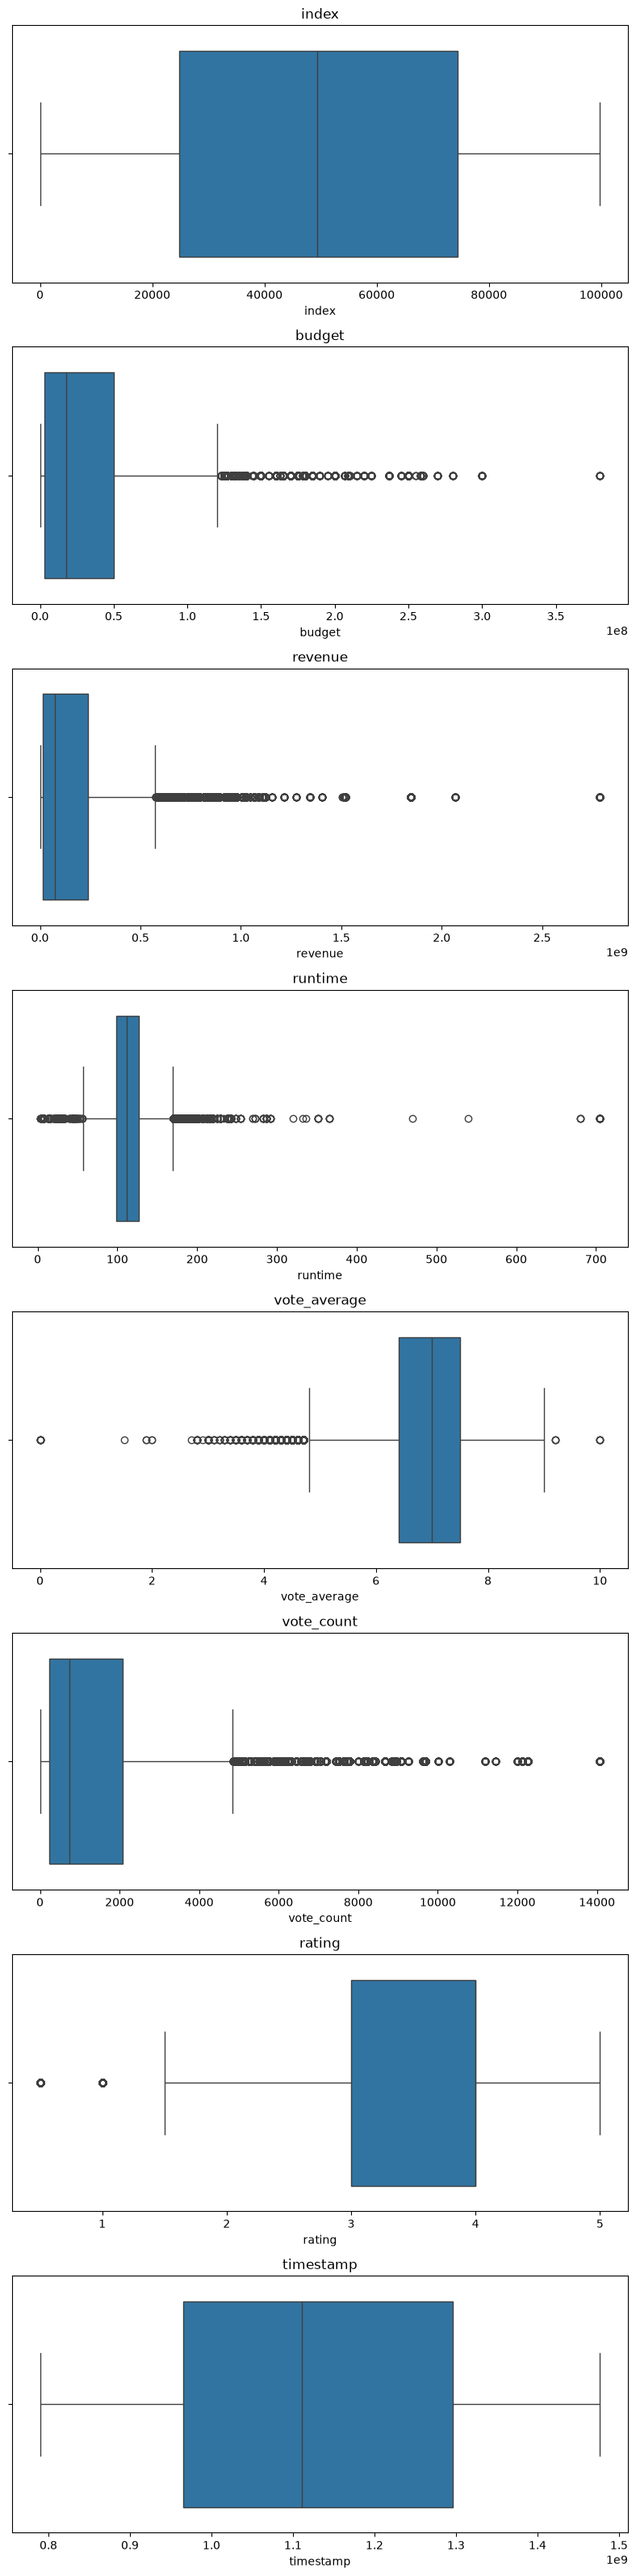

In [125]:
id_columns = ['id', 'imdbId', 'movieId', 'userId', 'tmdbId']
numeric_columns = [col for col in df.select_dtypes(include='number').columns if col not in id_columns]

for column in numeric_columns:
    q1 = df[column].quantile(0.25)
    q3 = df[column].quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    outliers = df[(df[column] < lower) | (df[column] > upper)]
    print(f"{column}: {len(outliers)} outliers ({len(outliers) / len(df) * 100:.2f}%)")

fig, axes = plt.subplots(len(numeric_columns), 1, figsize=(8, 4 * len(numeric_columns)))
for ax, column in zip(axes, numeric_columns):
    sns.boxplot(x=df[column], ax=ax)
    ax.set_title(column)
plt.tight_layout()
plt.show()


IQR-based outliers, on the rating-level `df`: `vote_count` 8.0%, `revenue` 6.3%, `budget`
5.3%, `rating` 4.4%, `runtime` 4.1%, `vote_average` 1.3%. For a recommender these aren't
noise: they're mostly popular titles, exactly what's most likely to be recommended.
`rating` and `timestamp` aren't good IQR candidates (a bounded scale and a plain
identifier, respectively) and are kept only for completeness. `id`-type columns
(`id`, `imdbId`, `movieId`, `userId`, `tmdbId`) were excluded from this check entirely,
since an IQR outlier among identifiers has no meaningful interpretation; `index`, added by
the `reset_index()` earlier, is not in that exclusion list and shows up here too (0.00%
outliers, harmless, but worth adding to the exclusion list for tidiness).

# Questions

1. What is the distribution of genres in the dataset?
2. How is budget distributed, and how spread out are the outliers?
3. How many movies were produced per decade, and what proportion does each represent?
4. Is there a relationship between budget and revenue?
5. Is there a relationship between vote_average and vote_count?
6. What is the most frequent original language?
7. How is runtime distributed?
8. Does vote_average differ between high- and low-budget movies?
9. Is there an association between original language and decade of release?
10. Does the distribution of vote_count differ across decades?
11. How does vote_average vary across genres? 

In [126]:
movies = df.drop_duplicates(subset='id')

## 1. What is the distribution of genres in the dataset?

Genre composition matters for the content-based side of this project: a genre with very
few movies gives a similarity model little to work with, and can be a source of cold
start on its own. Counted on `movies` (one row per movie, not per rating), since
`genres` is multi-label and a movie counts toward every genre it has.

In [127]:
movies.head(10)

,index,belongs_to_collection,budget,genres,id,imdbId,original_language,original_title,popularity,production_companies,...,title,vote_average,vote_count,cast,director,keywords,movieId,userId,rating,timestamp
0,0,Toy Story Collection,30000000,"Animation, Comedy, Family",862,114709,en,Toy Story,21.946943,Pixar Animation Studios,...,Toy Story,7.7,5415.0,"Tom Hanks, Tim Allen, Don Rickles, Jim Varney,...",John Lasseter,"jealousy, toy, boy, friendship, friends, rival...",1,7,3.0,851866703
247,247,No belongs to collection,65000000,"Adventure, Fantasy, Family",8844,113497,en,Jumanji,17.015539,"TriStar Pictures, Teitler Film, Interscope Com...",...,Jumanji,6.9,2413.0,"Robin Williams, Jonathan Hyde, Kirsten Dunst, ...",Joe Johnston,"board game, disappearance, based on children's...",2,15,2.0,1134521380
354,354,Grumpy Old Men Collection,0,"Romance, Comedy",15602,113228,en,Grumpier Old Men,11.7129,"Warner Bros., Lancaster Gate",...,Grumpier Old Men,6.5,92.0,"Walter Matthau, Jack Lemmon, Ann-Margret, Soph...",Howard Deutch,"fishing, best friend, duringcreditsstinger, ol...",3,5,4.0,1163374957
413,413,No belongs to collection,16000000,"Comedy, Drama, Romance",31357,114885,en,Waiting to Exhale,3.859495,Twentieth Century Fox Film Corporation,...,Waiting to Exhale,6.1,34.0,"Whitney Houston, Angela Bassett, Loretta Devin...",Forest Whitaker,"based on novel, interracial relationship, sing...",4,19,3.0,855192868
426,426,Father of the Bride Collection,0,Comedy,11862,113041,en,Father of the Bride Part II,8.387519,"Sandollar Productions, Touchstone Pictures",...,Father of the Bride Part II,5.7,173.0,"Steve Martin, Diane Keaton, Martin Short, Kimb...",Charles Shyer,"baby, midlife crisis, confidence, aging, daugh...",5,15,4.5,1093070098
482,482,No belongs to collection,60000000,"Action, Crime, Drama, Thriller",949,113277,en,Heat,17.924927,"Regency Enterprises, Forward Pass, Warner Bros.",...,Heat,7.7,1886.0,"Al Pacino, Robert De Niro, Val Kilmer, Jon Voi...",Michael Mann,"robbery, detective, bank, obsession, chase, sh...",6,15,4.0,1040205753
586,586,No belongs to collection,58000000,"Comedy, Romance",11860,114319,en,Sabrina,6.677277,"Paramount Pictures, Scott Rudin Productions, M...",...,Sabrina,6.2,141.0,"Harrison Ford, Julia Ormond, Greg Kinnear, Ang...",Sydney Pollack,"paris, brother brother relationship, chauffeur...",7,18,3.0,856006982
644,644,No belongs to collection,35000000,"Action, Adventure, Thriller",9091,114576,en,Sudden Death,5.23158,"Universal Pictures, Imperial Entertainment, Si...",...,Sudden Death,5.5,174.0,"Jean-Claude Van Damme, Powers Boothe, Dorian H...",Peter Hyams,"terrorist, hostage, explosive, vice president",9,18,3.0,856007219
664,664,James Bond Collection,58000000,"Adventure, Action, Thriller",710,113189,en,GoldenEye,14.686036,"United Artists, Eon Productions",...,GoldenEye,6.6,1194.0,"Pierce Brosnan, Sean Bean, Izabella Scorupco, ...",Martin Campbell,"cuba, falsely accused, secret identity, comput...",10,2,4.0,835355493
786,786,No belongs to collection,62000000,"Comedy, Drama, Romance",9087,112346,en,The American President,6.318445,"Columbia Pictures, Castle Rock Entertainment",...,The American President,6.5,199.0,"Michael Douglas, Annette Bening, Michael J. Fo...",Rob Reiner,"white house, usa president, new love, widower,...",11,15,2.5,1093028381


In [128]:
exploded = movies.copy()
exploded['genres'] = exploded['genres'].str.split(', ')
exploded = exploded.explode('genres')

In [129]:
exploded.head(10)

,index,belongs_to_collection,budget,genres,id,imdbId,original_language,original_title,popularity,production_companies,...,title,vote_average,vote_count,cast,director,keywords,movieId,userId,rating,timestamp
0,0,Toy Story Collection,30000000,Animation,862,114709,en,Toy Story,21.946943,Pixar Animation Studios,...,Toy Story,7.7,5415.0,"Tom Hanks, Tim Allen, Don Rickles, Jim Varney,...",John Lasseter,"jealousy, toy, boy, friendship, friends, rival...",1,7,3.0,851866703
0,0,Toy Story Collection,30000000,Comedy,862,114709,en,Toy Story,21.946943,Pixar Animation Studios,...,Toy Story,7.7,5415.0,"Tom Hanks, Tim Allen, Don Rickles, Jim Varney,...",John Lasseter,"jealousy, toy, boy, friendship, friends, rival...",1,7,3.0,851866703
0,0,Toy Story Collection,30000000,Family,862,114709,en,Toy Story,21.946943,Pixar Animation Studios,...,Toy Story,7.7,5415.0,"Tom Hanks, Tim Allen, Don Rickles, Jim Varney,...",John Lasseter,"jealousy, toy, boy, friendship, friends, rival...",1,7,3.0,851866703
247,247,No belongs to collection,65000000,Adventure,8844,113497,en,Jumanji,17.015539,"TriStar Pictures, Teitler Film, Interscope Com...",...,Jumanji,6.9,2413.0,"Robin Williams, Jonathan Hyde, Kirsten Dunst, ...",Joe Johnston,"board game, disappearance, based on children's...",2,15,2.0,1134521380
247,247,No belongs to collection,65000000,Fantasy,8844,113497,en,Jumanji,17.015539,"TriStar Pictures, Teitler Film, Interscope Com...",...,Jumanji,6.9,2413.0,"Robin Williams, Jonathan Hyde, Kirsten Dunst, ...",Joe Johnston,"board game, disappearance, based on children's...",2,15,2.0,1134521380
247,247,No belongs to collection,65000000,Family,8844,113497,en,Jumanji,17.015539,"TriStar Pictures, Teitler Film, Interscope Com...",...,Jumanji,6.9,2413.0,"Robin Williams, Jonathan Hyde, Kirsten Dunst, ...",Joe Johnston,"board game, disappearance, based on children's...",2,15,2.0,1134521380
354,354,Grumpy Old Men Collection,0,Romance,15602,113228,en,Grumpier Old Men,11.7129,"Warner Bros., Lancaster Gate",...,Grumpier Old Men,6.5,92.0,"Walter Matthau, Jack Lemmon, Ann-Margret, Soph...",Howard Deutch,"fishing, best friend, duringcreditsstinger, ol...",3,5,4.0,1163374957
354,354,Grumpy Old Men Collection,0,Comedy,15602,113228,en,Grumpier Old Men,11.7129,"Warner Bros., Lancaster Gate",...,Grumpier Old Men,6.5,92.0,"Walter Matthau, Jack Lemmon, Ann-Margret, Soph...",Howard Deutch,"fishing, best friend, duringcreditsstinger, ol...",3,5,4.0,1163374957
413,413,No belongs to collection,16000000,Comedy,31357,114885,en,Waiting to Exhale,3.859495,Twentieth Century Fox Film Corporation,...,Waiting to Exhale,6.1,34.0,"Whitney Houston, Angela Bassett, Loretta Devin...",Forest Whitaker,"based on novel, interracial relationship, sing...",4,19,3.0,855192868
413,413,No belongs to collection,16000000,Drama,31357,114885,en,Waiting to Exhale,3.859495,Twentieth Century Fox Film Corporation,...,Waiting to Exhale,6.1,34.0,"Whitney Houston, Angela Bassett, Loretta Devin...",Forest Whitaker,"based on novel, interracial relationship, sing...",4,19,3.0,855192868


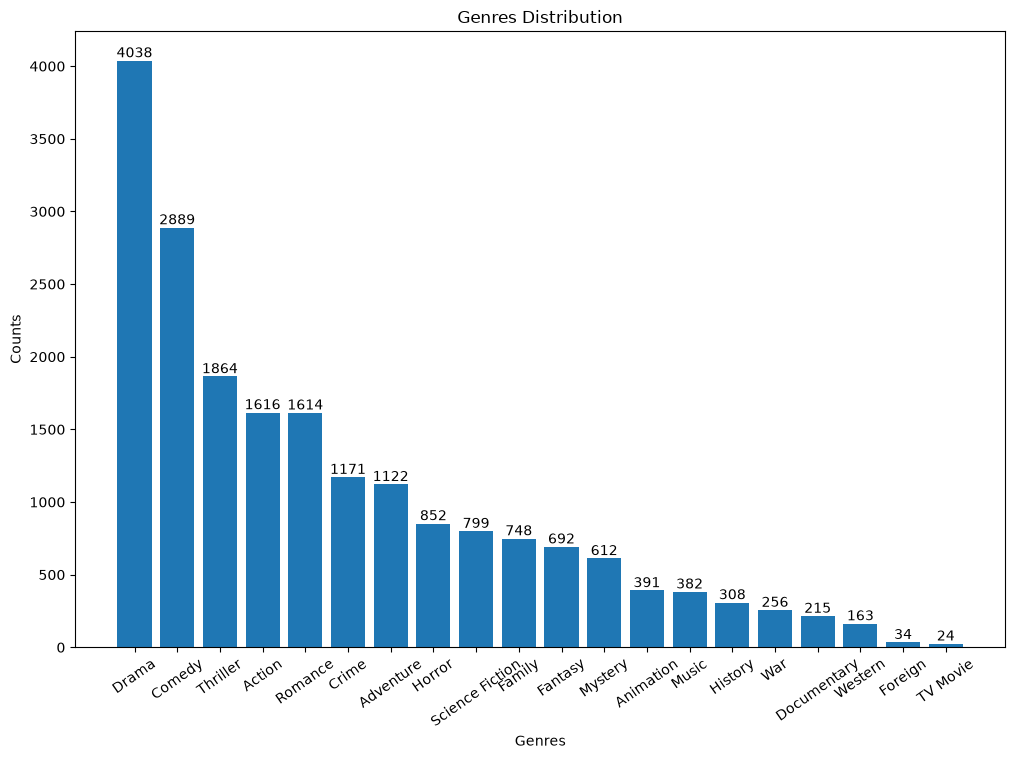

In [130]:
plt.figure(figsize=(12,8))
ax = plt.bar(exploded['genres'].value_counts().index, exploded['genres'].value_counts())
plt.title('Genres Distribution')
plt.xlabel('Genres')
plt.xticks(rotation=35)
plt.ylabel('Counts')
plt.bar_label(ax)
plt.show()

**Conclusion.** 20 distinct genres in the catalog (7,821 movies). Drama (4,040 movies) and
Comedy (2,891) dominate by a clear margin over the rest; the next tier (Thriller 1,864,
Action 1,616, Romance 1,615) sits well below. Foreign (34) and TV Movie (24) are nearly
absent, with too few movies to support meaningful genre-based similarity or grouping later
on. Counted on `movies` (one row per movie, not per rating), since `genres` is multi-label
and a movie counts toward every genre it has; counting on the rating-level table instead
changes the ranking, a reminder to always aggregate at movie level for questions about the
catalog itself.

## 2. How is budget distributed, and how spread out are the outliers?

`budget` is self-reported and TMDB encodes an unknown budget as `0`, not a missing
value, so the raw distribution below is checked first, then re-examined with the zeros
excluded before drawing any conclusion about typical production budgets.

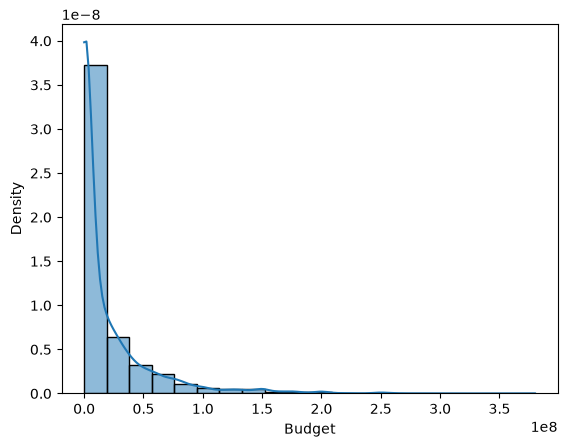

In [131]:
sns.histplot(movies['budget'], bins=20, edgecolor='black', kde=True, stat='density')
plt.ylabel('Density')
plt.xlabel('Budget')
plt.show() 

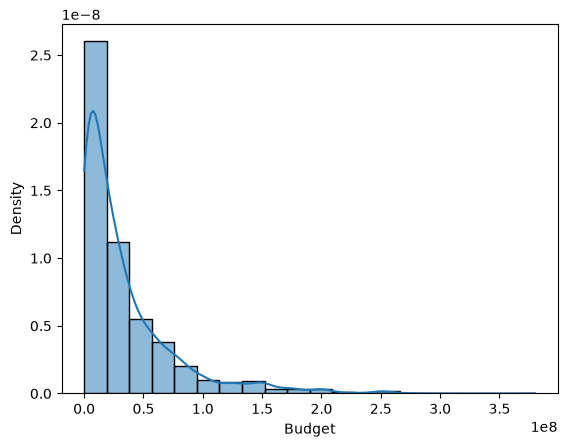

In [132]:
movies_without_0 = movies[movies['budget'] != 0]
sns.histplot(movies_without_0['budget'], bins=20, edgecolor='black', kde=True, stat='density')
plt.ylabel('Density')
plt.xlabel('Budget')
plt.show() 

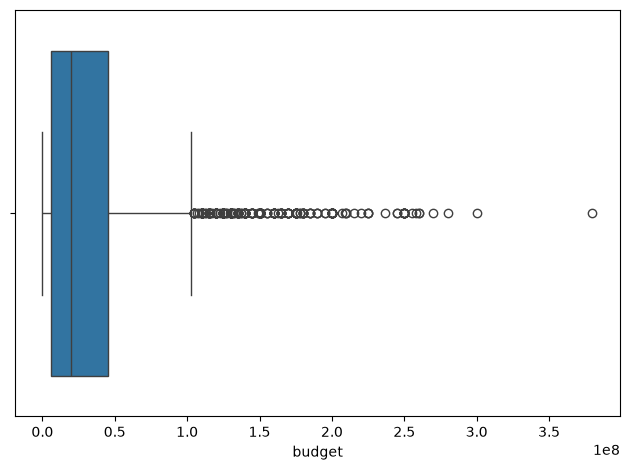

In [133]:
sns.boxplot(x=movies_without_0['budget'])
plt.tight_layout()
plt.show()

In [134]:
movies_without_0['budget'].describe()

count    4.422000e+03
mean     3.364817e+07
std      4.144856e+07
min      1.000000e+00
25%      6.000000e+06
50%      2.000000e+07
75%      4.500000e+07
max      3.800000e+08
Name: budget, dtype: float64

**Conclusion.** Budget is heavily right-skewed. Excluding the 0 values (4,422 of 7,821
movies have a reported budget), the distribution has median \$20M and mean \$33.65M
(IQR: \$6M to \$45M, max \$380M). The mean sitting well above the median, together with
the boxplot's long tail of individual points beyond the upper whisker, confirms most movies
have modest budgets, with a small number of very high-budget productions pulling the average
up. Just under half the catalog (3,399 movies, 43.5%) has no reported budget at all, so any
conclusion here describes the subset of movies TMDB has financial data for, not the full
catalog.

## 3. How many movies were produced per decade, and what proportion does each represent?

Decade composition matters for a similar reason to genre: a decade with very few movies
limits any comparison involving it (P10 groups `vote_count` by decade later on).
Computed on `movies_decade`, a copy of `movies` (one row per movie) with `decade` derived
from `release_date`.

In [135]:
movies_decade = movies.copy()

movies_decade['decade'] = movies_decade['release_date'].dt.year - (movies_decade['release_date'].dt.year % 10)

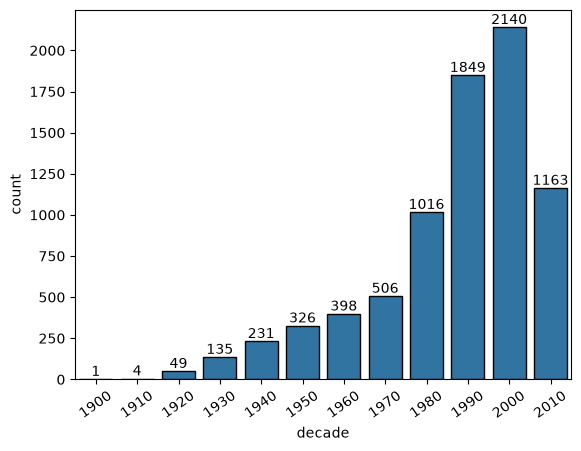

In [136]:
ax=sns.countplot(x ='decade', data = movies_decade, order=movies_decade['decade'].sort_values(), edgecolor='black')
ax.bar_label(container=ax.containers[0])
plt.xticks(rotation=35)
plt.show()


In [137]:
top8 = movies_decade['decade'].value_counts().sort_values(ascending=False)[:8]
top8

decade
2000    2140
1990    1849
2010    1163
1980    1016
1970     506
1960     398
1950     326
1940     231
Name: count, dtype: int64

In [138]:
others = pd.Series(movies_decade['decade'].value_counts().sort_values(ascending=False)[8:].sum(), index=["Others"])
others

Others    189
dtype: int64

In [139]:
piecounts = pd.concat([top8, others])
piecounts

2000      2140
1990      1849
2010      1163
1980      1016
1970       506
1960       398
1950       326
1940       231
Others     189
dtype: int64

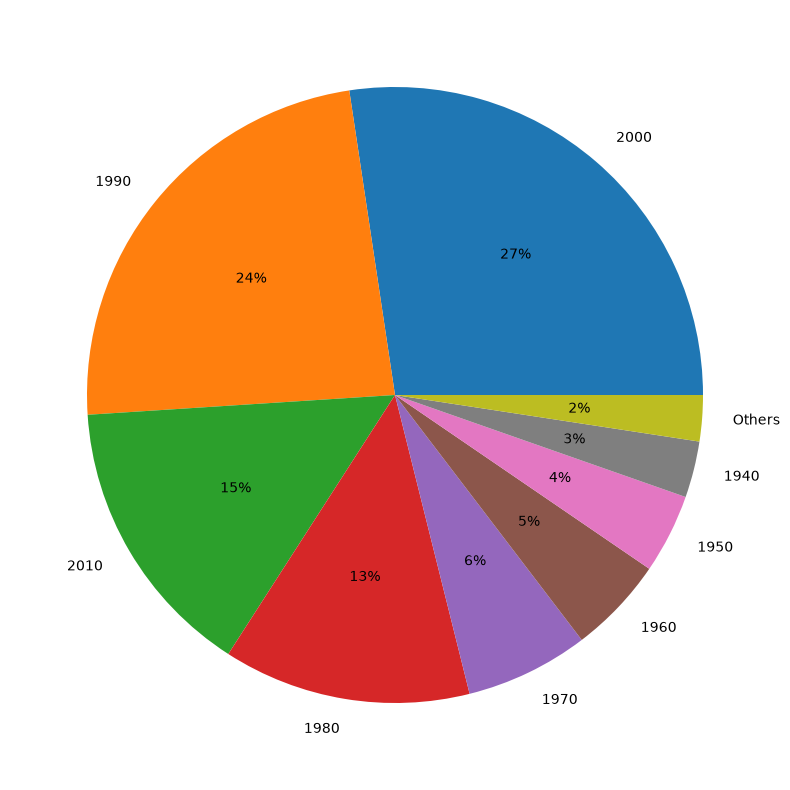

In [140]:
plt.figure(figsize=(10,10))
plt.pie(piecounts.values, labels=piecounts.index,  autopct='%.0f%%')
plt.show()


**Conclusion.** The catalog is concentrated in recent decades: 2000 (2,140 movies) and
1990 (1,852) together account for over half of it, with 2010 (1,163) and 1980 (1,016)
forming a second tier. Everything before 1940 is negligible (1900: 1 movie, 1910: 4,
1920: 49, 1930: 135), grouped into "Others" for the pie chart (189 movies, 2%). Too
sparse to support a meaningful per-decade comparison on its own; worth revisiting group
sizes before interpreting P10.

## 4. Is there a relationship between budget and revenue?

`budget`/`revenue` = 0 means "unknown", not a real zero, and a pair of zeros on both
sides looks like artificial agreement between the two variables, so the relationship is
checked twice: once as-is, once with those rows excluded. Pearson alone is also a risk
given how right-skewed both variables are (P2), so Spearman is added as a check on
whether that skew is driving the result.

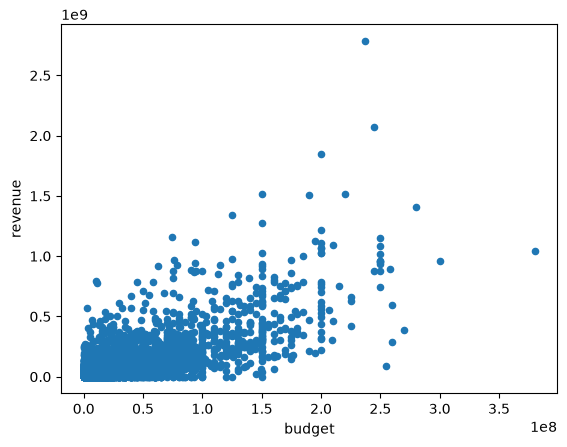

In [141]:
movies.plot.scatter(x='budget', y='revenue')
plt.show()

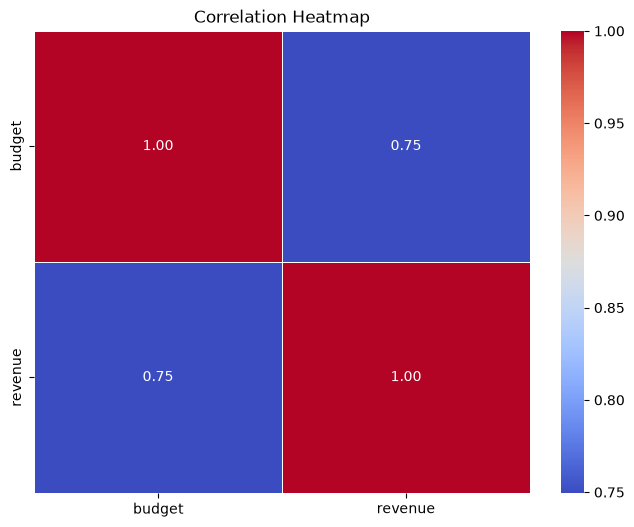

In [142]:
matrix = movies[['budget', 'revenue']].corr()
plt.figure(figsize=(8,6))
sns.heatmap(matrix, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
plt.title("Correlation Heatmap")
plt.show()

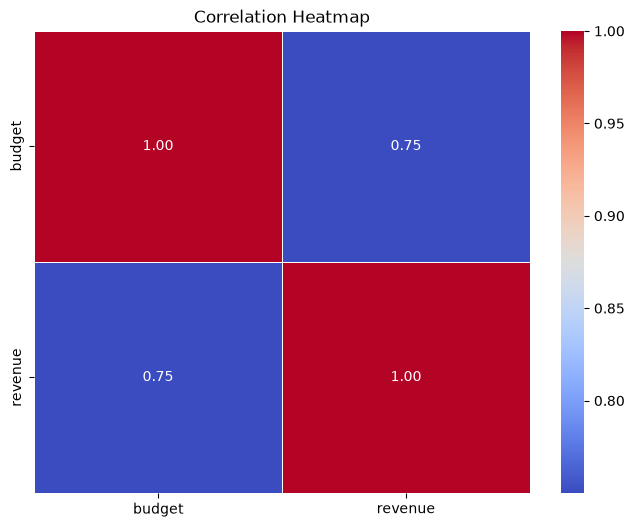

In [143]:
matrix = movies[['budget', 'revenue']].corr(method='spearman')
plt.figure(figsize=(8,6))
sns.heatmap(matrix, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
plt.title("Correlation Heatmap")
plt.show()

In [144]:
r = movies[['budget', 'revenue']].corr().loc['budget', 'revenue']
r_squared = r ** 2
print(r_squared)

0.5618666857842806


In [145]:
columns = ['budget', 'revenue']

zero_mask = (movies[columns] == 0).any(axis=1)

In [146]:
movies_without_0 = movies[~zero_mask]

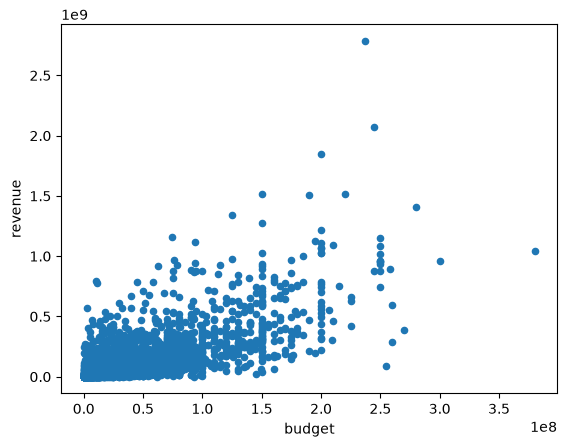

In [147]:
movies_without_0.plot.scatter(x='budget', y='revenue')
plt.show()

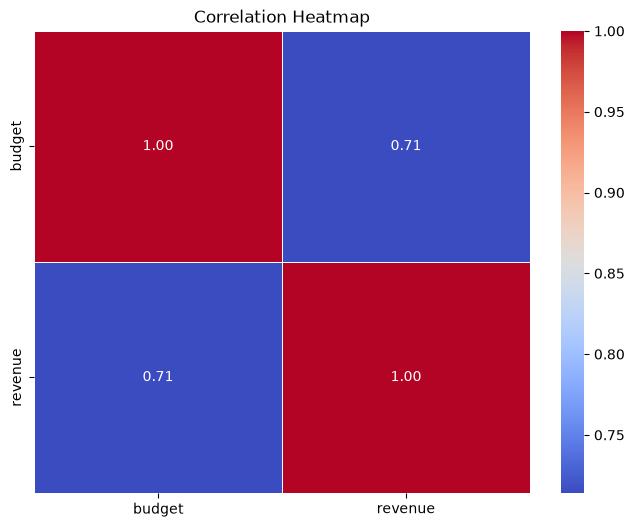

In [148]:
matrix = movies_without_0[['budget', 'revenue']].corr()
plt.figure(figsize=(8,6))
sns.heatmap(matrix, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
plt.title("Correlation Heatmap")
plt.show()

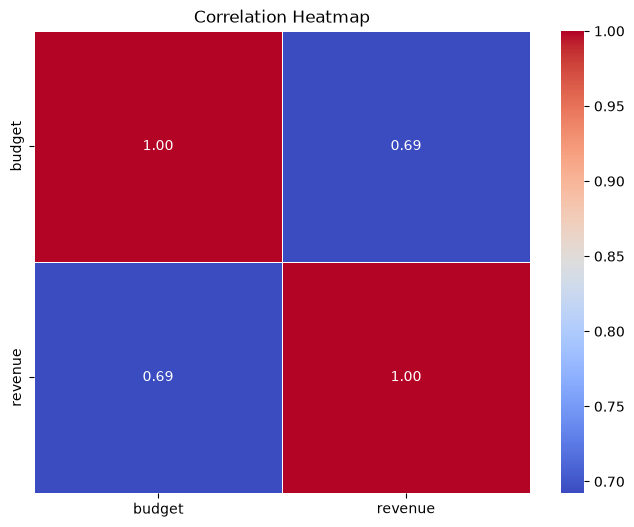

In [149]:
matrix = movies_without_0[['budget', 'revenue']].corr(method='spearman')
plt.figure(figsize=(8,6))
sns.heatmap(matrix, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
plt.title("Correlation Heatmap")
plt.show()

In [150]:
r = movies_without_0[['budget', 'revenue']].corr().loc['budget', 'revenue'] # row budget column revenue
r_squared = r ** 2
print(r_squared)


0.5099203464695592


**Conclusion.** Budget and revenue are positively correlated. Including the 0-valued
rows, Pearson r = 0.75 (r² = 0.56); excluding them, r = 0.71 (r² = 0.51), and Spearman
on the same excluded-zero data gives 0.69. The 0.75 to 0.71 drop confirms the zero pairs
were inflating the correlation somewhat, as expected. Pearson and Spearman landing close
together (0.71 vs. 0.69) shows the heavy right skew in both variables isn't distorting
the Pearson estimate much, so r = 0.71 (roughly half the variance in revenue explained by
budget, r² = 0.51) is a reasonably reliable summary of the relationship on the movies
with reported financials.

## 5. Is there a relationship between vote_average and vote_count?

A movie with very few votes can land on an extreme `vote_average` (0, 10) by pure sample
noise, not because it's genuinely the best or worst rated. Checked with and without a
minimum `vote_count` (41, the 25th percentile of the distribution) to see whether that
noise is driving the relationship.

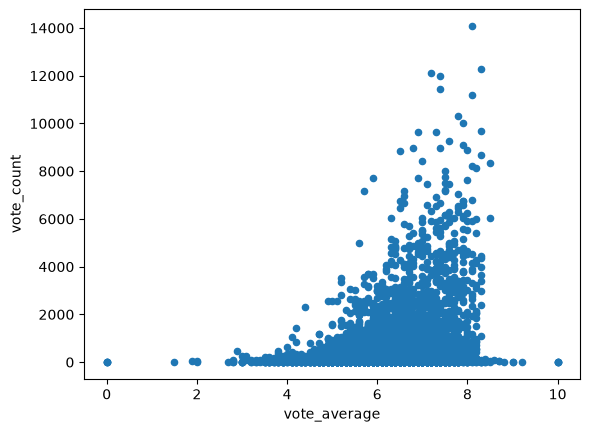

In [151]:
movies.plot.scatter(x='vote_average', y='vote_count')
plt.show()

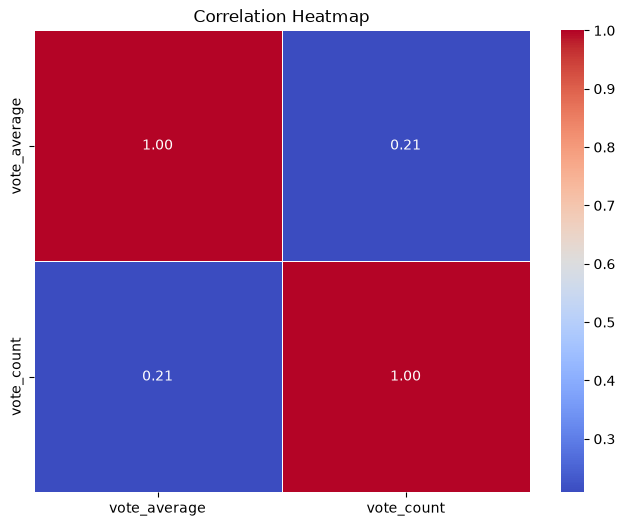

In [152]:
matrix = movies[['vote_average', 'vote_count']].corr()
plt.figure(figsize=(8,6))
sns.heatmap(matrix, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
plt.title("Correlation Heatmap")
plt.show()

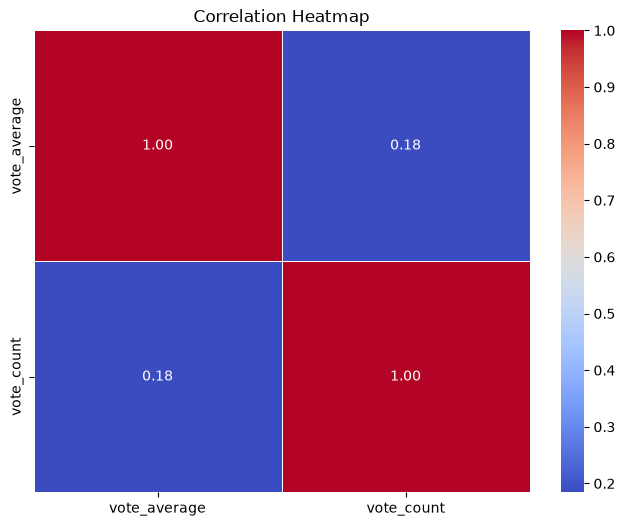

In [153]:
matrix = movies[['vote_average', 'vote_count']].corr(method='spearman')
plt.figure(figsize=(8,6))
sns.heatmap(matrix, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
plt.title("Correlation Heatmap")
plt.show()

In [154]:
r = movies[['vote_average', 'vote_count']].corr().loc['vote_average', 'vote_count']
r_squared = r ** 2
print(r_squared)

0.0433684361344094


In [155]:
movies['vote_count'].describe()

count     7818.000000
mean       502.276925
std       1058.873475
min          0.000000
25%         41.000000
50%        129.000000
75%        444.750000
max      14075.000000
Name: vote_count, dtype: float64

In [156]:
movies_with_minimum_votes = movies[movies['vote_count'] >=41]


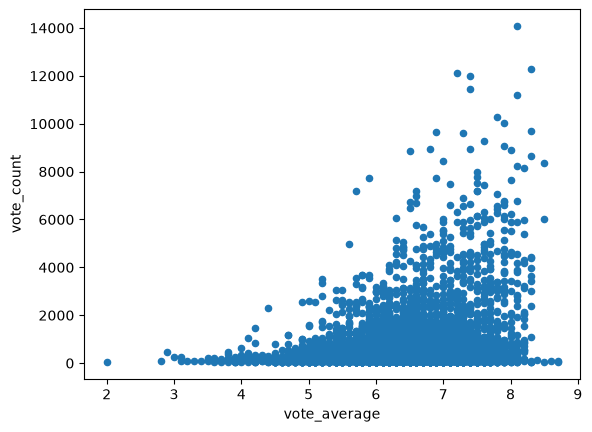

In [157]:
movies_with_minimum_votes.plot.scatter(x='vote_average', y='vote_count')
plt.show()

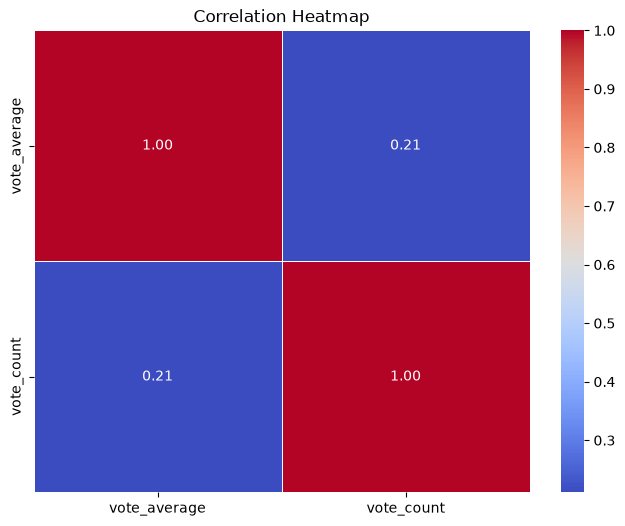

In [158]:
matrix = movies_with_minimum_votes[['vote_average', 'vote_count']].corr()
plt.figure(figsize=(8,6))
sns.heatmap(matrix, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
plt.title("Correlation Heatmap")
plt.show()

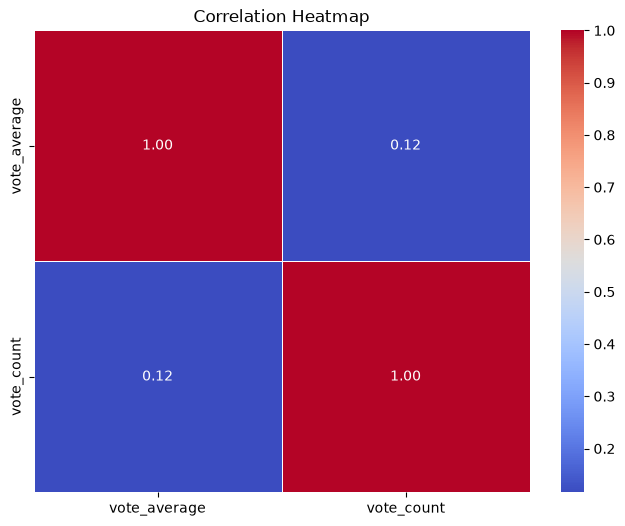

In [159]:
matrix = movies_with_minimum_votes[['vote_average', 'vote_count']].corr(method='spearman')
plt.figure(figsize=(8,6))
sns.heatmap(matrix, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
plt.title("Correlation Heatmap")
plt.show()

In [160]:
r = movies_with_minimum_votes[['vote_average', 'vote_count']].corr().loc['vote_average', 'vote_count']
r_squared = r ** 2
print(r_squared)

0.044482038603236615


**Conclusion.** Only a weak relationship between `vote_average` and `vote_count`.
Unfiltered: Pearson r = 0.21, Spearman = 0.18, r² = 0.043. With the `vote_count` ≥ 41
filter (dropping 1,942 of 7,821 movies, 24.8%): Pearson stays at r = 0.21 (r² = 0.044),
but Spearman drops to 0.12.

This is the opposite of what the filter was expected to do. Removing the noisy
low-vote-count tail didn't reveal a cleaner, stronger relationship, it weakened the rank
correlation, which means part of the monotonic relationship in the unfiltered data was
actually coming from those very-low-vote movies, not obscured by them. Either way, r²
around 0.04 to 0.05 means `vote_count` explains only about 4 to 5% of the variance in
`vote_average`: a movie's popularity (how many people voted) says very little about how
well it's rated on average.

## 6. What is the most frequent original language?

`original_language` has ~40 distinct values, most with a handful of movies; a full bar
chart is cluttered but useful to see the long tail, a pie grouping the top 8 into
"Others" gives the readable summary.

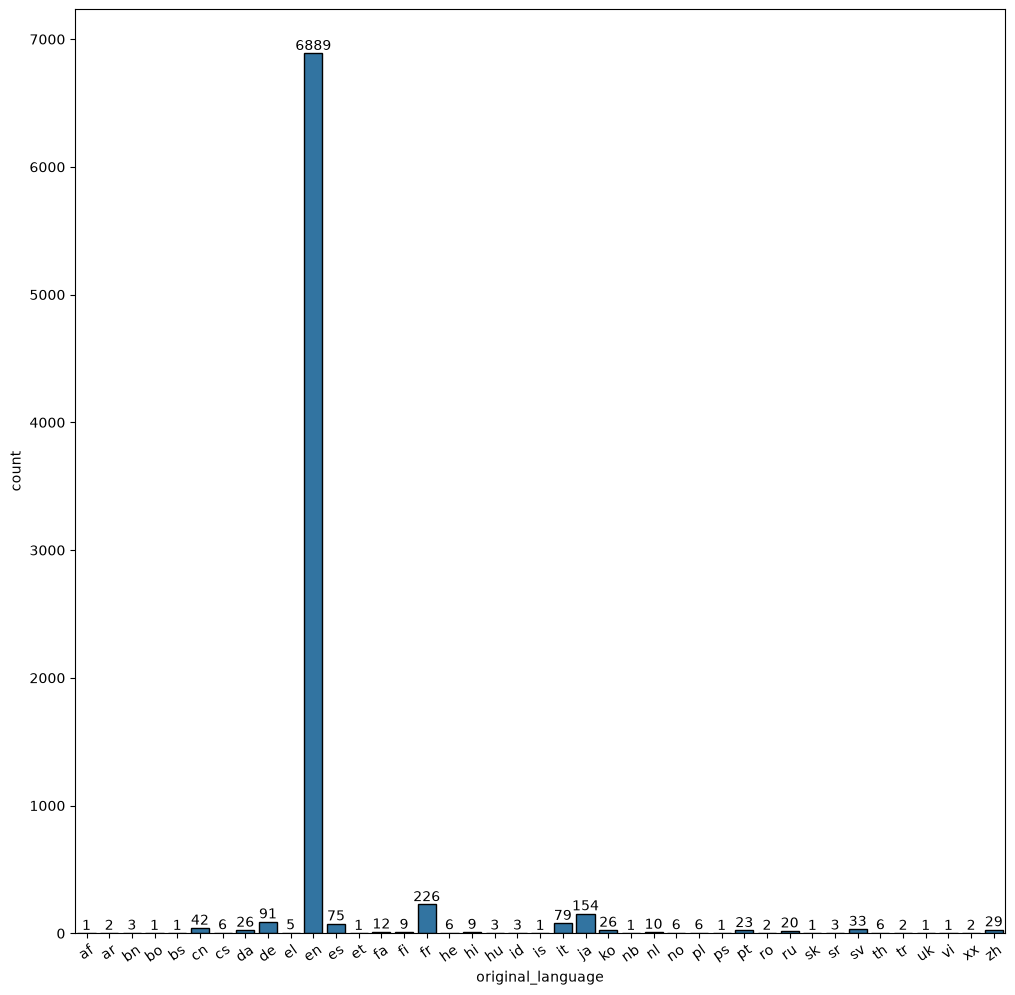

In [161]:
plt.figure(figsize=(12,12))
ax=sns.countplot(x ='original_language', data = movies, order=movies['original_language'].sort_values(), edgecolor='black')
ax.bar_label(container=ax.containers[0])
plt.xticks(rotation=35)
plt.show()


In [162]:
top8 = movies['original_language'].value_counts().sort_values(ascending=False)[:8]
top8

original_language
en    6889
fr     226
ja     154
de      91
it      79
es      75
cn      42
sv      33
Name: count, dtype: int64

In [163]:
others = pd.Series(movies['original_language'].value_counts().sort_values(ascending=False)[8:].sum(), index=["Others"])
others

Others    229
dtype: int64

In [164]:
piecounts = pd.concat([top8, others])
piecounts

en        6889
fr         226
ja         154
de          91
it          79
es          75
cn          42
sv          33
Others     229
dtype: int64

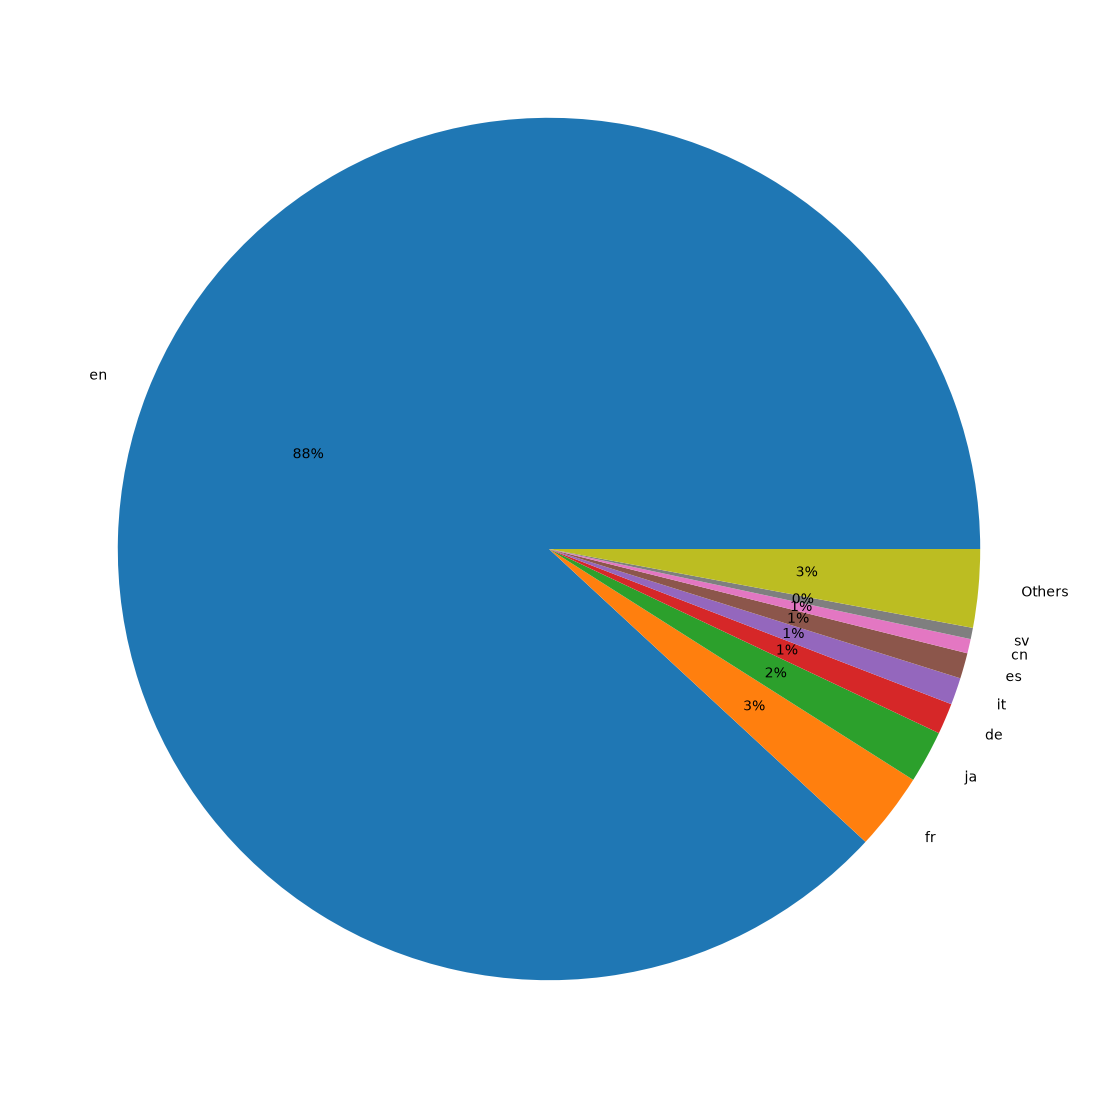

In [165]:
plt.figure(figsize=(14,14))
plt.pie(piecounts.values, labels=piecounts.index,  autopct='%.0f%%')
plt.show()


**Conclusion.** English is overwhelmingly the mode: 6,890 of 7,821 movies (88.1%).
French (227, 2.9%) and Japanese (154, 2.0%) are a distant second and third; everything
else is marginal (German 91, Italian 80, Spanish 75, Mandarin 42, Swedish 33, all under
1.2% each).

This is not simply "English is the world's most-spoken language", it isn't, Mandarin
has more native speakers. Two other factors explain the gap better: Hollywood's outsized
global production and distribution volume compared to any other national industry, and a
sampling bias in this specific dataset, TMDB and MovieLens are both built on catalogs and
user bases skewed toward Western, English-language audiences. China's strict import
quotas and content controls compound this: they limit how many foreign films reach
Chinese audiences, and just as much limit how much Chinese-language cinema ends up
represented in a Western-centric catalog like this one. The 88% figure says as much
about what this dataset covers as it does about global film production.

## 7. How is runtime distributed?

Split out from the original P6, which paired it with language. 3 movies had
`runtime` = 0, the same missing-data sentinel seen in `budget`/`revenue`, not a real
duration; dropped before computing these stats.

In [166]:
movies['runtime'].describe()


count    7818.000000
mean      106.707854
std        25.495114
min         3.000000
25%        93.000000
50%       103.000000
75%       117.000000
max       705.000000
Name: runtime, dtype: float64

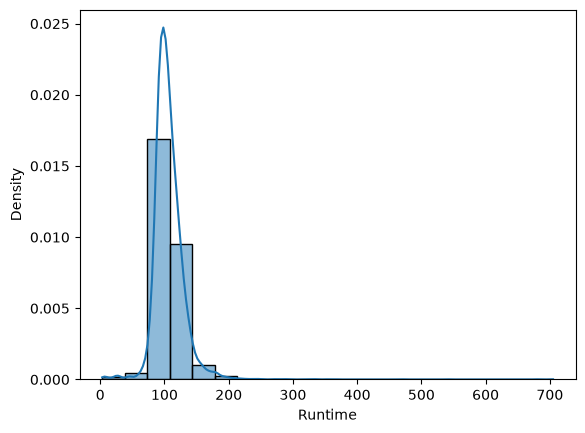

In [167]:
sns.histplot(movies['runtime'], bins=20, edgecolor='black', kde=True, stat='density')
plt.ylabel('Density')
plt.xlabel('Runtime')
plt.show() 

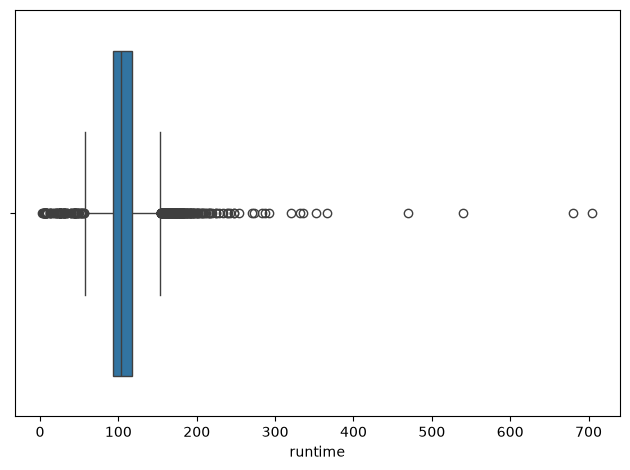

In [168]:
sns.boxplot(x=movies['runtime'])
plt.tight_layout()
plt.show()

**Conclusion.** Runtime is tightly clustered: median 103 minutes, mean 106.7, IQR 93 to
117 (std 25.5), consistent with the standard feature-length film. The boxplot shows a
long, thin tail of much longer titles, up to 705 minutes, almost certainly documentaries
or multi-part epics rather than data errors. Unlike `budget`, this distribution doesn't need a zero-exclusion caveat: after
dropping the 3 sentinel rows, every remaining movie has a plausible real runtime
(minimum 3 minutes).

## 8. Does vote_average differ between high- and low-budget movies?

Two filters first: `budget` = 0 excluded (unknown, not real), and a minimum `vote_count`
of 41 (P5) to keep the extreme-average-from-few-votes noise out of the comparison.
Groups split at the median `budget` of the remaining movies.

In [169]:
movies_with_minimum_votes = movies[movies['vote_count'] >= movies['vote_count'].quantile(0.25)]
movies_without_budget_0 = movies_with_minimum_votes[movies['budget'] > 0].copy()
movies_without_budget_0.describe()

/tmp/ipykernel_47418/1906221998.py:2: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  movies_without_budget_0 = movies_with_minimum_votes[movies['budget'] > 0].copy()


,index,budget,id,imdbId,release_date,revenue,runtime,vote_average,vote_count,movieId,userId,rating,timestamp
count,4045.000000,4.045000e+03,4045.000000,4.045000e+03,4045,4.045000e+03,4045.000000,4045.000000,4045.000000,4045.000000,4045.000000,4045.000000,4.045000e+03
mean,70546.541656,3.597803e+07,32307.408405,5.582538e+05,1997-09-23 03:34:39.901112,1.050483e+08,110.291718,6.429518,890.972559,34380.422002,128.536218,3.065389,1.199052e+09
min,0.000000,1.000000e+00,5.000000,4.170000e+02,1902-09-01 00:00:00,0.000000e+00,6.000000,2.000000,41.000000,1.000000,1.000000,0.500000,8.282140e+08
25%,52895.000000,7.200000e+06,3604.000000,1.021380e+05,1991-07-19 00:00:00,8.556940e+06,95.000000,5.900000,155.000000,2648.000000,15.000000,2.000000,1.033344e+09
50%,78552.000000,2.115000e+07,10523.000000,2.455620e+05,2001-11-23 00:00:00,4.026698e+07,106.000000,6.500000,384.000000,6482.000000,34.000000,3.000000,1.179699e+09
75%,92590.000000,5.000000e+07,22803.000000,8.084170e+05,2008-11-24 00:00:00,1.221267e+08,121.000000,7.000000,994.000000,65601.000000,199.000000,4.000000,1.368865e+09
max,99765.000000,3.800000e+08,369557.000000,4.824302e+06,2016-08-17 00:00:00,2.787965e+09,705.000000,8.700000,14075.000000,160567.000000,665.000000,5.000000,1.476469e+09
std,26140.712367,4.245300e+07,61782.537404,7.223285e+05,NaN,1.790888e+08,24.769121,0.841025,1355.610810,41819.921642,173.848354,1.188934,1.907692e+08


In [170]:

movies_high_low_bugdget = movies_without_budget_0.copy()
median = movies_high_low_bugdget['budget'].median()
movies_high_low_bugdget['group'] = np.where(movies_high_low_bugdget['budget'] > median, 'High', 'Low')

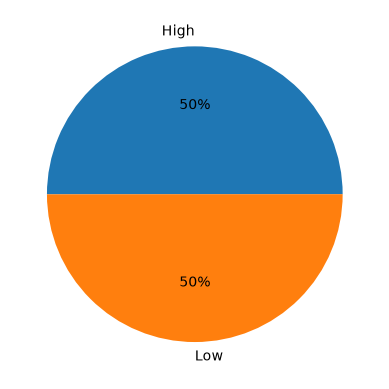

In [171]:
plt.pie(movies_high_low_bugdget['group'].value_counts(), labels=movies_high_low_bugdget['group'].unique(),  autopct='%.0f%%')
plt.show()

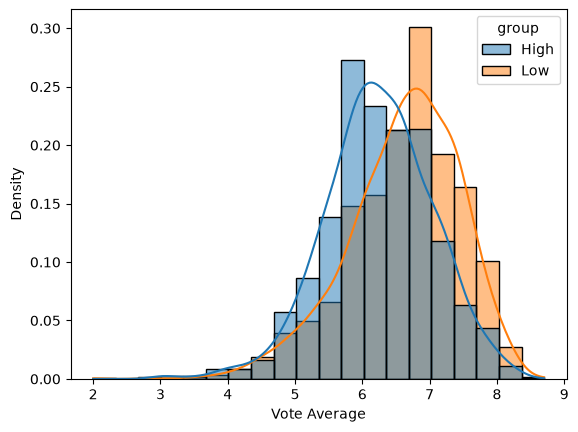

In [172]:
sns.histplot(x=movies_high_low_bugdget['vote_average'], bins=20, edgecolor='black', kde=True, stat='density', hue=movies_high_low_bugdget['group'] )
plt.ylabel('Density')
plt.xlabel('Vote Average')
plt.show() 

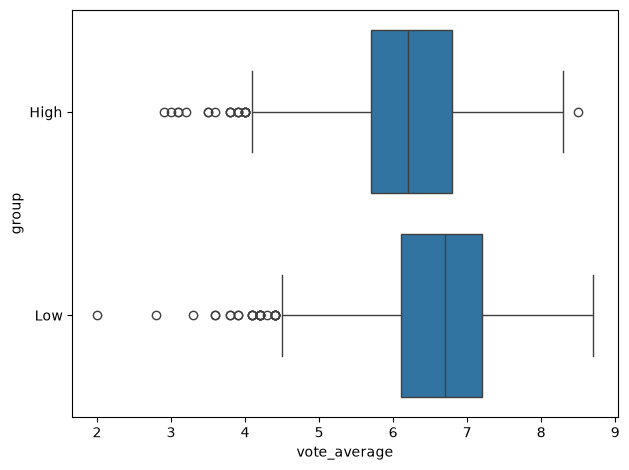

In [173]:
sns.boxplot(x=movies_high_low_bugdget['vote_average'], y=movies_high_low_bugdget['group'])
plt.tight_layout()
plt.show()

In [174]:


high_stat, high_p = shapiro(movies_high_low_bugdget[movies_high_low_bugdget['group'] == 'High']['vote_average'])
low_stat, low_p = shapiro(movies_high_low_bugdget[movies_high_low_bugdget['group'] == 'Low']['vote_average'])

print("High:", high_stat, high_p)
print("Low:", low_stat, low_p)


High: 0.9925482949751844 1.2702964932193001e-08
Low: 0.9733586501972284 6.044301715080743e-19


In [175]:
high = movies_high_low_bugdget[movies_high_low_bugdget['group'] == 'High']['vote_average']
low = movies_high_low_bugdget[movies_high_low_bugdget['group'] == 'Low']['vote_average']
U1, p = mannwhitneyu(high, low)
print(U1)
print(p)


1468127.5
1.5736165775376077e-54


In [176]:
n1 = len(high)
n2 = len(low)
r_rb = 1 - (2 * U1) / (n1 * n2)
print(r_rb)


0.28217804838814564


**Conclusion.** `vote_average` does differ between budget groups (4,045 movies with
reported budget and at least 41 votes, split at the median into High/Low). Shapiro
rejects normality in both groups (High p = 1.3e-08, Low p = 6.0e-19), so Mann-Whitney U
was used instead of a t-test: U = 1,468,127.5, p = 1.6e-54.

Effect size (rank-biserial correlation): r = 0.282, small-to-moderate. Concretely, out of
every possible one-on-one comparison between a High-budget and a Low-budget movie, the
Low-budget one has the higher `vote_average` 64.1% of the time, up from the 50% expected
if budget had no relationship to rating at all. Low-budget movies tend to be rated
somewhat higher than high-budget ones, a real but moderate effect, not a dramatic one.

## 9. Is there an association between original language and decade of release?

Both variables have long tails (~40 languages, 12 decades), so a chi-square on the raw
categories would violate Cochran's rule (expected frequency >= 5 in at least 80% of
cells). Both grouped to their top 5 categories plus "Other" before building the
contingency table, using separate `language_group`/`decade_group` columns so the
original `original_language` and `decade` stay intact for other questions.

In [177]:
top_languages = movies_decade['original_language'].value_counts().sort_values(ascending=False)[:5].index
movies_decade['language_group'] = movies_decade['original_language'].where(movies_decade['original_language'].isin(top_languages), 'Other')


In [178]:
top_decades  = movies_decade['decade'].value_counts().sort_values(ascending=False)[:5].index
movies_decade['decade_group'] = movies_decade['decade'].where(movies_decade['decade'].isin(top_decades), 'Other')


In [179]:
obs = pd.crosstab(movies_decade['decade_group'], movies_decade['language_group'])

res = chi2_contingency(obs)

print(res.statistic)
print(res.pvalue)

215.1976969181642
3.53621678896647e-32


In [180]:
print(res.expected_freq)

[[  24.52980302    5.88974162  445.87285751   14.6272704     5.1130724
     9.96725505]
 [  49.25351752   11.82604247  895.27040164   29.3701714    10.26656434
    20.01330263]
 [  89.63558455   21.52200051 1629.28639038   53.45024303   18.68393451
    36.42184702]
 [ 103.74264518   24.90918393 1885.70734203   61.86236889   21.62445638
    42.15400358]
 [  56.37976465   13.53709389 1024.80263494   33.6195958    11.7519826
    22.90892811]
 [  55.45868509   13.31593758 1008.0603735    33.07035047   11.55998977
    22.5346636 ]]


In [181]:
print((res.expected_freq < 5).sum())


0


In [182]:
cramer_v = contingency.association(obs, method='cramer')
print("Cramer's V:", cramer_v)

Cramer's V: 0.07419693653103225


**Conclusion.** Chi-square rejects independence between original language and decade of
release (χ² = 215.20, p = 3.5e-32), with a valid table (0 of 36 cells below the
expected-frequency-5 threshold). But Cramér's V = 0.074, a negligible effect. With a
sample this large, almost any departure from independence reaches significance;
the effect size shows that departure barely matters in practice; knowing a movie's
decade tells you almost nothing about its language beyond what you'd expect from the
overall language distribution (English still dominant either way, per P6).

## 10. Does the distribution of vote_count differ across decades?

Unlike every other question that touches `vote_count`, no minimum-vote-count filter is
applied here: `vote_count` is the variable under study, not a noise-control filter, so
excluding low values would censor the very distribution being compared. Decades grouped
the same way as P9 (top 5 + "Other").

In [183]:
top_decades  = movies_decade['decade'].value_counts().sort_values(ascending=False)[:5].index
movies_decade['decade_group'] = movies_decade['decade'].where(movies_decade['decade'].isin(top_decades), 'Other')

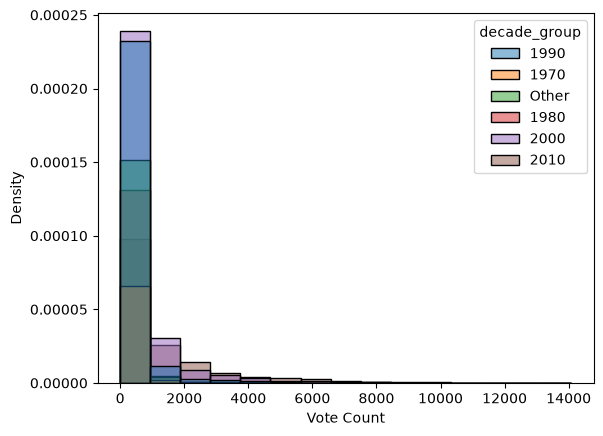

In [184]:
sns.histplot(x=movies_decade['vote_count'], bins=15, edgecolor='black', stat='density', hue=movies_decade['decade_group'] )
plt.ylabel('Density')
plt.xlabel('Vote Count')
plt.show() 

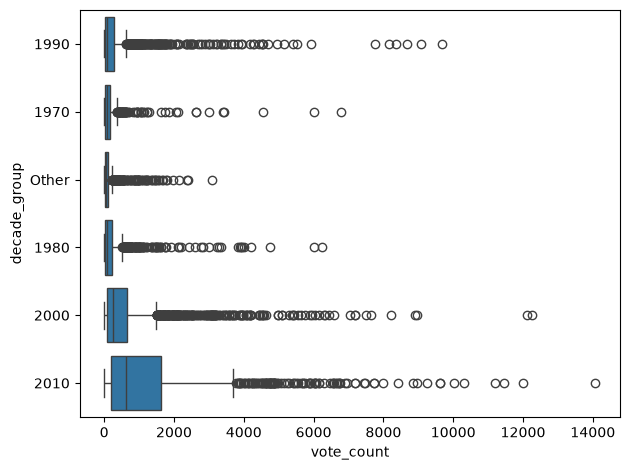

In [185]:
sns.boxplot(x=movies_decade['vote_count'], y=movies_decade['decade_group'])
plt.tight_layout()
plt.show()

In [186]:


other = movies_decade[movies_decade['decade_group'] == 'Other']['vote_count']
seventy = movies_decade[movies_decade['decade_group'] == 1970]['vote_count']
eighty = movies_decade[movies_decade['decade_group'] == 1980]['vote_count']
ninety = movies_decade[movies_decade['decade_group'] == 1990]['vote_count']
zero = movies_decade[movies_decade['decade_group'] == 2000]['vote_count']
ten = movies_decade[movies_decade['decade_group'] == 2010]['vote_count']

other_stat, other_p = shapiro(other)
seventy_stat, seventy_p = shapiro(seventy)
eighty_stat, eighty_p = shapiro(eighty)
ninety_stat, ninety_p = shapiro(ninety)
zero_stat, zero_p = shapiro(zero)
ten_stat, ten_p = shapiro(ten)



print("Others:", other_stat, other_p)
print("1970s:", seventy_stat, seventy_p)
print("1980s:", eighty_stat, eighty_p)
print("1990s:", ninety_stat, ninety_p)
print("2000s:", zero_stat, zero_p)
print("2010s:", ten_stat, ten_p)

Others: 0.4271919004286067 5.779733086242088e-51
1970s: 0.3322427936391781 3.248570954165487e-39
1980s: 0.4118009878946927 3.4136133992383767e-49
1990s: 0.39379911405597484 1.7492748564551413e-61
2000s: 0.5516525102109073 4.7276529281953896e-59
2010s: 0.6943031483841574 1.48789750128743e-41


In [187]:
kl=kruskal(other, seventy, eighty, ninety, zero, ten)
print(kl.statistic)
print(kl.pvalue)

1705.7780702791313
0.0


In [188]:
H = kl.statistic
k = 6  
n = len(movies_decade)  

eta_squared = (H - k + 1) / (n - k)
print(eta_squared)


0.21771352666143515


In [189]:
dunn = sp.posthoc_dunn([other, seventy, eighty, ninety, zero, ten], p_adjust='bonferroni')
dunn

,1,2,3,4,5,6
1,1.000000e+00,3.531993e-06,1.814786e-18,5.193374e-27,2.722394e-160,7.907540e-262
2,3.531993e-06,1.000000e+00,5.193268e-01,8.844080e-02,2.450072e-46,3.297220e-105
3,1.814786e-18,5.193268e-01,1.000000e+00,1.000000e+00,7.578102e-55,2.724936e-131
4,5.193374e-27,8.844080e-02,1.000000e+00,1.000000e+00,8.968776e-73,4.259769e-165
5,2.722394e-160,2.450072e-46,7.578102e-55,8.968776e-73,1.000000e+00,5.137503e-34
6,7.907540e-262,3.297220e-105,2.724936e-131,4.259769e-165,5.137503e-34,1.000000e+00


**Conclusion.** vote_count differs meaningfully across decades. Shapiro rejects
normality in all six decade groups, so Kruskal-Wallis was used: H = 1705.78, p ≈ 0
(effectively zero at floating-point precision). Effect size (eta-squared) = 0.218, a
large effect by conventional thresholds (0.14+), the strongest of any test in this EDA.

Dunn's post-hoc test (Bonferroni-corrected) shows the difference isn't a smooth
progression, it's a staircase. "Other" (pre-1940) is significantly lower than every
other decade. 1970s, 1980s and 1990s don't differ from each other at all (p = 0.52,
0.088 and 1.0 respectively), forming a single indistinguishable block. 2000s and 2010s
each differ significantly from every other group, including each other. So the real
pattern is: Other < {1970s ≈ 1980s ≈ 1990s} < 2000s < 2010s, with real jumps between
blocks but no detectable difference within the middle block.

This makes sense directionally: newer decades dominate the catalog (P3) and their
movies have had more visibility on streaming platforms and more time to accumulate
MovieLens ratings relative to their release, both push vote_count up, but the effect
only shows up as a step change from the 2000s onward, not gradually decade by decade.

## 11. How does vote_average vary across genres? 

In [190]:
movies_with_minimum_votes = movies[movies['vote_count'] >= movies['vote_count'].quantile(0.25)]


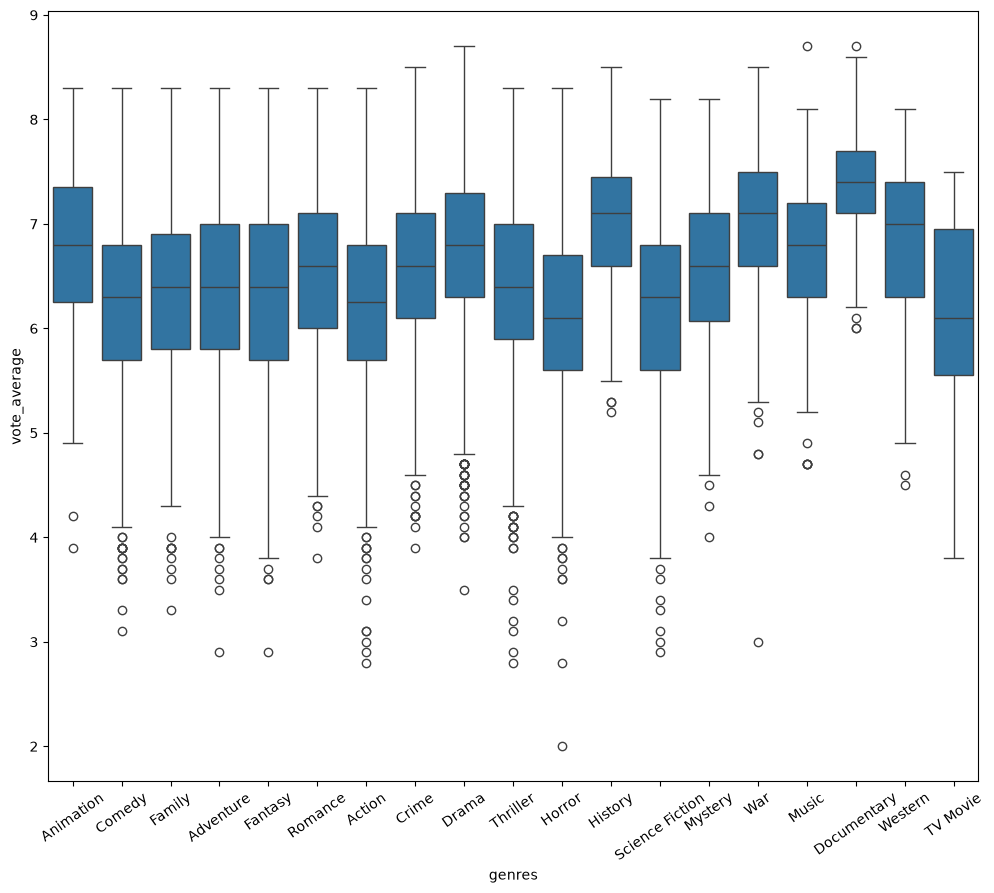

In [191]:
exploded = movies_with_minimum_votes.copy()
exploded['genres'] = exploded['genres'].str.split(', ')
exploded = exploded.explode('genres')

plt.figure(figsize=(12,10))
sns.boxplot(x='genres', y='vote_average', data=exploded)
plt.xticks(rotation=35)
plt.show()


**Conclusion.** The boxplot
shows most genres clustered around a similar median `vote_average` (roughly 6 to 7),
without dramatic separation between them. `History` stands out with a visibly higher,
tighter box; `Horror` stands out with a visibly lower one. The rest overlap enough that
any apparent ranking between them shouldn't be read as a real difference without a
proper test, which is exactly why this question was kept descriptive rather than
redesigned into one.

# Summary

| Question | Answer |
|---|---|
| 1. Genre distribution? | 20 genres; Drama (4,040) and Comedy (2,891) dominate, Foreign/TV Movie nearly absent. |
| 2. Budget distribution? | Heavily right-skewed, median $20M, mean $33.65M; 43.5% of the catalog has no reported budget. |
| 3. Movies by decade? | Concentrated in 2000 (2,140) and 1990 (1,852); pre-1940 negligible. |
| 4. Budget vs. revenue? | Positively correlated, Pearson r = 0.71 (r² = 0.51) excluding zeros, confirmed by Spearman = 0.69. |
| 5. vote_average vs. vote_count? | Weak relationship (r² ≈ 0.04-0.05); filtering low-vote noise weakened rather than strengthened it. |
| 6. Most frequent language? | English, 88.1%, driven by market dominance and dataset sampling bias, not by speaker count. |
| 7. Runtime distribution? | Median 103 min, tight IQR (93-117), long tail to 705 min (documentaries). |
| 8. vote_average by budget tier? | Low-budget movies rate higher in 64.1% of pairwise comparisons (Mann-Whitney, r = 0.282, small-moderate effect). |
| 9. Language × decade association? | Statistically significant (p = 3.5e-32) but practically negligible (Cramér's V = 0.074). |
| 10. vote_count by decade? | Large effect (Kruskal-Wallis, eta² = 0.218), the strongest finding in this EDA: newer decades have far more votes. |
| 11. vote_average by genre? | Descriptive only; most genres similar, History trends higher, Horror trends lower, no significance claimed. |

# Models

## Content Based Filtering

Content based filtering recommends a movie by what it is made of, not by who watched it: genre, director, cast, keywords, production company and franchise. It needs no ratings at all, which is what makes it the natural answer to the cold start cases explored later.

`movies` deduplicates `df` down to one row per movie (`df` is at rating level, so every movie repeats once per rating it received). `movies_clean` then drops everything that says nothing about content: budget, revenue, runtime, popularity and the leftover rating level columns. `movieId` is kept deliberately, since it is the stable identifier shared with the collaborative section further down and used throughout as the real lookup key: `cosine_sim_df`, `title_to_movieid` and `movieid_to_title` are all indexed by `movieId`, never by row position. `reset_index(drop=True)` still runs after dropping columns, but only for tidiness, nothing downstream depends on `movies_clean`'s own row position anymore.

In [192]:
movies = df.drop_duplicates(subset='id').copy()

In [193]:
movies_clean = movies.drop(columns=['budget', 'revenue', 'original_language', 'original_title', 'release_date', 'runtime', 'popularity', 'status', 'id', 'imdbId', 'rating', 'userId', 'timestamp', 'index'])
movies_clean = movies_clean.reset_index(drop=True)

In [194]:
movies_clean.info()

<class 'pandas.DataFrame'>
RangeIndex: 7818 entries, 0 to 7817
Data columns (total 10 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   belongs_to_collection  7818 non-null   str    
 1   genres                 7818 non-null   object 
 2   production_companies   7818 non-null   object 
 3   title                  7818 non-null   str    
 4   vote_average           7818 non-null   float64
 5   vote_count             7818 non-null   float64
 6   cast                   7818 non-null   object 
 7   director               7818 non-null   str    
 8   keywords               7818 non-null   object 
 9   movieId                7818 non-null   int64  
dtypes: float64(2), int64(1), object(4), str(3)
memory usage: 610.9+ KB


In [195]:
movies_clean.head()

,belongs_to_collection,genres,production_companies,title,vote_average,vote_count,cast,director,keywords,movieId
0,Toy Story Collection,"Animation, Comedy, Family",Pixar Animation Studios,Toy Story,7.7,5415.0,"Tom Hanks, Tim Allen, Don Rickles, Jim Varney,...",John Lasseter,"jealousy, toy, boy, friendship, friends, rival...",1
1,No belongs to collection,"Adventure, Fantasy, Family","TriStar Pictures, Teitler Film, Interscope Com...",Jumanji,6.9,2413.0,"Robin Williams, Jonathan Hyde, Kirsten Dunst, ...",Joe Johnston,"board game, disappearance, based on children's...",2
2,Grumpy Old Men Collection,"Romance, Comedy","Warner Bros., Lancaster Gate",Grumpier Old Men,6.5,92.0,"Walter Matthau, Jack Lemmon, Ann-Margret, Soph...",Howard Deutch,"fishing, best friend, duringcreditsstinger, ol...",3
3,No belongs to collection,"Comedy, Drama, Romance",Twentieth Century Fox Film Corporation,Waiting to Exhale,6.1,34.0,"Whitney Houston, Angela Bassett, Loretta Devin...",Forest Whitaker,"based on novel, interracial relationship, sing...",4
4,Father of the Bride Collection,Comedy,"Sandollar Productions, Touchstone Pictures",Father of the Bride Part II,5.7,173.0,"Steve Martin, Diane Keaton, Martin Short, Kimb...",Charles Shyer,"baby, midlife crisis, confidence, aging, daugh...",5


### Feature Engineering

Content based similarity needs one text representation per movie. This section builds a `text` column by combining genres, director, cast, keywords, production companies and collection into a single normalized string, and then repairs the movie titles so that each one identifies exactly one row.

In [196]:
movies_clean['belongs_to_collection'] = movies_clean['belongs_to_collection'].where(movies_clean['belongs_to_collection']!='No belongs to collection', movies_clean['title'])
movies_clean.head()

,belongs_to_collection,genres,production_companies,title,vote_average,vote_count,cast,director,keywords,movieId
0,Toy Story Collection,"Animation, Comedy, Family",Pixar Animation Studios,Toy Story,7.7,5415.0,"Tom Hanks, Tim Allen, Don Rickles, Jim Varney,...",John Lasseter,"jealousy, toy, boy, friendship, friends, rival...",1
1,Jumanji,"Adventure, Fantasy, Family","TriStar Pictures, Teitler Film, Interscope Com...",Jumanji,6.9,2413.0,"Robin Williams, Jonathan Hyde, Kirsten Dunst, ...",Joe Johnston,"board game, disappearance, based on children's...",2
2,Grumpy Old Men Collection,"Romance, Comedy","Warner Bros., Lancaster Gate",Grumpier Old Men,6.5,92.0,"Walter Matthau, Jack Lemmon, Ann-Margret, Soph...",Howard Deutch,"fishing, best friend, duringcreditsstinger, ol...",3
3,Waiting to Exhale,"Comedy, Drama, Romance",Twentieth Century Fox Film Corporation,Waiting to Exhale,6.1,34.0,"Whitney Houston, Angela Bassett, Loretta Devin...",Forest Whitaker,"based on novel, interracial relationship, sing...",4
4,Father of the Bride Collection,Comedy,"Sandollar Productions, Touchstone Pictures",Father of the Bride Part II,5.7,173.0,"Steve Martin, Diane Keaton, Martin Short, Kimb...",Charles Shyer,"baby, midlife crisis, confidence, aging, daugh...",5


In [197]:
for column in movies_clean.select_dtypes(exclude=[np.number]).columns.to_list():
    if column == 'title':
        continue
    movies_clean[column] = movies_clean[column].str.lower().str.replace(' ', '')

In [198]:
def combine_features(row):
    str = " "
    return str.join([
        row['genres'].replace(',', ' '),
        row['director'],
        row['cast'].replace(',', ' '),
        row['keywords'].replace(',', ' '),
        row['production_companies'].replace(',', ' '),
        row['belongs_to_collection'],
    ])
movies_clean['text'] = movies_clean.apply(combine_features, axis=1)
movies_clean['text'] = movies_clean['text'].apply(lambda x: re.sub(r'[^a-zA-Z0-9\s]', '', x))
movies_clean.head()

,belongs_to_collection,genres,production_companies,title,vote_average,vote_count,cast,director,keywords,movieId,text
0,toystorycollection,"animation,comedy,family",pixaranimationstudios,Toy Story,7.7,5415.0,"tomhanks,timallen,donrickles,jimvarney,wallace...",johnlasseter,"jealousy,toy,boy,friendship,friends,rivalry,bo...",1,animation comedy family johnlasseter tomhanks ...
1,jumanji,"adventure,fantasy,family","tristarpictures,teitlerfilm,interscopecommunic...",Jumanji,6.9,2413.0,"robinwilliams,jonathanhyde,kirstendunst,bradle...",joejohnston,"boardgame,disappearance,basedonchildren'sbook,...",2,adventure fantasy family joejohnston robinwill...
2,grumpyoldmencollection,"romance,comedy","warnerbros.,lancastergate",Grumpier Old Men,6.5,92.0,"waltermatthau,jacklemmon,ann-margret,sophialor...",howarddeutch,"fishing,bestfriend,duringcreditsstinger,oldmen",3,romance comedy howarddeutch waltermatthau jack...
3,waitingtoexhale,"comedy,drama,romance",twentiethcenturyfoxfilmcorporation,Waiting to Exhale,6.1,34.0,"whitneyhouston,angelabassett,lorettadevine,lel...",forestwhitaker,"basedonnovel,interracialrelationship,singlemot...",4,comedy drama romance forestwhitaker whitneyhou...
4,fatherofthebridecollection,comedy,"sandollarproductions,touchstonepictures",Father of the Bride Part II,5.7,173.0,"stevemartin,dianekeaton,martinshort,kimberlywi...",charlesshyer,"baby,midlifecrisis,confidence,aging,daughter,m...",5,comedy charlesshyer stevemartin dianekeaton ma...


In [199]:
(movies_clean.duplicated(subset='title', keep=False)).sum()

np.int64(438)

In [200]:
movies_clean['year'] = movies['release_date'].dt.year.values

dup_mask = movies_clean.duplicated(subset='title', keep=False)
movies_clean.loc[dup_mask, 'title'] = (
    movies_clean.loc[dup_mask, 'title'] + ' (' + movies_clean.loc[dup_mask, 'year'].astype('Int64').astype(str) + ')'
)

**Conclusion.** `text` combines genres, director, cast, keywords, production_companies and belongs_to_collection into a single space separated string per movie. Every field except `title` is lowercased and stripped of internal spaces first (`tomhanks`, not `tom hanks`), so a full name or a studio counts as one token instead of splitting into common words that would dilute the signal: `tom` and `hanks` separately would match dozens of unrelated movies, `tomhanks` matches only his own filmography. Standalone movies with no real collection get their own title used as `belongs_to_collection`, so the title still contributes to `text` even outside a franchise. `overview` is deliberately excluded, only the structured metadata fields are used.

438 rows share a title with at least one other row. These are not duplicated records: `movies` was already deduplicated by TMDB `id`, so these are genuinely different movies that happen to share a name, mostly remakes and reboots (Sabrina 1954 and 1995, Ghostbusters 1984 and 2016). Left alone they break any title based lookup, since a single title would resolve to more than one row. The release year is appended to every duplicated title, which makes each title unique again. Order matters here: the fix runs after `text` has been built, so the year suffix never leaks into the similarity vectors, it only affects how a movie is looked up by name.

### CountVectorizer

`CountVectorizer` turns each `text` string into a vector of raw token counts, and the cosine of the angle between two of those vectors measures how much metadata two movies share. The result is wrapped as `cosine_sim_df`, indexed by `movieId` on both axes rather than by row position, so a lookup stays correct even if `movies_clean` is later reordered or filtered.

`title_to_movieid` and `movieid_to_title` translate between the two ways of naming a movie. Both are built from `movies_clean`, so they carry the year disambiguated titles, and both are reused unchanged by the collaborative section further down.

Two functions are defined on top of this. `get_recommendations` handles one or more movies already in the catalog: a single title is wrapped into a one item list internally, and several titles are combined by summing their similarity rows unweighted, the same aggregation `get_recommendations_new_user` uses further down for a user with no rating history. `get_recommendations_new_movie` handles the cold start case of a movie that is not in the catalog at all, taking a hand written `text` instead of a title.

In [201]:
vectorizer = CountVectorizer(stop_words='english')
count_matrix = vectorizer.fit_transform(movies_clean['text'])
cosine_sim = cosine_similarity(count_matrix, count_matrix)
cosine_sim_df = pd.DataFrame(cosine_sim, index=movies_clean['movieId'], columns=movies_clean['movieId'])  # indexed by movieId, not position, survives movies_clean being reordered or filtered later

In [202]:
print(cosine_sim_df)

movieId    1         2         3         4         5         6         7       \
movieId                                                                         
1        1.000000  0.051299  0.057735  0.055902  0.051299  0.000000  0.047673   
2        0.051299  1.000000  0.000000  0.000000  0.000000  0.000000  0.000000   
3        0.057735  0.000000  1.000000  0.129099  0.059235  0.041345  0.110096   
4        0.055902  0.000000  0.129099  1.000000  0.057354  0.040032  0.106600   
5        0.051299  0.000000  0.059235  0.057354  1.000000  0.000000  0.097823   
...           ...       ...       ...       ...       ...       ...       ...   
161944   0.067420  0.000000  0.000000  0.075378  0.000000  0.048280  0.000000   
162542   0.000000  0.000000  0.077850  0.075378  0.000000  0.048280  0.064282   
162672   0.000000  0.061314  0.069007  0.133631  0.000000  0.042796  0.056980   
163949   0.000000  0.000000  0.000000  0.000000  0.000000  0.000000  0.000000   
7502     0.048795  0.000000 

In [203]:
title_to_movieid = pd.Series(movies_clean['movieId'].values, index=movies_clean['title'])
title_to_movieid


title
Toy Story                                                  1
Jumanji                                                    2
Grumpier Old Men                                           3
Waiting to Exhale                                          4
Father of the Bride Part II                                5
                                                       ...  
The Last Brickmaker in America                        161944
Rustom                                                162542
Mohenjo Daro                                          162672
The Beatles: Eight Days a Week - The Touring Years    163949
Band of Brothers                                        7502
Length: 7818, dtype: int64

In [204]:
movieid_to_title = pd.Series(movies_clean['title'].values, index=movies_clean['movieId'])
movieid_to_title

movieId
1                                                 Toy Story
2                                                   Jumanji
3                                          Grumpier Old Men
4                                         Waiting to Exhale
5                               Father of the Bride Part II
                                ...                        
161944                       The Last Brickmaker in America
162542                                               Rustom
162672                                         Mohenjo Daro
163949    The Beatles: Eight Days a Week - The Touring Y...
7502                                       Band of Brothers
Length: 7818, dtype: str

In [205]:
def get_recommendations(titles, n=10, threshold=0.0):
    if isinstance(titles, str):
        titles = [titles]
    unknown = [title for title in titles if title not in title_to_movieid.index]
    if unknown:
        return f"No movies found for: {', '.join(unknown)}"

    movie_ids = [title_to_movieid[title] for title in titles]

    scores = pd.Series(0.0, index=cosine_sim_df.columns)
    for movie_id in movie_ids:
        scores += cosine_sim_df.loc[movie_id]  # no rating to weight by yet, every seed counts equally

    scores = scores.drop(movie_ids)
    scores = scores.sort_values(ascending=False)
    mask = scores.apply(lambda x: x>=threshold)  # catches zero vocabulary overlap, where every similarity is 0.0
    top = scores[mask].index
    if len(top) == 0: 
        return "No movies found"
    top = top[:n]
    return movieid_to_title.loc[top]


In [206]:
def get_recommendations_new_movie(text, n=10, threshold=0.1):
    vector = vectorizer.transform([text])  # reuse the fitted vocabulary, no need to refit or touch count_matrix
    sim = pd.Series(cosine_similarity(vector, count_matrix)[0], index=movies_clean['movieId'])
    sim =  sim.sort_values(ascending=False)  # no self match to remove, this movie is not a row in count_matrix
    sim = sim[:n]
    mask = sim.apply(lambda x: x>=threshold)  # catches zero vocabulary overlap, where every similarity is 0.0
    top = sim[mask].index
    if len(top) == 0: 
        return "No movies found"
    return movieid_to_title.loc[top]

In [207]:
get_recommendations('Toy Story')
 

movieId
3114               Toy Story 2
78499              Toy Story 3
106022    Toy Story of Terror!
87876                   Cars 2
134853              Inside Out
5480           Stuart Little 2
68954                       Up
45517                     Cars
2355              A Bug's Life
157296            Finding Dory
dtype: str

In [208]:
get_recommendations(['Toy Story', 'Toy Story 2'])

movieId
78499              Toy Story 3
106022    Toy Story of Terror!
87876                   Cars 2
2355              A Bug's Life
68954                       Up
134853              Inside Out
45517                     Cars
5480           Stuart Little 2
52287       Meet the Robinsons
157296            Finding Dory
dtype: str

In [209]:
get_recommendations('Star Wars')

movieId
1196                           The Empire Strikes Back
1210                                Return of the Jedi
122886                    Star Wars: The Force Awakens
33493     Star Wars: Episode III - Revenge of the Sith
2628         Star Wars: Episode I - The Phantom Menace
5378      Star Wars: Episode II - Attack of the Clones
61160                        Star Wars: The Clone Wars
3745                                        Titan A.E.
62383              20,000 Leagues Under the Sea (1916)
135567                    Independence Day: Resurgence
dtype: str

In [210]:
get_recommendations('Sabrina (1995)')

movieId
915                 Sabrina (1954)
7178       The Great Gatsby (1974)
901                     Funny Face
4356      Gentlemen Prefer Blondes
44717     Lisbela and the Prisoner
7081                  I'm No Angel
26435                Starting Over
5242                        Serial
902         Breakfast at Tiffany's
146443                      Plan B
dtype: str

In [211]:
new_movie = " ".join([
    "Science Fiction Adventure",
    "Denis Villeneuve",
    "Timothee Chalamet Zendaya",
    "desert revenge messiah sandworm",
    "Legendary Pictures Warner Bros Pictures",
    "Dune Collection",
])

get_recommendations_new_movie(new_movie)


movieId
2021                                     Dune
502                       The Next Karate Kid
7048                          Nothing to Lose
5001                            Sahara (1943)
5244                          Shogun Assassin
62383     20,000 Leagues Under the Sea (1916)
3492                     The Son of the Sheik
132462                     Sword of Vengeance
2006                        The Mask of Zorro
77561                              Iron Man 2
dtype: str

In [212]:
new_movie_empty = ""


get_recommendations_new_movie(new_movie_empty)

'No movies found'

In [213]:
new_movie_unknown = "Xyzzyxqorp Blorbnak Fictionalius Nonexistentia"
get_recommendations_new_movie(new_movie_unknown)

'No movies found'

### TfidfVectorizer

The same pipeline again, with `TfidfVectorizer` in place of `CountVectorizer`. The difference is how a token is weighted: `CountVectorizer` counts every token equally, so a genre shared by hundreds of movies weighs as much as a director shared by five, while TF-IDF divides each count by how common the token is across the corpus, so rare tokens dominate the vector.

`vectorizer`, `count_matrix` and `cosine_sim_df` are reassigned here. The two functions are not redefined because they look their inputs up by name at call time, so they pick up the TF-IDF versions automatically. The same queries are then repeated to compare both vectorizers side by side.

In [214]:
vectorizer = TfidfVectorizer(stop_words='english')
count_matrix = vectorizer.fit_transform(movies_clean['text'])
cosine_sim = cosine_similarity(count_matrix, count_matrix)

In [215]:
cosine_sim_df = pd.DataFrame(cosine_sim, index=movies_clean['movieId'], columns=movies_clean['movieId'])

In [216]:
print(cosine_sim.shape)

(7818, 7818)


In [217]:
get_recommendations('Toy Story')


movieId
3114               Toy Story 2
78499              Toy Story 3
106022    Toy Story of Terror!
87876                   Cars 2
45517                     Cars
2355              A Bug's Life
596                  Pinocchio
4886            Monsters, Inc.
83803              Day & Night
1991              Child's Play
dtype: str

In [218]:
get_recommendations(['Toy Story', 'Toy Story 2'])


movieId
78499              Toy Story 3
106022    Toy Story of Terror!
87876                   Cars 2
2355              A Bug's Life
45517                     Cars
68954                       Up
83803              Day & Night
88345           Mike's New Car
134853              Inside Out
157296            Finding Dory
dtype: str

In [219]:
get_recommendations('Star Wars')

movieId
1196                           The Empire Strikes Back
1210                                Return of the Jedi
33493     Star Wars: Episode III - Revenge of the Sith
122886                    Star Wars: The Force Awakens
2628         Star Wars: Episode I - The Phantom Menace
5378      Star Wars: Episode II - Attack of the Clones
61160                        Star Wars: The Clone Wars
5901                                            Empire
3745                                        Titan A.E.
112897                               The Expendables 3
dtype: str

In [220]:
get_recommendations('Sabrina (1995)')

movieId
915               Sabrina (1954)
7178     The Great Gatsby (1974)
5707           Absence of Malice
454                     The Firm
2906               Random Hearts
266          Legends of the Fall
1672               The Rainmaker
7018           Presumed Innocent
4361                     Tootsie
55276            Michael Clayton
dtype: str

In [221]:
new_movie = " ".join([
    "Science Fiction Adventure",
    "Denis Villeneuve",
    "Timothee Chalamet Zendaya",
    "desert revenge messiah sandworm",
    "Legendary Pictures Warner Bros Pictures",
    "Dune Collection",
])

get_recommendations_new_movie(new_movie)


movieId
2021                      Dune
120799      Terminator Genisys
2571                The Matrix
7842      Frank Herbert's Dune
111235       Jodorowsky's Dune
dtype: str

In [222]:
new_movie_empty = ""


get_recommendations_new_movie(new_movie_empty)

'No movies found'

In [223]:
new_movie_unknown = "Xyzzyxqorp Blorbnak Fictionalius Nonexistentia"
get_recommendations_new_movie(new_movie_unknown)

'No movies found'

**Conclusion.** On movies already in the catalog the two vectorizers agree on the strong signal and disagree on the tail. Toy Story returns the same first four entries under both (Toy Story 2, 3, of Terror! and Cars 2), and Star Wars returns the same seven saga titles under both. That agreement comes from `belongs_to_collection`: a shared franchise token is such a strong match that no weighting scheme can reorder it.

The tail is where the weighting shows. Sabrina (1995) is the clearest case. Both put Sabrina (1954) first, then diverge completely: `CountVectorizer` continues with classic era romantic comedies (Funny Face, Gentlemen Prefer Blondes, Breakfast at Tiffany's), driven by the many common genre and keyword tokens they share, while `TfidfVectorizer` returns Sydney Pollack's own filmography (Absence of Malice, The Firm, Random Hearts, Tootsie) plus legal dramas around it. Sydney Pollack directed Sabrina (1995), and `sydneypollack` is a rare token, so TF-IDF weights it far above any genre. Neither list is wrong, they answer different questions: `CountVectorizer` finds movies of the same kind, `TfidfVectorizer` finds movies with the same distinctive fingerprint.

The cold start case works: a movie that exists nowhere in the corpus (Dune: Part Two, released after the dataset was built) still gets recommendations, because `vectorizer.transform()` reuses the fitted vocabulary without refitting anything, and unknown tokens are simply ignored. With the exact same hand written text under both vectorizers, the comparison is now clean. `CountVectorizer` puts Dune first, then drifts through ten mostly unrelated titles (The Next Karate Kid, Nothing to Lose, Sword of Vengeance and Iron Man 2 among them), none connected to Dune beyond a shared genre word. `TfidfVectorizer` puts Dune first too, then stays tight and stops at five: Terminator Genisys, The Matrix, Frank Herbert's Dune, Jodorowsky's Dune, every one of them a genuine sci-fi or Dune-adjacent title. For a short, specific hand written text, weighting distinctive tokens (the director's name, the cast) more heavily than generic ones (the genre words) is what keeps the list from drifting once the strongest match is found, though this is one example, not a general claim that TF-IDF always degrades better at cold start.

That shorter TF-IDF list is also a direct consequence of scale, worth separating from the quality point above: the same `threshold` means different things under the two vectorizers, since TF-IDF vectors are longer and their cosine values are systematically lower, so `threshold=0.1` cuts off more under TF-IDF than under `CountVectorizer`. A shorter list is partly that scale effect and partly the tighter ranking just described, and the two are hard to fully separate from a single example.

Two failure modes were found and fixed while testing. A title shared by more than one movie made `title_to_movieid[title]` return several rows instead of one, so the lookup broke; fixed upstream in the feature engineering step by appending the year. And a `text` with no vocabulary overlap at all (an empty string, or one made only of invented words) produced a similarity of exactly 0.0 against every movie, which is still a valid sort order, so the function silently returned whatever movies happened to sit last after the tie break, dressed up as a real recommendation. That is the worst kind of bug, a wrong answer with no error, and it is what the `threshold` parameter exists for: `get_recommendations_new_movie` defaults to `threshold=0.1` and now returns `'No movies found'`, while `get_recommendations` defaults to `threshold=0.0` so the already validated in catalog behavior is unchanged.

Querying with more than one title at once behaves as expected too: `get_recommendations(['Toy Story', 'Toy Story 2'])` pulls the result further into the Pixar/animated family cluster than either title alone did (Toy Story 3, Cars 2, A Bug's Life, Up, Inside Out all appear), the same convergence effect already seen with multiple seeds on the collaborative side.

## Collaborative Filtering

This section builds an item based collaborative recommender from `ratings_small.csv`: similarity between movies comes only from how users rated them, with no genre, cast or other metadata involved. Covers data preparation, the user item matrix and item item similarity, three recommendation functions (by movie, by existing user, by a new user with no history), and the cold start cases that come up along the way.

### Data Preparation

Only `userId`, `movieId` and `rating` are needed; `timestamp` is dropped since nothing here is time aware. They are taken from `df` rather than from the raw `ratings_small.csv` so that the cleaning done in session 1 is inherited.

Movies with very few ratings are then filtered out. The reason is specific to item based similarity: a movie rated by a single user has exactly one nonzero entry in its column, so its cosine similarity with every other movie that same user rated comes out at or near 1.0, whatever the ratings actually were. That is not a weak signal, it is a false perfect match, and it would sit at the top of every recommendation list.

In [224]:
reviews = df.copy()
reviews.columns

Index(['index', 'belongs_to_collection', 'budget', 'genres', 'id', 'imdbId',
       'original_language', 'original_title', 'popularity',
       'production_companies', 'release_date', 'revenue', 'runtime', 'status',
       'title', 'vote_average', 'vote_count', 'cast', 'director', 'keywords',
       'movieId', 'userId', 'rating', 'timestamp'],
      dtype='str')

In [225]:
reviews_clean  = reviews[['userId', 'rating', 'movieId']]

In [226]:
reviews_clean.groupby('movieId').size().describe()

count    7818.000000
mean       12.401254
std        25.580012
min         1.000000
25%         1.000000
50%         3.000000
75%        11.000000
max       341.000000
dtype: float64

In [227]:
(reviews_clean.groupby('movieId').size() >= 5).sum()

np.int64(3357)

In [228]:
mask_minimum = reviews_clean.groupby('movieId').size() >= 5  # below 5 ratings, similarity for that movie is too thin to trust
mask_minimum = mask_minimum[mask_minimum]
list_movies = mask_minimum.index.to_list()

In [229]:
reviews_clean = reviews_clean[reviews_clean['movieId'].isin(list_movies)]
reviews_clean

,userId,rating,movieId
0,7,3.0,1
1,9,4.0,1
2,13,5.0,1
3,15,2.0,1
4,19,3.0,1
...,...,...,...
99782,544,5.0,7502
99783,553,5.0,7502
99784,615,5.0,7502
99785,622,5.0,7502


**Conclusion.** The rating counts justify the filter: a quarter of the movies have exactly one rating, the median is three, and only the top quarter reaches eleven or more. The cutoff was set at a minimum of 5 ratings per movie. Three, the median, was considered and rejected: it keeps more of the catalog (4,531 movies) but three shared ratings is still thin enough for one unusual rater to swing a similarity. Ten was rejected in the other direction, since three quarters of the catalog would fall below it.

At 5 the dataset goes from roughly 96,950 ratings to 88,622, and from 7,818 movies to 3,357, so 43% of the catalog survives. That is a real cost and worth stating plainly: the other 57% of movies can no longer be recommended, nor be used as a query, by the collaborative model. This is the structural weakness of collaborative filtering on a small dataset, and it is exactly the gap the content based model covers, since that one works on all 7,818 movies regardless of how many people rated them.

Filtering by movie can in principle remove a user entirely, if every movie that user rated fell below the cutoff. That would be harmless, since such a user shares no rating with any surviving movie and contributes nothing to the similarities being computed. In practice it did not happen: all 671 users survive, and the least active of them still has 16 rated movies.

### Pivot Table

`user_item_matrix` pivots `reviews_clean` into users as rows and movies as columns, with `rating` as the value and `fill_value=0` wherever a user did not rate a movie. Using 0 as the filler is safe for two separate reasons. First, ratings in this dataset run from 0.5 to 5.0, so 0 can never be confused with a real score. Second, cosine similarity is not distorted by it: a zero contributes nothing to the dot product and nothing to the vector norm, so `item_cosine_sim` effectively compares two movies only over the users who rated both, exactly as a similarity computed on the shared ratings alone would.

Transposing before computing similarity is what makes this item based rather than user based: `user_item_matrix.T` puts movies in the rows, so the result compares movies to each other through the pattern of who rated them. `item_similarity_df` wraps that as a `movieId` by `movieId` lookup table, the same shape and indexing as `cosine_sim_df` in the content based section, so both models are queried the same way.

In [230]:
user_item_matrix = reviews_clean.pivot_table(index='userId', columns='movieId', values='rating', fill_value=0)  # 0 is safe: ratings never go to 0, and cosine similarity ignores zero entries

In [231]:
user_item_matrix

movieId,1,2,3,4,5,6,7,9,10,11,...,136864,138036,139385,139644,140174,142488,146656,148626,152077,152081
userId,,,,,,,,,,,,,,,,,,,,,
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,4.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,4.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
5,0.0,0.0,4.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
667,0.0,0.0,0.0,0.0,0.0,4.0,0.0,0.0,0.0,3.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
668,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
669,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [232]:
item_cosine_sim = cosine_similarity(user_item_matrix.T)
item_similarity_df = pd.DataFrame(item_cosine_sim, index=user_item_matrix.columns, columns=user_item_matrix.columns)

In [233]:
item_similarity_df

movieId,1,2,3,4,5,6,7,9,10,11,...,136864,138036,139385,139644,140174,142488,146656,148626,152077,152081
movieId,,,,,,,,,,,,,,,,,,,,,
1,1.000000,0.394511,0.306516,0.133614,0.245102,0.377086,0.278629,0.117499,0.310689,0.328194,...,0.105324,0.087197,0.151522,0.103376,0.081479,0.106979,0.126179,0.104978,0.062688,0.100418
2,0.394511,1.000000,0.217492,0.164651,0.278476,0.222003,0.207299,0.113669,0.418124,0.293312,...,0.112849,0.022707,0.051629,0.044026,0.025129,0.033875,0.045546,0.065482,0.040856,0.068632
3,0.306516,0.217492,1.000000,0.177012,0.370732,0.247499,0.435648,0.306717,0.191255,0.220983,...,0.032313,0.023976,0.016067,0.000000,0.023217,0.009867,0.000000,0.000000,0.000000,0.007013
4,0.133614,0.164651,0.177012,1.000000,0.179556,0.072518,0.184626,0.254630,0.111447,0.152753,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
5,0.245102,0.278476,0.370732,0.179556,1.000000,0.272645,0.388476,0.367941,0.246846,0.293352,...,0.106527,0.042560,0.045790,0.057545,0.096445,0.059219,0.060261,0.053075,0.041185,0.047425
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
142488,0.106979,0.033875,0.009867,0.000000,0.059219,0.100609,0.026962,0.000000,0.066316,0.051265,...,0.439597,0.188260,0.377231,0.326891,0.554779,1.000000,0.584768,0.576917,0.407780,0.201484
146656,0.126179,0.045546,0.000000,0.000000,0.060261,0.100957,0.030921,0.000000,0.105974,0.058791,...,0.277442,0.035146,0.451838,0.696961,0.333393,0.584768,1.000000,0.640741,0.396790,0.238896
148626,0.104978,0.065482,0.000000,0.000000,0.053075,0.086801,0.030638,0.000000,0.063689,0.055524,...,0.277139,0.154776,0.494486,0.455740,0.313214,0.576917,0.640741,1.000000,0.349476,0.127626


### Recommendation Functions

Two functions, both built on `item_similarity_df` and both returning titles through the same `movieid_to_title` map defined in the content based section.

`get_recommendations_new_user` takes one title, several titles, or a brand new user's stated preferences, all through the same path: a single title is wrapped into a one item list, and every title given is treated as an equally weighted seed, since there is no rating to weight by yet, whether the seed is one existing movie or a handful of titles a new user says they like. Every title is checked against `item_similarity_df`'s actual coverage before anything is computed, so a title that exists in the catalog but has too few ratings to be included returns a clear message instead of a raw error.

`get_recommendations_user_profile` takes an existing `userId` instead, sums the similarity row of every movie that user actually rated, weighted by the rating they gave it, and drops what they have already seen; a movie they scored 5 pulls the result five times harder than one they scored 1.

In [234]:
def get_recommendations_new_user(titles, n=10):
    if isinstance(titles, str):
        titles = [titles]
    unknown = [title for title in titles if title not in movieid_to_title[item_similarity_df.columns].values]
    if unknown:
        return f"No movies found for: {', '.join(unknown)}"

    movie_ids = [title_to_movieid[title] for title in titles]

    scores = pd.Series(0.0, index=item_similarity_df.columns)
    for movie_id in movie_ids:
        scores += item_similarity_df.loc[movie_id]  # no rating to weight by yet, every seed counts equally

    scores = scores.drop(movie_ids)
    top_movies = scores.sort_values(ascending=False).index[:n]

    return movieid_to_title.loc[top_movies]

In [235]:
print(get_recommendations_new_user('Toy Story'))

movieId
3114           Toy Story 2
260              Star Wars
356           Forrest Gump
780       Independence Day
1265         Groundhog Day
1270    Back to the Future
480          Jurassic Park
4306                 Shrek
1210    Return of the Jedi
296           Pulp Fiction
dtype: str


In [236]:
print(get_recommendations_new_user('Star Wars'))

movieId
1196                              The Empire Strikes Back
1210                                   Return of the Jedi
1198                              Raiders of the Lost Ark
1270                                   Back to the Future
2571                                           The Matrix
1291                   Indiana Jones and the Last Crusade
4993    The Lord of the Rings: The Fellowship of the Ring
1036                                             Die Hard
1240                                       The Terminator
1                                               Toy Story
dtype: str


In [237]:
get_recommendations_new_user(['Toy Story', 'Toy Story 2', 'Cars'])


movieId
4306                                                Shrek
4886                                       Monsters, Inc.
8961                                      The Incredibles
2355                                         A Bug's Life
6377                                         Finding Nemo
1265                                        Groundhog Day
1580                                         Men in Black
6539    Pirates of the Caribbean: The Curse of the Bla...
2762                                      The Sixth Sense
356                                          Forrest Gump
dtype: str

In [238]:
get_recommendations_new_user(['Toy Story', 'Star Wars', 'Not A Real Movie'])

'No movies found for: Not A Real Movie'

In [239]:
def get_recommendations_user_profile(user_id, n=10):
    user_ratings = user_item_matrix.loc[user_id]
    rated_movies = user_ratings[user_ratings > 0]  # 0 means unrated here, not a real score of 0

    scores = pd.Series(0.0, index=item_similarity_df.columns)
    for movie_id, rating in rated_movies.items():
        scores += item_similarity_df.loc[movie_id] * rating  # weight by the real rating, a 5 counts more than a 1

    scores = scores.drop(rated_movies.index)  # don't recommend back what the user already rated
    top_movies = scores.sort_values(ascending=False).index[:n]

    return movieid_to_title.loc[top_movies]

In [240]:
existing_user = user_item_matrix.index[0]

In [241]:
user_ratings = user_item_matrix.loc[existing_user]
rated_movies = user_ratings[user_ratings > 0] 

movieid_to_title.loc[rated_movies.index]

movieId
31                      Dangerous Minds
1029                              Dumbo
1061                           Sleepers
1129               Escape from New York
1172                    Cinema Paradiso
1263                    The Deer Hunter
1287                     Ben-Hur (1959)
1293                             Gandhi
1339                     Dracula (1992)
1343                   Cape Fear (1991)
1371      Star Trek: The Motion Picture
1405    Beavis and Butt-Head Do America
1953              The French Connection
2105                               Tron
2150             The Gods Must Be Crazy
2193                             Willow
2294                               Antz
2455                     The Fly (1986)
2968                       Time Bandits
3671                    Blazing Saddles
dtype: str

In [242]:
get_recommendations_user_profile(existing_user)

movieId
1387                Jaws
1266          Unforgiven
2194    The Untouchables
1214               Alien
3108     The Fisher King
1282            Fantasia
1394     Raising Arizona
2797                 Big
1225             Amadeus
2174         Beetlejuice
dtype: str

In [243]:
existing_user = user_item_matrix.index[2]
user_ratings = user_item_matrix.loc[existing_user]
rated_movies = user_ratings[user_ratings > 0] 

movieid_to_title.loc[rated_movies.index]

movieId
60                          The Indian in the Cupboard
110                                         Braveheart
247                                 Heavenly Creatures
267                                        Major Payne
296                                       Pulp Fiction
318                           The Shawshank Redemption
355                                    The Flintstones
356                                       Forrest Gump
377                                              Speed
527                                   Schindler's List
588                                            Aladdin
592                                      Batman (1989)
593                           The Silence of the Lambs
595                        Beauty and the Beast (1991)
736                                            Twister
778                                      Trainspotting
866                                              Bound
1197                                The Princess Bride
12

In [244]:
get_recommendations_user_profile(existing_user)


movieId
2571                                           The Matrix
1270                                   Back to the Future
47                                                  Se7en
1198                              Raiders of the Lost Ark
1196                              The Empire Strikes Back
260                                             Star Wars
4993    The Lord of the Rings: The Fellowship of the Ring
480                                         Jurassic Park
1265                                        Groundhog Day
1682                                      The Truman Show
dtype: str

**Conclusion.** The results have a clearly different flavor from the content based ones, and the contrast is the point of building both. Content based Toy Story returns other Pixar and animated family movies, because that is what its metadata says. Collaborative Toy Story returns Star Wars, Forrest Gump, Jurassic Park and Pulp Fiction: no shared genre, no shared cast, nothing in common on paper, only the fact that the same people rated them. Collaborative filtering finds audience overlap, not similarity of the object, which is how it surfaces recommendations that no metadata could ever justify.

Three bugs surfaced while building `get_recommendations_new_user`. It excluded `movieId == 1` from every result instead of the id actually being queried, which looked correct only because the first test happened to be Toy Story, whose `movieId` is 1; testing a second title exposed it immediately. It also assembled its result with `.isin()`, which filters by membership and returns rows in the order of the underlying frame, silently discarding the similarity ranking that had just been computed; `.loc[similarities]` preserves the order of the list it is given. A third bug surfaced later, while adding the coverage check described below: comparing a title string directly against `item_similarity_df.columns`, which holds `movieId` integers, could never succeed, so every title looked unknown; the first fix compared it against a filtered Series' index instead of its values, the same string versus label mismatch in a different place. Both are the same lesson repeated: `in` on a pandas object checks labels by default, not values, and it is easy to move a bug instead of fixing it.

Item based collaborative filtering has no cold start answer of its own, on either side. A new user has no row in `user_item_matrix`, and a new movie has no column in `item_similarity_df`. `get_recommendations_new_user` bridges the user side by substituting stated preferences for rating history, which is enough to produce a sensible list from three seed titles.

The movie side is wider than just brand new movies: `title_to_movieid` covers all 7,818 movies while `item_similarity_df` only covers the 3,357 that passed the 5 rating cutoff, so any of the remaining 4,461 titles is one `get_recommendations_new_user` cannot build a recommendation from. The function checks straight against `item_similarity_df`'s coverage and returns `'No movies found for: ...'` instead of a raw `KeyError`, but that is a limitation to state clearly, not a problem to solve inside this model: content based and collaborative filtering are built as independent systems here, collaborative does not fall back to content based under the hood. The asymmetry is worth naming directly: adding a new user to collaborative filtering is easy, `get_recommendations_new_user` already does it from a handful of liked titles with no ratings at all, but adding a new movie is not, a title only earns a place in `item_similarity_df` once enough real people have rated it, which content based filtering never needs since a description is enough.

Both personalized functions behave as expected when checked against real inputs. A user with a genuinely eclectic rating history (drama, classic animation, sci-fi, horror, comedy, no dominant genre) gets an equally eclectic but on-theme result back (Alien and Beetlejuice for the sci-fi/horror side, Fantasia for animation, Raising Arizona and Big for comedy), because the weighted sum spreads across whatever the user actually rated instead of collapsing to one genre. A user with 47 mostly mainstream ratings gets mainstream blockbuster classics back (The Matrix, the Star Wars saga, Raiders of the Lost Ark), since a title similar to many of that user's ratings at once accumulates more score than a niche one does. And seeding `get_recommendations_new_user` with three homogeneous Pixar titles pulls half the result toward the same animated family cluster (Shrek, Monsters Inc., The Incredibles, A Bug's Life, Finding Nemo), a sharper convergence than either user profile above, since three uniform seeds give the aggregation less to spread across than dozens of mixed ones.

## Matrix factorization

Matrix factorization decomposes `user_item_matrix` into a small number of latent factors instead of comparing raw rating vectors directly, the way `item_similarity_df` does. Every user and every movie get a vector in the same low dimensional space, and a predicted rating is `global_mean + user_bias + movie_bias + dot(user_vector, movie_vector)`. Built here with `surprise`'s `SVD`, chosen specifically because it trains only on ratings that actually exist, never on the zeros `user_item_matrix` relies on as a filler for cosine similarity; a generic dense decomposition would treat every missing rating as a real 0 and bias every prediction downward.

`train_df`/`test_df` are split once, with `sklearn`'s `train_test_split`, before `surprise` ever sees the data, and reused for everything below: `svd` is fit only on `train_df`, and the evaluation later in this notebook checks against `test_df`. Doing it this way, rather than letting `surprise` build its own internal split, is what keeps training and evaluation looking at the same held out ratings, once that turned out to matter (see the conclusion below).

In [249]:
train_df, test_df = sk_train_test_split(
    reviews_clean[['userId', 'movieId', 'rating']], test_size=0.2, random_state=SEED
)

reader = Reader(rating_scale=(0.5, 5.0))
data = Dataset.load_from_df(train_df, reader)
trainset = data.build_full_trainset()
testset = list(test_df[['userId', 'movieId', 'rating']].itertuples(index=False, name=None))

svd = SVD(random_state=SEED)
svd.fit(trainset)


In [250]:
predictions = svd.test(testset)
accuracy.rmse(predictions)

RMSE: 0.8735


np.float64(0.8735291448493403)

In [251]:
def get_svd_recommendations(user_id, n=5):
    rated_movies = set(reviews_clean[reviews_clean['userId'] == user_id]['movieId'])
    all_movies = set(reviews_clean['movieId'].unique())
    unrated_movies = all_movies - rated_movies

    predictions = [(movie_id, svd.predict(user_id, movie_id).est) for movie_id in unrated_movies]
    predictions.sort(key=lambda x: x[1], reverse=True)

    top_n = predictions[:n]
    return [ movieid_to_title[movie_id] for movie_id, score in top_n]


In [252]:
existing_user =  user_item_matrix.index[0]
user_ratings = reviews_clean[reviews_clean['userId'] == existing_user]['movieId']

movieid_to_title.loc[user_ratings]

movieId
31                      Dangerous Minds
1029                              Dumbo
1061                           Sleepers
1129               Escape from New York
1172                    Cinema Paradiso
1263                    The Deer Hunter
1287                     Ben-Hur (1959)
1293                             Gandhi
1339                     Dracula (1992)
1343                   Cape Fear (1991)
1371      Star Trek: The Motion Picture
1405    Beavis and Butt-Head Do America
1953              The French Connection
2105                               Tron
2150             The Gods Must Be Crazy
2193                             Willow
2294                               Antz
2455                     The Fly (1986)
2968                       Time Bandits
3671                    Blazing Saddles
dtype: str

In [253]:
get_svd_recommendations(existing_user)

["One Flew Over the Cuckoo's Nest",
 'The Killing Fields',
 'North by Northwest',
 'The Godfather',
 'The Godfather: Part II']

In [254]:
existing_user =  user_item_matrix.index[2]
user_ratings = reviews_clean[reviews_clean['userId'] == existing_user]['movieId']

movieid_to_title.loc[user_ratings]

movieId
60                          The Indian in the Cupboard
110                                         Braveheart
247                                 Heavenly Creatures
267                                        Major Payne
296                                       Pulp Fiction
318                           The Shawshank Redemption
355                                    The Flintstones
356                                       Forrest Gump
377                                              Speed
527                                   Schindler's List
588                                            Aladdin
592                                      Batman (1989)
593                           The Silence of the Lambs
595                        Beauty and the Beast (1991)
736                                            Twister
778                                      Trainspotting
866                                              Bound
1197                                The Princess Bride
12

In [255]:
get_svd_recommendations(existing_user)

['The Godfather',
 'Rear Window',
 'On the Waterfront',
 'City of God',
 'North by Northwest']

In [ ]:
def get_svd_similar_movies(titles, n=10):
    if isinstance(titles, str):
        titles = [titles]
    unknown = [title for title in titles if title not in title_to_movieid.index]
    if unknown:
        return f"No movies found for: {', '.join(unknown)}"

    movie_ids = [title_to_movieid[title] for title in titles]
    not_in_svd = [title for title, mid in zip(titles, movie_ids) if not trainset.knows_item(mid)]
    if not_in_svd:
        return f"No movies found for: {', '.join(not_in_svd)}"

    inner_iids = [trainset.to_inner_iid(mid) for mid in movie_ids]
    query_vector = svd.qi[inner_iids].sum(axis=0)  # unweighted sum, same pattern as get_recommendations

    sims = cosine_similarity([query_vector], svd.qi)[0]
    ranked = sims.argsort()[::-1]
    top_inner_ids = [i for i in ranked if i not in inner_iids][:n]
    top_movie_ids = [trainset.to_raw_iid(i) for i in top_inner_ids]

    return movieid_to_title.loc[top_movie_ids]


In [270]:
get_svd_similar_movies('Toy Story')

movieId
1210         Return of the Jedi
3114                Toy Story 2
588                     Aladdin
1690        Alien: Resurrection
150                   Apollo 13
1276             Cool Hand Luke
22                      Copycat
78469                The A-Team
86644                 Fast Five
4263     Days of Wine and Roses
dtype: str

In [271]:
get_svd_similar_movies(['Toy Story', 'Toy Story 2'])

movieId
588                                           Aladdin
4409                                  Shadows and Fog
1276                                   Cool Hand Luke
1210                               Return of the Jedi
99007                                     Warm Bodies
1185         My Left Foot: The Story of Christy Brown
22                                            Copycat
1517      Austin Powers: International Man of Mystery
711                                    Flipper (1996)
112175                     How to Train Your Dragon 2
dtype: str

In [272]:
get_svd_similar_movies('Star Wars')

movieId
1210                                     Return of the Jedi
1196                                The Empire Strikes Back
3098                                            The Natural
4993      The Lord of the Rings: The Fellowship of the Ring
1961                                               Rain Man
67923                                        Fast & Furious
109578                                             Non-Stop
119141                                 The Interview (2014)
68358                                             Star Trek
2252                                            Hero (1992)
dtype: str

**Conclusion.** RMSE 0.8735 sits in the range typically reported for SVD on MovieLens sized data (the Netflix Prize's baseline scored 0.95, the winning entry 0.857 after years of tuning), so the model predicts individual ratings reasonably well. That number alone does not say whether it personalizes, since a model that ignored the user entirely and just predicted each movie's own average rating would already explain a large share of that error: ratings vary a lot from one movie to another and much less within a single movie across different people.

Testing `get_svd_recommendations` on two very different users exposed exactly that gap. A user with a genuinely eclectic history (horror, animation, sci-fi, comedy, no dominant genre) and a user with 47 mostly mainstream ratings shared 3 of their top 5 recommendations before `random_state` was fixed (Chinatown, All About Eve and Rear Window kept resurfacing for both), and re-fitting the exact same model on the exact same data gave a different top 5 each time, confirming `SVD()` without a seed is not reproducible. Fixing `random_state=SEED` and coordinating `train_df`/`test_df` narrowed the overlap but did not remove it: both users still get pulled toward a fairly small pool of universally acclaimed classics (The Godfather, North by Northwest). That lines up with the `global_mean + user_bias + movie_bias + dot(...)` formula: with as few as 16 ratings for some users, the personalized dot product term has little to learn from, so the movie's own bias, how well regarded it is by everyone, dominates the prediction more than in either model built earlier.

`get_svd_similar_movies` takes the opposite approach, comparing `svd.qi` vectors directly to find movies close to a given one in latent factor space, the movie to movie query `get_recommendations` and `get_recommendations_new_user` already support and SVD was missing. Toy Story and Star Wars both anchor on their direct sequel (Toy Story 2, then Return of the Jedi and The Empire Strikes Back), the strongest signal either query finds, but the rest of each list (Apollo 13, Cool Hand Luke, The A-Team for Toy Story; The Natural, Rain Man, Fast & Furious for Star Wars) shares no visible genre, era or cast, unlike the tight, explainable tails content based filtering produces for the same two queries. Same root cause as the paragraph above: with this little data per item, `qi` vectors are weakly constrained, so once the strongest signal is spent, the ranking has little real structure left to lean on.

Neither `get_svd_recommendations` nor `get_svd_similar_movies` has a cold start answer for a new user, and it is a harder gap than the one `get_recommendations_new_user` solved: `svd.predict()` for a user id outside the training set falls back to the global mean rating for every movie, a prediction that looks valid but carries no personalization at all. Closing it needs either a full refit with the new ratings included, or a fold-in step that solves for an approximate user vector from a few ratings without retraining, neither of which `surprise` provides out of the box.

Building the evaluation for this model (further down) surfaced the same class of bugs already seen elsewhere in this notebook, now inside a new library: wrapping ratings in `set()` early on lost both the DataFrame structure and the `rating` column, so `.sample()`, `.index` and a rating threshold check all broke or silently compared the wrong values; and indexing a DataFrame with plain `[]` and a list of row labels was read as a request for columns, not rows, the same `.loc` lesson from the content based section. The evaluation only became trustworthy once the split feeding it matched the split `svd` was actually trained on, `train_df`/`test_df` reused for both, closing a leak where the model could otherwise get credit for a rating it had already seen during training.

## Evaluation

Compare Models argues qualitatively why a single accuracy number would be misleading here, without building one. This section builds it anyway, but under a matched setup: both models are tested on the exact same held out items per user, with the same relevance threshold and the same `n`, so a gap in the result reflects the models, not a mismatch in how each was tested. `reviews_clean.groupby('userId').size().describe()` repeats the check from Data Preparation to confirm the minimum of 16 ratings per user still comfortably supports an 80/20 split without leaving anyone with an empty test half.

In [256]:
reviews_clean.groupby('userId').size().describe()

count     671.000000
mean      132.074516
std       182.832336
min        16.000000
25%        34.500000
50%        65.000000
75%       147.500000
max      1391.000000
dtype: float64

`get_recommendations_user_profile_evaluate` runs this split for one user: 80% of their ratings become `watched`, the input the model is allowed to see, and the rest become the held out test half, filtered to `rating >= 3` to define `relevants`. It reuses the same weighted sum as `get_recommendations_user_profile`, built only from `watched`, and checks how many of the top `n` recommended movies land inside `relevants`. The loop below repeats this for all 671 users and averages precision@n and recall@n across them.

In [257]:
def get_recommendations_user_profile_evaluate(user_id, n=5):
    user_ratings = user_item_matrix.loc[user_id]
    rated_movies = user_ratings[user_ratings > 0]  # 0 means unrated here, not a real score of 0
    watched = rated_movies.sample(frac=0.8, random_state=SEED)
    relevants = rated_movies[rated_movies.index.difference(watched.index)]
    relevants = relevants[relevants.values >= 3]
    scores = pd.Series(0.0, index=item_similarity_df.columns)
    for movie_id, rating in watched.items():
        scores += item_similarity_df.loc[movie_id] * rating  # weight by the real rating, a 5 counts more than a 1

    scores = scores.drop(watched.index)  
    top_movies = scores.sort_values(ascending=False).index[:n]
    relevant_recommended = (relevants.index.isin(top_movies)).sum()
    
    return relevant_recommended / n, relevant_recommended / relevants.size

In [258]:
precisionsk=0
recallsk = 0
for existing_user in user_item_matrix.index.to_list():
    precisionk, recallk = get_recommendations_user_profile_evaluate(existing_user)
    precisionsk += precisionk
    recallsk += recallk

print(f"Precision@5:  {(precisionsk * 100.0/ user_item_matrix.shape[0]):.2f}%")
print(f"Recall@5:  {(recallsk *100.0 / user_item_matrix.shape[0]):.2f}%")

Precision@5:  42.41%
Recall@5:  15.16%


`get_recommendations_user_profile_evaluate_content_based` mirrors the exact same split and the exact same `relevants` for each user, so the two functions are tested on identical held out data. Only the model behind `scores` changes, `cosine_sim_df` in place of `item_similarity_df`, with no rating weighting, since content similarity has no notion of how much a user liked something, only of which movies they watched.

In [259]:
def get_recommendations_user_profile_evaluate_content_based(user_id, n=5):
    user_ratings = user_item_matrix.loc[user_id]
    rated_movies = user_ratings[user_ratings > 0]  # 0 means unrated here, not a real score of 0
    watched = rated_movies.sample(frac=0.8, random_state=SEED)
    relevants = rated_movies[rated_movies.index.difference(watched.index)]
    relevants = relevants[relevants.values >= 3]
    scores = pd.Series(0.0, index=cosine_sim_df.columns)
    
    for movie_id in watched.index:
        scores += cosine_sim_df.loc[movie_id]  

    scores = scores.drop(watched.index)  
    top_movies = scores.sort_values(ascending=False).index[:n]
    relevant_recommended = (relevants.index.isin(top_movies)).sum()
    
    return relevant_recommended / n, relevant_recommended / relevants.size

In [260]:
precisionsk=0
recallsk = 0
for existing_user in user_item_matrix.index.to_list():
    precisionk, recallk = get_recommendations_user_profile_evaluate_content_based(existing_user)
    precisionsk += precisionk
    recallsk += recallk

print(f"Precision@5:  {(precisionsk * 100.0/ user_item_matrix.shape[0]):.2f}%")
print(f"Recall@5:  {(recallsk *100.0 / user_item_matrix.shape[0]):.2f}%")

Precision@5:  5.93%
Recall@5:  1.87%


`get_recommendations_user_profile_evaluate_svd` cannot reuse a fresh 80/20 split the way the two functions above do, since `svd` was already fit on `train_df` specifically; drawing a new random split here would risk testing the model against ratings it had already trained on. It reuses `train_df`/`test_df` instead: `relevants` comes straight from `test_df` filtered to `rating >= 3` for that user, and the candidate movies exclude only what that user had in `train_df`.

In [263]:
def get_recommendations_user_profile_evaluate_svd(user_id, n=5):
    relevants = test_df[(test_df['userId'] == user_id) & (test_df['rating'] >= 3)]

    trained_movie_ids = set(train_df[train_df['userId'] == user_id]['movieId'])
    all_movies = set(reviews_clean['movieId'].unique())
    unrated_movies = all_movies - trained_movie_ids

    predictions = [(movie_id, svd.predict(user_id, movie_id).est) for movie_id in unrated_movies]
    predictions.sort(key=lambda x: x[1], reverse=True)

    top_n = predictions[:n]
    recommended_ids = [movie_id for movie_id, score in top_n]
    relevant_recommended = relevants['movieId'].isin(recommended_ids).sum()
    return relevant_recommended / n, relevant_recommended / relevants.size if relevants.size != 0 else 0 


In [273]:
precisionsk=0
recallsk = 0
for existing_user in user_item_matrix.index.to_list():
    precisionk, recallk = get_recommendations_user_profile_evaluate_svd(existing_user)
    precisionsk += precisionk
    recallsk += recallk

print(f"Precision@5:  {(precisionsk * 100.0/ user_item_matrix.shape[0]):.2f}%")
print(f"Recall@5:  {(recallsk *100.0 / user_item_matrix.shape[0]):.2f}%")

Precision@5:  6.32%
Recall@5:  0.56%


**Conclusion.** With `n=5` and `rating >= 3` as the relevance bar, collaborative filtering scores precision 42.41% and recall 15.16%; content based filtering scores precision 5.93% and recall 1.87%, a gap of roughly 7 to 8 times in both metrics. Repeating the same comparison at `n=10` gave 34.02%/22.14% against 4.81%/2.99%, the same 7 to 8 times gap, so it holds across two different list sizes and is not an artifact of the particular `n` chosen.

This does not contradict the reasoning in Compare Models, it confirms it with a number: the relevance signal here is a held out rating, exactly the task collaborative filtering is built to predict and exactly the task content based filtering was never given access to. A large gap in collaborative's favor was expected before a single number was computed, and that is what came out. What this number does prove, that the qualitative argument alone could not, is that the two functions are genuinely matched, since the same relative gap survives a change in `n`.

One thing this metric structurally caps: for a user whose held out half has fewer than `n` relevant movies, precision@n can never reach 1.0 no matter how good the model is, since there are not enough correct answers to fill the list. Averaging over all 671 users, some of whom have as few as 16 ratings in total, means that ceiling drags the average down for the lowest activity users on both models. It does not explain the 7 to 8 times gap between them, since it affects both the same way, but it is why neither model's precision number should be read as its true ceiling.

SVD scores precision 6.32% and recall 0.56% at the same `n=5` and `rating >= 3` bar. The split behind it is not identical to the two above (`train_df`/`test_df`, coordinated with how `svd` was actually trained, rather than a fresh 80/20 draw per function), so the three numbers are not perfectly apples to apples, but the pattern is informative regardless: SVD's recall is the lowest of the three, even below content based filtering, which has no access to ratings at all. That lines up with the Matrix factorization section above, where two very different users kept getting pulled toward the same small pool of universally acclaimed classics: a model that leans on a movie's general popularity more than on real per-user signal will rarely land on the specific held out movie a specific user happens to have liked, however reasonable each individual recommendation looks on its own.

## Compare Models

Neither model is better in the abstract. They read different signals, cover different parts of the catalog and fail in opposite places, so the useful question is not which one wins but which one to reach for given the data available.

### Same query, different answers

The clearest way to see the difference is to ask all three models the same thing.

| Query | Content based (TF-IDF) | Collaborative (item based) | SVD |
|---|---|---|---|
| Toy Story | Toy Story 2, Toy Story 3, Toy Story of Terror!, Cars 2, Cars, A Bug's Life, Pinocchio, Monsters Inc. | Toy Story 2, Star Wars, Forrest Gump, Independence Day, Groundhog Day, Back to the Future, Jurassic Park, Shrek | Return of the Jedi, Toy Story 2, Aladdin, Alien: Resurrection, Apollo 13, Cool Hand Luke, Copycat, The A-Team |
| Star Wars | The Empire Strikes Back, Return of the Jedi, and the rest of the saga in order | The Empire Strikes Back, Return of the Jedi, Raiders of the Lost Ark, Back to the Future, The Matrix, Die Hard, The Terminator | Return of the Jedi, The Empire Strikes Back, The Natural, The Lord of the Rings: The Fellowship of the Ring, Rain Man, Fast & Furious, Non-Stop |

Exactly one title overlaps between content based and collaborative for Toy Story, two for Star Wars. Content based filtering answers "what else is like this object", so it stays inside the franchise and the genre. Collaborative filtering answers "what else did these people watch", so for Toy Story it returns the mid nineties blockbusters its audience also rated, not one of which shares a genre, a studio or a cast member with it.

SVD lands somewhere less legible than either. Both queries anchor on the direct sequel (Toy Story 2, The Empire Strikes Back and Return of the Jedi), the strongest signal any model finds here, but the rest of each list has no obvious thread: Apollo 13, Cool Hand Luke and The A-Team share no genre, era or cast with Toy Story, and neither does Rain Man or Fast & Furious with Star Wars. This matches the Matrix factorization section above: with as little data per item as this dataset has, the latent factors are weakly constrained, and once the strongest signal (a direct sequel with heavy co-viewing overlap) is spent, the rest of the ranking has little real structure left to lean on.

Neither of the first two lists is wrong, they answer different questions. Someone who just finished Toy Story and wants more of the same is served by the first. Someone browsing for their next movie is probably better served by the second, because it is the only one capable of leaving the neighbourhood it started in. SVD, on this evidence, is not yet a third good option for either question on this dataset, it is the weakest of the three exactly where Evaluation already said it would be.

### Coverage and cold start

| | Content based | Collaborative (item based) | SVD |
|---|---|---|---|
| Signal used | genre, director, cast, keywords, studio, collection | who rated what | who rated what, compressed into latent factors |
| Movies covered | 7,818, the whole catalog | 3,357, 43% of it | same 3,357, inherited from the same filtered `reviews_clean`, not a requirement of SVD itself |
| Requirement per movie | metadata exists | at least 5 ratings | none in principle, sparsity degrades gracefully instead of producing a false 1.0 |
| Brand new movie | works, `transform` on hand written text | impossible, it has no column | impossible, no `qi` vector exists for it |
| Brand new user | works from a single liked title | works from a few liked titles as seeds | falls back to the global mean rating for everything, a prediction with no personalization at all |
| User with rating history | no notion of a user at all | `get_recommendations_user_profile` | `get_svd_recommendations` |
| Typical failure | recommends more of the same, never surprises | false perfect matches on thin data | converges toward a small pool of universally acclaimed classics regardless of who is asking |

The second row carries most of the argument. Content based filtering covers everything because metadata exists from the moment a movie is announced, before a single person has seen it. Collaborative filtering gave up 57% of the catalog to a cutoff of only 5 ratings, and that cutoff was not cautious, it was the minimum needed to stop single rater movies from producing similarities of 1.0 out of nothing.

The last row is the one that matters for a real product. Content based filtering fails quietly and predictably, by being boring. Collaborative filtering fails loudly, by being confidently wrong, which is harder to notice and harder to forgive.

One asymmetry is worth calling out on its own. For collaborative filtering, adding a new user is easy and already solved, `get_recommendations_new_user` needs nothing but a few liked titles. Adding a new movie is not, and structurally cannot be: a title only earns a place in `item_similarity_df` once real people have rated it enough times. Content based filtering has no such asymmetry, a new movie is exactly as easy as a new user, both need nothing but a description. That difference, more than the raw coverage numbers, is why all three models are kept independent here rather than one falling back to another: the gap in what collaborative filtering can reach is structural, not a bug to patch, and the same goes for SVD's own gaps described below.

SVD sits worse than collaborative on both new movie and new user, despite tolerating sparse data better in theory. It needs no minimum rating count per movie the way item based similarity does, since a factorization degrades gracefully on thin data instead of producing a spurious perfect match, but as fit here it never got the chance to prove that, since it trained on the same already filtered `reviews_clean`. And a genuinely new user is a harder gap for SVD than for item based collaborative filtering: `get_recommendations_new_user` can seed a cold start from a few liked titles because it works over movie similarity, which exists independently of any one user, while SVD's whole mechanism is a per-user vector that a new user simply does not have, so `svd.predict()` falls back to a prediction with no personalization in it at all rather than a useful approximation.

### What the accuracy numbers do and do not settle

Compare Models is written without leaning on a precision@k or recall@k number, and the Evaluation section above computes one anyway, on a matched setup built specifically to make that comparison fair. The two are not in tension. The underlying reasoning still holds: the ground truth in any offline test here is a held out rating, exactly the signal collaborative filtering is built from and exactly the signal content based filtering never sees, so a gap in collaborative's favor is guaranteed before the first number is computed, wherever it comes from.

What the Evaluation section adds is a number for that specific, narrower claim: on this dataset, with a matched split, collaborative filtering predicts a user's held out high ratings roughly 7 to 8 times better than content based filtering does. That is real and worth having. What it still cannot answer is the broader claim either model actually needs to earn before reaching production, which is which one produces recommendations a real user would act on, since that requires observing a real user's next action after being shown a real recommendation, something no static ratings dataset like this one contains.

So are these three systems actually good? Content based and collaborative filtering, qualitatively yes, with real evidence behind that, not just an impression. Every query tried across both of their sections in this notebook returned recommendations a person can look at and explain, not just a number. Toy Story returns Toy Story 2 first under both content based vectorizers. Sabrina (1995) returns Sabrina (1954) first, then Sydney Pollack's own filmography under TF-IDF, the director of that exact movie. A collaborative user with an eclectic rating history gets an eclectic but on theme recommendation list back, and a user with 47 mainstream ratings gets mainstream blockbuster classics, not because either was tuned to do that, but as the traceable consequence of how each model computes similarity.

SVD is a more mixed case, worth answering separately rather than folding into the same conclusion. Its RMSE (0.8735) is in line with published benchmarks, so it predicts individual ratings reasonably well, but the same two users above pulled recommendations from a fairly narrow pool of universally acclaimed classics rather than anything that traced clearly back to their own taste, and its recall in the Evaluation section is the lowest of the three models, below content based filtering, which never even sees a rating. That is a real, evidence backed finding, just a different kind from the other two: it says this particular implementation, on this particular sparse dataset, personalizes weakly, not that matrix factorization as a technique is worse in general.

The Evaluation section above gives numbers on top of all this: collaborative filtering predicts a user's held out high ratings roughly 7 to 8 times better than content based filtering does, and SVD's own recall trails even content based, on this dataset. What none of these numbers give is a way to know which model produces recommendations a real user would actually act on, which is what "good" needs to mean before any of them reaches production, since predicting a rating that already happened is a different task from producing a recommendation nobody has reacted to yet. That gap is not a shortcoming of this notebook, it is a property of the dataset: static historical ratings, with no live users to click through a recommendation and no way to separate "predicts the past well" from "would be chosen going forward". Closing it needs the same thing any real recommender system needs before its quality can be claimed in that second sense: real users, shown real recommendations, with their next action observed afterward.

### Recommended design

The three models are complements, not because one plugs the gaps of another under the hood, but because each is strong in a different place, and a user is better served by seeing that contrast than by having it hidden behind a single blended list.

1. Keep the three models independent. None falls back to another when it cannot reach a movie or a user; collaborative filtering is not asked to imitate content based filtering's coverage, and SVD is not asked to hide behind collaborative filtering's stronger recall. Blending them would hide exactly the trade-offs the last few sections spent measuring.
2. Surface each model's limitation instead of hiding it. A title outside `item_similarity_df`'s 3,357 movies, or outside SVD's `trainset` (the same 3,357), returns a clear message from those modes, not a silent guess; a user with no rating history gets the seeded cold start path already built for collaborative filtering, and SVD's own cold start gap, falling back to the global mean with no personalization at all, is shown as what it is rather than dressed up as a real recommendation.
3. Let the user choose, or compare. Someone who wants "more like this" or "for me specifically" gets the model built for that question, and someone unsure can see all three lists side by side, SVD's noisier one included rather than quietly dropped, and judge the trade-off directly.

This is the design carried into the dashboard: one mode per model (content based, collaborative, SVD) plus a side by side comparison view, so the gap this notebook found between them, SVD included, stays visible to whoever uses it.

## Possible Improvements

Everything built here uses classical, interpretable techniques on purpose: term frequency vectors for content, cosine similarity over co-ratings for collaborative. A few directions were left out deliberately, worth naming for anyone extending this project.

### Modeling

**Autoencoders**: a deep autoencoder trained to reconstruct a user's rating vector, or an item's, can capture non-linear interaction patterns that cosine similarity over raw ratings cannot, and tends to outperform classical collaborative filtering once there is enough data to train one.

**Text embeddings for content**: `text` here is a bag of tokens from structured metadata (genre, cast, keywords...), with `overview` deliberately excluded. Replacing or supplementing it with sentence embeddings from a language model over the actual plot summary would capture thematic and narrative similarity that no keyword list does, for example two quiet character studies about grief that share no genre tag at all.

**LLMs as a component, not just an embedding source**: an LLM could re-rank or explain a shortlist already produced by the two models here (why this movie, in plain language), or act as a judge in place of the offline metrics this notebook could not use fairly between the two models.

**A properly blended hybrid**: this project keeps content based and collaborative filtering independent by design, so the trade-off between them stays visible to whoever uses the dashboard. A production system might instead blend them (a weighted score, or a two stage candidate generation and ranking pipeline), trading that visibility for a single, better performing list.

### Data

**The full dataset**: this project uses `links_small`/`ratings_small` (671 users, about 100,000 ratings) because the full version does not fit in memory locally. The full MovieLens ratings file has over 25 million ratings; with that much more data, the 5 rating minimum enforced for collaborative filtering could likely be lowered substantially, shrinking or closing the coverage gap documented above.

**Temporal signal**: `timestamp` was dropped early in Data Preparation and never used again. Recency, a rating from last month against one from five years ago, is a real signal that a static model like this one ignores entirely.

**Online evaluation**: the one thing repeated throughout this notebook that no offline metric here can substitute for, real users, shown real recommendations, with their next action observed afterward.